In [1]:
from pathlib import Path
from collections.abc import Sequence

import cv2
import numpy as np
import pandas as pd
from scipy import stats
from skimage.feature import graycomatrix, graycoprops, local_binary_pattern
from skimage.segmentation import slic

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import ks_2samp, mannwhitneyu
from sklearn.feature_selection import f_classif, mutual_info_classif
from sklearn.metrics import average_precision_score, balanced_accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression


# 1 预处理 Proprocessing

预处理工作流分为三步：
1. 颜色矫正：对于 RGB 图像进行如下操作
    - 计算每个通道的 $L_c$ 得到估计出来的环境光照 $ \text{Light} = (L_r, L_g, L_b) $ $$ L_c = \sqrt[p]{\frac 1 N \cdot \sum_{x, y} I_c(x, y)^p} $$
    - 计算每个通道的增益系数 gain $$ \text{gain} = \left(\frac{\max(L_r, L_g, L_b)}{L_r}, \frac{\max(L_r, L_g, L_b)}{L_g}, \frac{\max(L_r, L_g, L_b)}{L_b} \right)$$
    - 将该图像的每个像素 pixel 都通过以上增益
2. 中值滤波：去除椒盐噪声
3. 毛发祛除：使用 Dull-Razor 方法对图像中的暗色毛发区域进行检测与修复
    - 将输入图像转换为灰度图 $G(x, y)$，减少颜色通道对毛发检测的影响
    - 使用形态学黑帽变换突出比周围皮肤更暗、更细长的毛发结构 $$ B = \text{BlackHat}(G, K) = \text{Close}(G, K) - G $$ 其中 $K$ 为十字形结构元素
    - 对黑帽图像进行阈值分割，得到毛发区域的二值掩膜 $$ M(x, y) = \begin{cases}255, & B(x, y) > T \\ 0, & B(x, y) \le T\end{cases} $$
    - 根据毛发掩膜 $M$ 使用 Telea 图像修复方法对原图进行 inpaint，使用周围皮肤像素估计并填补毛发区域


In [2]:
def shades_of_gray(img: np.ndarray, p: int = 6) -> np.ndarray:
    """Shades of Gray color constancy."""
    img_float = img.astype(np.float32) / 255.0
    b, g, r = cv2.split(img_float)

    l_b = np.power(np.mean(np.power(b, p)), 1.0 / p)
    l_g = np.power(np.mean(np.power(g, p)), 1.0 / p)
    l_r = np.power(np.mean(np.power(r, p)), 1.0 / p)

    if l_b == 0 or l_g == 0 or l_r == 0:
        return img.copy()

    l_max = np.max([l_b, l_g, l_r])
    img_corrected = cv2.merge([
        b * (l_max / l_b) * 255.0,
        g * (l_max / l_g) * 255.0,
        r * (l_max / l_r) * 255.0,
    ])

    return np.clip(img_corrected, 0, 255).astype(np.uint8)


def dull_razor_hair_removal(
    img: np.ndarray,
    kernel_size: int = 10,
    threshold: int = 10,
    inpaint_radius: int = 1,
) -> np.ndarray:
    """Remove hair-like dark structures with the Dull-Razor method."""
    gray_scale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (kernel_size, kernel_size))
    blackhat = cv2.morphologyEx(gray_scale, cv2.MORPH_BLACKHAT, kernel)
    _, hair_mask = cv2.threshold(blackhat, threshold, 255, cv2.THRESH_BINARY)

    return cv2.inpaint(img, hair_mask, inpaint_radius, cv2.INPAINT_TELEA)


def pipeline_preview(
    input_dir: str | Path,
    output_dir: str | Path,
    progress_interval: int = 100,
    color_power: int = 6,
    median_kernel_size: int = 3,
    hair_kernel_size: int = 10,
    hair_threshold: int = 10,
    inpaint_radius: int = 1,
) -> None:
    """Process jpg images and save only the final preprocessed results."""
    input_path = Path(input_dir)
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)

    image_paths = sorted(input_path.glob('*.jpg'))
    total_images = len(image_paths)

    if total_images == 0:
        print(f"[ERROR] 在文件夹 '{input_path}' 中没有找到 jpg 图片。")
        return

    print(f"[SUCCESS] 成功检索到 {total_images} 张 jpg 图片，开始批量处理...")

    processed_count = 0
    failed_files: list[str] = []

    for index, image_path in enumerate(image_paths, start=1):
        img = cv2.imread(str(image_path))
        if img is None:
            failed_files.append(image_path.name)
            continue

        try:
            img_cc = shades_of_gray(img, p=color_power)
            img_blur = cv2.medianBlur(img_cc, median_kernel_size)
            img_final = dull_razor_hair_removal(
                img_blur,
                kernel_size=hair_kernel_size,
                threshold=hair_threshold,
                inpaint_radius=inpaint_radius,
            )
            cv2.imwrite(str(output_path / image_path.name), img_final)
            processed_count += 1
        except Exception:
            failed_files.append(image_path.name)
            continue

        if index % progress_interval == 0 or index == total_images:
            print(f"[PROGRESS] 已处理 {index}/{total_images} 张图片")

    print(f"[SUCCESS] 批量处理完成，已保存 {processed_count} 张图片至: {output_path}")
    if failed_files:
        print(f"[WARNING] 跳过 {len(failed_files)} 张读取失败或处理失败的图片。")


In [3]:
# test cell
PROJECT_DIR = Path('./')
INPUT_DIR = PROJECT_DIR / 'image'
OUTPUT_DIR = PROJECT_DIR / 'image_processed'

pipeline_preview(
    input_dir=INPUT_DIR,
    output_dir=OUTPUT_DIR,
    progress_interval=100,
)

[SUCCESS] 成功检索到 600 张 jpg 图片，开始批量处理...
[PROGRESS] 已处理 100/600 张图片
[PROGRESS] 已处理 200/600 张图片
[PROGRESS] 已处理 300/600 张图片
[PROGRESS] 已处理 400/600 张图片
[PROGRESS] 已处理 500/600 张图片
[PROGRESS] 已处理 600/600 张图片
[SUCCESS] 批量处理完成，已保存 600 张图片至: image_processed


# 2 特征提取 Feature extraction

特征提取部分主要完成 4 个部分的特征提取：
1. 形态特征 Shape
2. 抽象特征 / 不对称特征
3. 颜色特征（8 个空间）
4. 纹理特征（GLCM）

## 2.1 形态特征 & 不对称特征

In [3]:
# functions for Shape features and asymmetry features

def _to_binary_mask(mask: np.ndarray) -> np.ndarray:
    if mask.ndim == 3:
        mask = cv2.cvtColor(mask, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return binary


def extract_lesion_feature_shape(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
    eps: float = 1e-8,
) -> tuple[np.ndarray, list[str]]:
    """Extract lesion shape features from masks."""
    feature_rows: list[list[float]] = []
    feature_names = [
        "shape_area",
        "shape_perimeter",
        "shape_circularity",
        "shape_max_diameter",
        "shape_equiv_diameter",
        "shape_aspect_ratio",
        "shape_eccentricity",
        "shape_compactness",
        "shape_solidity",
        "shape_rectangularity",
        "shape_elongation",
        "shape_defect_ratio",
    ]

    for mask in masks:
        thresh = _to_binary_mask(mask)
        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        if len(contours) == 0 or np.sum(thresh) == 0:
            feature_rows.append([0.0] * len(feature_names))
            continue

        contour = max(contours, key=cv2.contourArea)
        area = float(cv2.contourArea(contour))
        perimeter = float(cv2.arcLength(contour, True))
        circularity = (4.0 * np.pi * area) / (perimeter ** 2 + eps)

        points = contour.reshape(-1, 2)
        if len(points) > 1:
            diff = points[:, np.newaxis, :] - points[np.newaxis, :, :]
            max_diameter = float(np.sqrt(np.max(np.sum(diff ** 2, axis=-1))))
        else:
            max_diameter = 0.0

        equiv_diameter = float(np.sqrt(4.0 * area / np.pi)) if area > 0 else 0.0

        if len(contour) >= 5:
            (_, _), (d1, d2), _ = cv2.fitEllipse(contour)
            major_axis = max(d1, d2)
            minor_axis = min(d1, d2)
            aspect_ratio = major_axis / (minor_axis + eps)
            eccentricity = float(np.sqrt(max(0.0, 1.0 - (minor_axis ** 2) / (major_axis ** 2 + eps))))
        else:
            aspect_ratio = 1.0
            eccentricity = 0.0

        compactness = equiv_diameter / (max_diameter + eps)
        hull = cv2.convexHull(contour)
        hull_area = float(cv2.contourArea(hull))
        solidity = area / (hull_area + eps)
        defect_ratio = max(0.0, hull_area - area) / (area + eps)

        (_, _), (rect_w, rect_h), _ = cv2.minAreaRect(contour)
        bbox_w = max(rect_w, rect_h)
        bbox_h = min(rect_w, rect_h)
        rectangularity = area / (bbox_w * bbox_h + eps)
        elongation = bbox_h / (bbox_w + eps)

        feature_rows.append([
            area,
            perimeter,
            circularity,
            max_diameter,
            equiv_diameter,
            aspect_ratio,
            eccentricity,
            compactness,
            solidity,
            rectangularity,
            elongation,
            defect_ratio,
        ])

    return np.asarray(feature_rows, dtype=np.float32), feature_names


def extract_lesion_feature_asymmetry(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
    eps: float = 1e-8,
) -> tuple[np.ndarray, list[str]]:
    """Extract lesion asymmetry features from masks."""
    feature_rows: list[list[float]] = []
    feature_names = [
        "asymmetry_area_ratio",
        "asymmetry_x_axis",
        "asymmetry_xy_sum",
        "asymmetry_rotation",
        "asymmetry_fullness",
    ]

    for mask in masks:
        thresh = _to_binary_mask(mask)
        total_area = float(np.sum(thresh == 255))

        if total_area == 0:
            feature_rows.append([0.0] * len(feature_names))
            continue

        moments = cv2.moments(thresh)
        if moments["m00"] != 0:
            cx = int(round(moments["m10"] / moments["m00"]))
            cy = int(round(moments["m01"] / moments["m00"]))
        else:
            cx, cy = thresh.shape[1] // 2, thresh.shape[0] // 2

        diff_x = cv2.absdiff(thresh, cv2.flip(thresh, 1))
        diff_y = cv2.absdiff(thresh, cv2.flip(thresh, 0))
        area_diff_x = float(np.sum(diff_x == 255))
        area_diff_y = float(np.sum(diff_y == 255))

        asymmetry_x_axis = (area_diff_x / total_area) * 100.0
        asymmetry_xy_sum = ((area_diff_x + area_diff_y) / total_area) * 100.0

        left_area = float(np.sum(thresh[:, :cx] == 255))
        right_area = float(np.sum(thresh[:, cx:] == 255))
        asymmetry_area_ratio = (abs(left_area - right_area) / total_area) * 100.0

        h, w = thresh.shape
        rot_mat = cv2.getRotationMatrix2D((cx, cy), 180, 1.0)
        rotated_mask = cv2.warpAffine(thresh, rot_mat, (w, h), flags=cv2.INTER_NEAREST)
        fs_mask = cv2.bitwise_xor(thresh, rotated_mask)
        a_mask = cv2.bitwise_or(thresh, rotated_mask)
        asymmetry_rotation = 1.0 - (float(np.sum(fs_mask == 255)) / (float(np.sum(a_mask == 255)) + eps))

        contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(contours) > 0:
            contour = max(contours, key=cv2.contourArea)
            if len(contour) >= 5:
                (_, _), (d1, d2), _ = cv2.fitEllipse(contour)
                equiv_ellipse_area = np.pi * (d1 / 2.0) * (d2 / 2.0)
                asymmetry_fullness = equiv_ellipse_area / (total_area + eps)
            else:
                asymmetry_fullness = 1.0
        else:
            asymmetry_fullness = 0.0

        feature_rows.append([
            asymmetry_area_ratio,
            asymmetry_x_axis,
            asymmetry_xy_sum,
            asymmetry_rotation,
            asymmetry_fullness,
        ])

    return np.asarray(feature_rows, dtype=np.float32), feature_names


## 2.1 形态特征：Shape_plus

In [4]:
# functions for enhanced shape and border-complexity features: Shape_plus

_SHAPE_PLUS_FEATURE_NAMES = [
    'shape_plus_fractal_dimension',
    'shape_plus_boundary_gradient_mean',
    'shape_plus_boundary_gradient_std',
    'shape_plus_boundary_gradient_p90',
    'shape_plus_radial_distance_mean',
    'shape_plus_radial_distance_std',
    'shape_plus_radial_distance_cv',
    'shape_plus_radial_roughness',
]


def _largest_contour_from_mask(mask: np.ndarray) -> np.ndarray | None:
    binary = _to_binary_mask(mask)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    contour = max(contours, key=cv2.contourArea)
    if cv2.contourArea(contour) <= 0:
        return None
    return contour


def _contour_edge_mask(mask: np.ndarray) -> np.ndarray:
    binary = _to_binary_mask(mask)
    kernel = np.ones((3, 3), dtype=np.uint8)
    edge = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)
    return edge > 0


def _box_count_fractal_dimension(edge_mask: np.ndarray, min_box_size: int = 2) -> float:
    """Estimate boundary fractal dimension with box counting."""
    edge = np.asarray(edge_mask, dtype=bool)
    if edge.sum() == 0:
        return 0.0

    h, w = edge.shape
    max_power = int(np.floor(np.log2(min(h, w))))
    sizes = [2 ** p for p in range(max_power, 0, -1) if 2 ** p >= min_box_size]
    counts: list[int] = []
    valid_sizes: list[int] = []

    for size in sizes:
        pad_h = (size - h % size) % size
        pad_w = (size - w % size) % size
        padded = np.pad(edge, ((0, pad_h), (0, pad_w)), mode='constant', constant_values=False)
        blocks = padded.reshape(padded.shape[0] // size, size, padded.shape[1] // size, size)
        count = int(np.any(blocks, axis=(1, 3)).sum())
        if count > 0:
            counts.append(count)
            valid_sizes.append(size)

    if len(counts) < 2:
        return 0.0

    coeffs = np.polyfit(np.log(1.0 / np.asarray(valid_sizes, dtype=float)), np.log(np.asarray(counts, dtype=float)), 1)
    return float(coeffs[0])


def _boundary_gradient_features(image: np.ndarray, mask: np.ndarray) -> tuple[float, float, float]:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image.copy()
    binary = _to_binary_mask(mask)
    if binary.shape[:2] != gray.shape[:2]:
        binary = cv2.resize(binary, (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_NEAREST)

    edge_mask = _contour_edge_mask(binary)
    grad_x = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    grad_y = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
    grad_mag = cv2.magnitude(grad_x, grad_y)
    vals = grad_mag[edge_mask]
    if vals.size == 0:
        return 0.0, 0.0, 0.0
    return float(np.mean(vals)), float(np.std(vals)), float(np.percentile(vals, 90))


def _radial_boundary_features(mask: np.ndarray, eps: float = 1e-8) -> tuple[float, float, float, float]:
    contour = _largest_contour_from_mask(mask)
    if contour is None:
        return 0.0, 0.0, 0.0, 0.0

    moments = cv2.moments(contour)
    if moments['m00'] == 0:
        points = contour.reshape(-1, 2).astype(np.float32)
        center = points.mean(axis=0)
    else:
        center = np.array([moments['m10'] / moments['m00'], moments['m01'] / moments['m00']], dtype=np.float32)

    points = contour.reshape(-1, 2).astype(np.float32)
    distances = np.sqrt(np.sum((points - center[None, :]) ** 2, axis=1))
    if distances.size == 0:
        return 0.0, 0.0, 0.0, 0.0

    mean_dist = float(np.mean(distances))
    std_dist = float(np.std(distances))
    cv_dist = std_dist / (mean_dist + eps)

    if distances.size >= 3:
        roughness = float(np.mean(np.abs(np.diff(distances, append=distances[0]))) / (mean_dist + eps))
    else:
        roughness = 0.0

    return mean_dist, std_dist, cv_dist, roughness


def extract_lesion_feature_shape_plus(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
) -> tuple[np.ndarray, list[str]]:
    """Extract enhanced boundary-complexity and border-gradient features."""
    rows: list[list[float]] = []

    for image, mask in zip(images, masks):
        binary = _to_binary_mask(mask)
        if image.shape[:2] != binary.shape[:2]:
            binary = cv2.resize(binary, (image.shape[1], image.shape[0]), interpolation=cv2.INTER_NEAREST)

        edge_mask = _contour_edge_mask(binary)
        fractal_dimension = _box_count_fractal_dimension(edge_mask)
        grad_mean, grad_std, grad_p90 = _boundary_gradient_features(image, binary)
        radial_mean, radial_std, radial_cv, radial_roughness = _radial_boundary_features(binary)

        rows.append([
            fractal_dimension,
            grad_mean,
            grad_std,
            grad_p90,
            radial_mean,
            radial_std,
            radial_cv,
            radial_roughness,
        ])

    return np.asarray(rows, dtype=np.float32), _SHAPE_PLUS_FEATURE_NAMES.copy()


## 2.1 形态特征：Hu moments

Hu 不变矩用于描述病灶 mask 的整体形态结构，对平移、旋转和尺度变化相对稳定。该 cell 额外提取 7 个 `shape_hu_moment_*` 特征，作为基础形态特征和 `Shape_plus` 边界复杂度特征的补充。


In [5]:
# functions for shape invariant moment features: Hu moments

_SHAPE_HU_FEATURE_NAMES = [
    f'shape_hu_moment_{idx}'
    for idx in range(1, 8)
]


def _log_transform_hu_moments(hu_moments: np.ndarray, eps: float = 1e-30) -> np.ndarray:
    hu = np.asarray(hu_moments, dtype=np.float64).reshape(-1)
    return -np.sign(hu) * np.log10(np.abs(hu) + eps)


def _compute_single_hu_moment_features(mask: np.ndarray) -> list[float]:
    binary = _to_binary_mask(mask)
    if np.sum(binary > 0) == 0:
        return [0.0] * len(_SHAPE_HU_FEATURE_NAMES)

    moments = cv2.moments((binary > 0).astype(np.uint8))
    hu = cv2.HuMoments(moments).flatten()
    hu_log = _log_transform_hu_moments(hu)
    hu_log = np.nan_to_num(hu_log, nan=0.0, posinf=0.0, neginf=0.0)
    return [float(value) for value in hu_log]


def extract_lesion_feature_hu_moments(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
) -> tuple[np.ndarray, list[str]]:
    """Extract 7 log-transformed Hu invariant moments from lesion masks."""
    rows = [_compute_single_hu_moment_features(mask) for mask in masks]
    return np.asarray(rows, dtype=np.float32), _SHAPE_HU_FEATURE_NAMES.copy()


## 2.1 不对称特征：Asymmetry_plus

In [6]:
# functions for principal-axis asymmetry features: Asymmetry_plus

_ASYMMETRY_PLUS_FEATURE_NAMES = [
    'asymmetry_plus_major_axis_xor_pct',
    'asymmetry_plus_minor_axis_xor_pct',
    'asymmetry_plus_major_axis_area_ratio',
    'asymmetry_plus_minor_axis_area_ratio',
    'asymmetry_plus_combined_xor_pct',
    'asymmetry_plus_pca_angle_deg',
    'asymmetry_plus_axis_ratio',
    'asymmetry_plus_centroid_offset_ratio',
]


def _principal_axis_aligned_mask(
    mask: np.ndarray,
    padding: int = 8,
    eps: float = 1e-8,
) -> tuple[np.ndarray, tuple[int, int], float, float, float]:
    """Rasterize lesion pixels in a PCA-aligned coordinate system."""
    binary = _to_binary_mask(mask)
    coords_yx = np.argwhere(binary > 0)
    if coords_yx.shape[0] < 3:
        empty = np.zeros((1, 1), dtype=bool)
        return empty, (0, 0), 0.0, 1.0, 0.0

    points_xy = coords_yx[:, ::-1].astype(np.float32)
    centroid = points_xy.mean(axis=0)
    centered = points_xy - centroid[None, :]
    cov = np.cov(centered, rowvar=False)
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    major_vec = eigvecs[:, 0]
    angle_deg = float(np.degrees(np.arctan2(major_vec[1], major_vec[0])))
    axis_ratio = float(np.sqrt((eigvals[0] + eps) / (eigvals[1] + eps))) if eigvals.shape[0] > 1 else 1.0

    aligned = centered @ eigvecs
    min_xy = np.floor(aligned.min(axis=0)).astype(int)
    max_xy = np.ceil(aligned.max(axis=0)).astype(int)
    width = int(max_xy[0] - min_xy[0] + 1 + 2 * padding)
    height = int(max_xy[1] - min_xy[1] + 1 + 2 * padding)
    width = max(width, 1)
    height = max(height, 1)

    shifted = np.rint(aligned - min_xy[None, :] + padding).astype(int)
    shifted[:, 0] = np.clip(shifted[:, 0], 0, width - 1)
    shifted[:, 1] = np.clip(shifted[:, 1], 0, height - 1)

    aligned_mask = np.zeros((height, width), dtype=np.uint8)
    aligned_mask[shifted[:, 1], shifted[:, 0]] = 255
    aligned_mask = cv2.morphologyEx(aligned_mask, cv2.MORPH_CLOSE, np.ones((3, 3), dtype=np.uint8))
    aligned_bool = aligned_mask > 0

    axis_center_x = int(round(-min_xy[0] + padding))
    axis_center_y = int(round(-min_xy[1] + padding))
    axis_center_x = int(np.clip(axis_center_x, 0, width - 1))
    axis_center_y = int(np.clip(axis_center_y, 0, height - 1))

    original_h, original_w = binary.shape
    bbox_center = np.array([original_w / 2.0, original_h / 2.0], dtype=np.float32)
    centroid_offset = float(np.linalg.norm(centroid - bbox_center) / (np.sqrt(original_h ** 2 + original_w ** 2) + eps))

    return aligned_bool, (axis_center_x, axis_center_y), angle_deg, axis_ratio, centroid_offset


def _axis_fold_xor_pct(aligned_mask: np.ndarray, axis: str, center: tuple[int, int], eps: float = 1e-8) -> float:
    """Compute non-overlap percentage after reflecting around one axis through the PCA centroid."""
    if aligned_mask.sum() == 0:
        return 0.0

    h, w = aligned_mask.shape
    cx, cy = center
    reflected = np.zeros_like(aligned_mask, dtype=bool)
    ys, xs = np.nonzero(aligned_mask)

    if axis == 'major':
        reflected_y = 2 * cy - ys
        valid = (reflected_y >= 0) & (reflected_y < h)
        reflected[reflected_y[valid], xs[valid]] = True
    elif axis == 'minor':
        reflected_x = 2 * cx - xs
        valid = (reflected_x >= 0) & (reflected_x < w)
        reflected[ys[valid], reflected_x[valid]] = True
    else:
        raise ValueError("axis must be 'major' or 'minor'.")

    xor_area = float(np.logical_xor(aligned_mask, reflected).sum())
    lesion_area = float(aligned_mask.sum())
    return (xor_area / (lesion_area + eps)) * 100.0


def _axis_area_ratio(aligned_mask: np.ndarray, axis: str, center: tuple[int, int], eps: float = 1e-8) -> float:
    """Compute area imbalance across one PCA axis."""
    if aligned_mask.sum() == 0:
        return 0.0

    cx, cy = center
    if axis == 'major':
        side_a = float(aligned_mask[:cy, :].sum())
        side_b = float(aligned_mask[cy + 1:, :].sum())
    elif axis == 'minor':
        side_a = float(aligned_mask[:, :cx].sum())
        side_b = float(aligned_mask[:, cx + 1:].sum())
    else:
        raise ValueError("axis must be 'major' or 'minor'.")

    return abs(side_a - side_b) / (float(aligned_mask.sum()) + eps) * 100.0


def _compute_single_asymmetry_plus_features(mask: np.ndarray) -> list[float]:
    aligned_mask, center, angle_deg, axis_ratio, centroid_offset = _principal_axis_aligned_mask(mask)
    major_xor = _axis_fold_xor_pct(aligned_mask, axis='major', center=center)
    minor_xor = _axis_fold_xor_pct(aligned_mask, axis='minor', center=center)
    major_area_ratio = _axis_area_ratio(aligned_mask, axis='major', center=center)
    minor_area_ratio = _axis_area_ratio(aligned_mask, axis='minor', center=center)
    combined_xor = 0.5 * (major_xor + minor_xor)

    return [
        float(major_xor),
        float(minor_xor),
        float(major_area_ratio),
        float(minor_area_ratio),
        float(combined_xor),
        float(angle_deg),
        float(axis_ratio),
        float(centroid_offset),
    ]


def extract_lesion_feature_asymmetry_plus(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
) -> tuple[np.ndarray, list[str]]:
    """Extract PCA principal-axis asymmetry features from lesion masks."""
    rows = [_compute_single_asymmetry_plus_features(mask) for mask in masks]
    return np.asarray(rows, dtype=np.float32), _ASYMMETRY_PLUS_FEATURE_NAMES.copy()


## 2.2 色彩特征

In [7]:
# functions for color features

def _safe_skew(vals: np.ndarray, eps: float = 1e-6) -> float:
    vals = np.asarray(vals, dtype=np.float32)
    if vals.size < 3 or np.nanstd(vals) < eps:
        return 0.0
    value = stats.skew(vals, nan_policy="omit")
    return float(0.0 if np.isnan(value) else value)


def _normalized_rgb(rgb: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]
    total = r + g + b + eps
    return np.stack([r / total, g / total, b / total], axis=-1).astype(np.float32)


def _ohta_color_space(rgb: np.ndarray) -> np.ndarray:
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]
    return np.stack([
        (r + g + b) / 3.0,
        (r - b) / 2.0,
        (2.0 * g - r - b) / 4.0,
    ], axis=-1).astype(np.float32)


def _gevers_l123(rgb: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    r = rgb[:, :, 0]
    g = rgb[:, :, 1]
    b = rgb[:, :, 2]
    total = r + g + b + eps
    return np.stack([
        ((r - g) ** 2) / total,
        ((r - b) ** 2) / total,
        ((g - b) ** 2) / total,
    ], axis=-1).astype(np.float32)


def _build_peripheral_regions(
    lesion_mask: np.ndarray,
    transition_ratio: float = 0.10,
    ring_ratio: float = 0.20,
) -> tuple[np.ndarray, np.ndarray]:
    outside_mask = ~lesion_mask
    lesion_area = int(lesion_mask.sum())

    if lesion_area <= 0 or outside_mask.sum() == 0:
        empty = np.zeros_like(lesion_mask, dtype=bool)
        return empty, empty

    dist_outside = cv2.distanceTransform(outside_mask.astype(np.uint8), cv2.DIST_L2, 5)
    outside_indices = np.argwhere(outside_mask)
    order = np.argsort(dist_outside[outside_mask])
    outside_indices_sorted = outside_indices[order]

    n_transition = int(round(transition_ratio * lesion_area))
    n_inner = int(round(ring_ratio * lesion_area))
    n_outer = int(round(ring_ratio * lesion_area))

    start_inner = min(n_transition, len(outside_indices_sorted))
    end_inner = min(start_inner + n_inner, len(outside_indices_sorted))
    end_outer = min(end_inner + n_outer, len(outside_indices_sorted))

    inner_mask = np.zeros_like(lesion_mask, dtype=bool)
    outer_mask = np.zeros_like(lesion_mask, dtype=bool)

    if end_inner > start_inner:
        inner_idx = outside_indices_sorted[start_inner:end_inner]
        inner_mask[inner_idx[:, 0], inner_idx[:, 1]] = True

    if end_outer > end_inner:
        outer_idx = outside_indices_sorted[end_inner:end_outer]
        outer_mask[outer_idx[:, 0], outer_idx[:, 1]] = True

    return inner_mask, outer_mask


def _region_mean_std(img3: np.ndarray, channel_names: Sequence[str], region_mask: np.ndarray) -> dict[str, dict[str, float]]:
    out: dict[str, dict[str, float]] = {}
    for idx, channel_name in enumerate(channel_names):
        vals = img3[:, :, idx][region_mask].astype(np.float32)
        if vals.size == 0:
            vals = img3[:, :, idx].reshape(-1).astype(np.float32)
        out[channel_name] = {
            "mean": float(np.mean(vals)),
            "std": float(np.std(vals)),
        }
    return out


def _extract_single_color_features(image: np.ndarray, mask: np.ndarray, eps: float = 1e-6) -> dict[str, float]:
    feats: dict[str, float] = {}
    img_rgb_uint8 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    rgb = img_rgb_uint8.astype(np.float32)
    h_img, w_img = rgb.shape[:2]

    mask_binary = _to_binary_mask(mask)
    if mask_binary.shape[:2] != rgb.shape[:2]:
        mask_binary = cv2.resize(mask_binary, (w_img, h_img), interpolation=cv2.INTER_NEAREST)

    lesion_mask = mask_binary > 127
    if lesion_mask.sum() == 0:
        lesion_mask = np.ones((h_img, w_img), dtype=bool)

    norm_rgb = _normalized_rgb(rgb, eps=eps)
    hsv = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2HSV).astype(np.float32)
    hsv[:, :, 0] *= 2.0
    ohta = _ohta_color_space(rgb)
    gevers = _gevers_l123(rgb, eps=eps)
    luv = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2Luv).astype(np.float32)
    lab = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2Lab).astype(np.float32)
    ycrcb = cv2.cvtColor(img_rgb_uint8, cv2.COLOR_RGB2YCrCb).astype(np.float32)
    ycbcr = np.stack([ycrcb[:, :, 0], ycrcb[:, :, 2], ycrcb[:, :, 1]], axis=-1).astype(np.float32)

    color_spaces_all = {
        "RGB": (rgb, ["R", "G", "B"]),
        "rgb": (norm_rgb, ["r", "g", "b"]),
        "HSV": (hsv, ["H", "S", "V"]),
        "Ohta": (ohta, ["I1", "I2", "I3"]),
        "Gevers": (gevers, ["l1", "l2", "l3"]),
        "Luv": (luv, ["L_luv", "u_luv", "v_luv"]),
        "Lab": (lab, ["L_lab", "a_lab", "b_lab"]),
        "YCbCr": (ycbcr, ["Y", "Cb", "Cr"]),
    }

    for space_name, (space_img, channel_names) in color_spaces_all.items():
        for idx, channel_name in enumerate(channel_names):
            vals = space_img[:, :, idx][lesion_mask].astype(np.float32)
            if vals.size == 0:
                vals = space_img[:, :, idx].reshape(-1).astype(np.float32)
            feats[f"{space_name}_{channel_name}_max"] = float(np.max(vals))
            feats[f"{space_name}_{channel_name}_min"] = float(np.min(vals))
            feats[f"{space_name}_{channel_name}_mean"] = float(np.mean(vals))
            feats[f"{space_name}_{channel_name}_var"] = float(np.var(vals))
            feats[f"{space_name}_{channel_name}_std"] = float(np.std(vals))
            feats[f"{space_name}_{channel_name}_skew"] = _safe_skew(vals, eps=eps)

    inner_mask, outer_mask = _build_peripheral_regions(lesion_mask)
    regional_spaces = {
        "RGB": (rgb, ["R", "G", "B"]),
        "rgb": (norm_rgb, ["r", "g", "b"]),
        "HSV": (hsv, ["H", "S", "V"]),
        "Ohta": (ohta, ["I1", "I2", "I3"]),
        "Gevers": (gevers, ["l1", "l2", "l3"]),
        "Luv": (luv, ["L_luv", "u_luv", "v_luv"]),
    }

    for space_name, (space_img, channel_names) in regional_spaces.items():
        region_stats = {
            "lesion": _region_mean_std(space_img, channel_names, lesion_mask),
            "inner": _region_mean_std(space_img, channel_names, inner_mask),
            "outer": _region_mean_std(space_img, channel_names, outer_mask),
        }
        for channel_name in channel_names:
            for stat_name in ["mean", "std"]:
                for region_a, region_b in [("outer", "inner"), ("outer", "lesion"), ("inner", "lesion")]:
                    a = region_stats[region_a][channel_name][stat_name]
                    b = region_stats[region_b][channel_name][stat_name]
                    feats[f"{space_name}_{channel_name}_{stat_name}_{region_a}_div_{region_b}"] = float(a / (b + eps))
                    feats[f"{space_name}_{channel_name}_{stat_name}_{region_a}_minus_{region_b}"] = float(a - b)

    def add_color_asymmetry(channel_img: np.ndarray, channel_name: str) -> None:
        ys, xs = np.where(lesion_mask)
        vals = channel_img[lesion_mask].astype(np.float32)
        keys = [
            f"asym_{channel_name}_axis0_pct",
            f"asym_{channel_name}_axis0_sum",
            f"asym_{channel_name}_axis90_pct",
            f"asym_{channel_name}_axis90_sum",
        ]
        if vals.size < 5 or np.sum(vals) <= eps:
            for key in keys:
                feats[key] = 0.0
            return

        weights = vals + eps
        cx = np.sum(xs * weights) / np.sum(weights)
        cy = np.sum(ys * weights) / np.sum(weights)
        x0 = xs - cx
        y0 = ys - cy
        cov = np.array([
            [np.sum(weights * x0 * x0) / np.sum(weights), np.sum(weights * x0 * y0) / np.sum(weights)],
            [np.sum(weights * x0 * y0) / np.sum(weights), np.sum(weights * y0 * y0) / np.sum(weights)],
        ], dtype=np.float32)
        _, eigvecs = np.linalg.eigh(cov)
        ux, uy = eigvecs[:, -1]
        u = x0 * ux + y0 * uy
        v = -x0 * uy + y0 * ux

        def folded_difference(coord_a: np.ndarray, coord_b: np.ndarray, values: np.ndarray, fold_axis: str) -> tuple[float, float]:
            qa = np.round(coord_a).astype(int)
            qb = np.round(coord_b).astype(int)
            bins: dict[tuple[int, int], float] = {}
            for a, b, value in zip(qa, qb, values):
                key = (int(a), int(b))
                bins[key] = bins.get(key, 0.0) + float(value)
            visited: set[tuple[int, int]] = set()
            total_abs_diff = 0.0
            for key, value in bins.items():
                if key in visited:
                    continue
                a, b = key
                mirror_key = (-a, b) if fold_axis == "u" else (a, -b)
                total_abs_diff += abs(value - bins.get(mirror_key, 0.0))
                visited.add(key)
                visited.add(mirror_key)
            return float(total_abs_diff / (np.sum(values) + eps)), float(total_abs_diff / (len(values) + eps))

        feats[keys[0]], feats[keys[1]] = folded_difference(u, v, vals, fold_axis="u")
        feats[keys[2]], feats[keys[3]] = folded_difference(u, v, vals, fold_axis="v")

    add_color_asymmetry(rgb[:, :, 0], "R")
    add_color_asymmetry(rgb[:, :, 1], "G")
    add_color_asymmetry(rgb[:, :, 2], "B")

    ys, xs = np.where(lesion_mask)
    geom_cx = np.mean(xs)
    geom_cy = np.mean(ys)
    equiv_diameter = np.sqrt(4.0 * lesion_mask.sum() / np.pi) + eps
    for space_name, (space_img, channel_names) in regional_spaces.items():
        for idx, channel_name in enumerate(channel_names):
            vals = space_img[:, :, idx][lesion_mask].astype(np.float32)
            weights = vals - np.min(vals) + eps
            if np.sum(weights) <= eps:
                feats[f"centroid_dist_{space_name}_{channel_name}"] = 0.0
                continue
            bright_cx = np.sum(xs * weights) / np.sum(weights)
            bright_cy = np.sum(ys * weights) / np.sum(weights)
            dist = np.sqrt((bright_cx - geom_cx) ** 2 + (bright_cy - geom_cy) ** 2)
            feats[f"centroid_dist_{space_name}_{channel_name}"] = float(dist / equiv_diameter)

    def luv_hist(region_mask: np.ndarray) -> np.ndarray:
        vals = luv[region_mask]
        if vals.shape[0] == 0:
            return np.zeros(4 * 8 * 8, dtype=np.float32)
        hist, _ = np.histogramdd(vals, bins=(4, 8, 8), range=((0, 256), (0, 256), (0, 256)))
        hist = hist.astype(np.float32).reshape(-1)
        return hist / (hist.sum() + eps)

    hist_regions = {
        "lesion": luv_hist(lesion_mask),
        "inner": luv_hist(inner_mask),
        "outer": luv_hist(outer_mask),
    }
    for region_a, region_b in [("lesion", "inner"), ("lesion", "outer"), ("inner", "outer")]:
        hist_a = hist_regions[region_a]
        hist_b = hist_regions[region_b]
        feats[f"Luv_hist_L1_{region_a}_{region_b}"] = float(np.sum(np.abs(hist_a - hist_b)))
        feats[f"Luv_hist_L2_{region_a}_{region_b}"] = float(np.sqrt(np.sum((hist_a - hist_b) ** 2)))

    r = rgb[:, :, 0][lesion_mask].astype(np.float32)
    g = rgb[:, :, 1][lesion_mask].astype(np.float32)
    b = rgb[:, :, 2][lesion_mask].astype(np.float32)
    erythema_index = r / (g + b + eps)
    feats["erythema_index_mean"] = float(np.mean(erythema_index))
    feats["erythema_index_var"] = float(np.var(erythema_index))

    h_deg = hsv[:, :, 0][lesion_mask].astype(np.float32)
    red_hue_mask = ((h_deg >= 0) & (h_deg <= 20)) | ((h_deg >= 340) & (h_deg <= 360))
    feats["hue_red_ratio"] = float(np.mean(red_hue_mask))

    return feats


def extract_lesion_feature_color(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
) -> tuple[np.ndarray, list[str]]:
    """Extract color features and return a matrix plus feature names."""
    feature_dicts = [_extract_single_color_features(image, mask) for image, mask in zip(images, masks)]
    feature_names = list(feature_dicts[0].keys()) if feature_dicts else []
    feature_rows = [[feature_dict.get(name, 0.0) for name in feature_names] for feature_dict in feature_dicts]
    return np.asarray(feature_rows, dtype=np.float32), feature_names


## 2.2 色彩特征：Superpixel clinical color proportions

该 cell 使用 SLIC 在病灶区域内生成超像素，并在 Lab 颜色空间中把每个超像素匹配到白色、黑色、浅棕、深棕、蓝灰和红色 6 类临床颜色。输出各颜色比例及颜色多样性指标，用于补充原有颜色统计特征。


In [8]:
# functions for superpixel clinical color proportion features
from skimage.segmentation import slic as _slic


_CLINICAL_COLOR_RGB_REFERENCES = {
    'white': (235, 235, 225),
    'black': (35, 30, 25),
    'light_brown': (175, 125, 75),
    'dark_brown': (85, 50, 30),
    'blue_gray': (80, 105, 130),
    'red': (180, 60, 55),
}
_CLINICAL_COLOR_NAMES = list(_CLINICAL_COLOR_RGB_REFERENCES.keys())
_COLOR_SUPERPIXEL_FEATURE_NAMES = [
    f'color_proportion_{color_name}'
    for color_name in _CLINICAL_COLOR_NAMES
] + [
    'color_proportion_present_count',
    'color_proportion_entropy',
    'color_proportion_dominance',
]


def _clinical_color_lab_references() -> np.ndarray:
    rgb_values = np.asarray([_CLINICAL_COLOR_RGB_REFERENCES[name] for name in _CLINICAL_COLOR_NAMES], dtype=np.uint8)
    rgb_values = rgb_values.reshape(1, -1, 3)
    lab_values = cv2.cvtColor(rgb_values, cv2.COLOR_RGB2Lab).reshape(-1, 3).astype(np.float32)
    return lab_values


def _prepare_rgb_and_lesion_mask(image: np.ndarray, mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    rgb_uint8 = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) if image.ndim == 3 else cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
    binary = _to_binary_mask(mask)
    if binary.shape[:2] != rgb_uint8.shape[:2]:
        binary = cv2.resize(binary, (rgb_uint8.shape[1], rgb_uint8.shape[0]), interpolation=cv2.INTER_NEAREST)
    lesion_mask = binary > 127
    return rgb_uint8, lesion_mask


def _nearest_clinical_color_indices(lab_values: np.ndarray, reference_lab: np.ndarray) -> np.ndarray:
    distances = np.linalg.norm(lab_values[:, None, :] - reference_lab[None, :, :], axis=2)
    return np.argmin(distances, axis=1)


def _pixel_level_clinical_color_proportions(lab_image: np.ndarray, lesion_mask: np.ndarray, reference_lab: np.ndarray) -> np.ndarray:
    lesion_lab = lab_image[lesion_mask].astype(np.float32)
    if lesion_lab.size == 0:
        return np.zeros(len(_CLINICAL_COLOR_NAMES), dtype=np.float32)
    labels = _nearest_clinical_color_indices(lesion_lab, reference_lab)
    counts = np.bincount(labels, minlength=len(_CLINICAL_COLOR_NAMES)).astype(np.float32)
    return counts / (counts.sum() + 1e-8)


def _compute_single_superpixel_color_features(
    image: np.ndarray,
    mask: np.ndarray,
    n_segments: int = 80,
    compactness: float = 10.0,
    min_present_ratio: float = 0.05,
    eps: float = 1e-8,
) -> list[float]:
    rgb_uint8, lesion_mask = _prepare_rgb_and_lesion_mask(image, mask)
    if lesion_mask.sum() == 0:
        return [0.0] * len(_COLOR_SUPERPIXEL_FEATURE_NAMES)

    lab_image = cv2.cvtColor(rgb_uint8, cv2.COLOR_RGB2Lab).astype(np.float32)
    reference_lab = _clinical_color_lab_references()
    proportions = np.zeros(len(_CLINICAL_COLOR_NAMES), dtype=np.float32)

    try:
        segments = _slic(
            rgb_uint8.astype(np.float32) / 255.0,
            n_segments=max(2, int(n_segments)),
            compactness=float(compactness),
            mask=lesion_mask,
            start_label=0,
            channel_axis=-1,
        )
        segment_ids = np.unique(segments[lesion_mask])
        for segment_id in segment_ids:
            segment_mask = (segments == segment_id) & lesion_mask
            area = float(segment_mask.sum())
            if area <= 0:
                continue
            mean_lab = lab_image[segment_mask].mean(axis=0, keepdims=True)
            color_idx = int(_nearest_clinical_color_indices(mean_lab, reference_lab)[0])
            proportions[color_idx] += area
        if proportions.sum() <= 0:
            proportions = _pixel_level_clinical_color_proportions(lab_image, lesion_mask, reference_lab)
        else:
            proportions = proportions / (proportions.sum() + eps)
    except Exception:
        proportions = _pixel_level_clinical_color_proportions(lab_image, lesion_mask, reference_lab)

    present_count = float(np.sum(proportions >= min_present_ratio))
    entropy = float(-np.sum(proportions * np.log(proportions + eps)) / np.log(len(proportions)))
    dominance = float(np.max(proportions))
    return [float(value) for value in proportions] + [present_count, entropy, dominance]


def extract_lesion_feature_color_superpixel(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
    n_segments: int = 80,
    compactness: float = 10.0,
) -> tuple[np.ndarray, list[str]]:
    """Extract SLIC-based clinical color proportion features from lesion regions."""
    rows = [
        _compute_single_superpixel_color_features(
            image,
            mask,
            n_segments=n_segments,
            compactness=compactness,
        )
        for image, mask in zip(images, masks)
    ]
    return np.asarray(rows, dtype=np.float32), _COLOR_SUPERPIXEL_FEATURE_NAMES.copy()


## 2.3 纹理特征：GLCM

In [9]:
# functions for texture features: GLCM

_GLCM_FEATURE_NAMES = [
    "glcm_ASM",
    "glcm_Contrast",
    "glcm_Correlation",
    "glcm_Homogeneity",
    "glcm_Dissimilarity",
    "glcm_Entropy",
    "glcm_MaxProbability",
    "glcm_Variance",
    "glcm_SumVariance",
    "glcm_SumEntropy",
    "glcm_DifferenceVariance",
    "glcm_DifferenceEntropy",
    "glcm_IMCorr1",
    "glcm_IMCorr2",
]


def _compute_single_glcm_features(
    image: np.ndarray,
    mask: np.ndarray,
    distances: Sequence[int] = (1,),
    angles: Sequence[float] = (0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
    levels: int = 64,
) -> list[float]:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    binary_mask = _to_binary_mask(mask)
    if binary_mask.shape[:2] != gray.shape[:2]:
        binary_mask = cv2.resize(binary_mask, (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_NEAREST)

    coords = cv2.findNonZero(binary_mask)
    if coords is None:
        return [np.nan] * len(_GLCM_FEATURE_NAMES)

    x, y, w, h = cv2.boundingRect(coords)
    roi_gray = gray[y:y + h, x:x + w]
    roi_gray = (roi_gray / 256 * levels).astype(np.uint8)
    roi_gray[roi_gray >= levels] = levels - 1

    glcm = graycomatrix(
        roi_gray,
        distances=list(distances),
        angles=list(angles),
        levels=levels,
        symmetric=True,
        normed=True,
    )

    values_by_feature = {name: [] for name in _GLCM_FEATURE_NAMES}

    for angle_idx in range(len(angles)):
        glcm_angle = glcm[:, :, 0, angle_idx]
        glcm_4d = glcm_angle.reshape(levels, levels, 1, 1)

        values_by_feature["glcm_ASM"].append(graycoprops(glcm_4d, "ASM")[0, 0])
        values_by_feature["glcm_Contrast"].append(graycoprops(glcm_4d, "contrast")[0, 0])
        values_by_feature["glcm_Correlation"].append(graycoprops(glcm_4d, "correlation")[0, 0])
        values_by_feature["glcm_Homogeneity"].append(graycoprops(glcm_4d, "homogeneity")[0, 0])
        values_by_feature["glcm_Dissimilarity"].append(graycoprops(glcm_4d, "dissimilarity")[0, 0])

        p = glcm_angle + 1e-12
        values_by_feature["glcm_Entropy"].append(-np.sum(p * np.log(p)))
        values_by_feature["glcm_MaxProbability"].append(np.max(glcm_angle))

        px = np.sum(glcm_angle, axis=1)
        py = np.sum(glcm_angle, axis=0)
        mu = np.sum(np.arange(levels) * px)
        values_by_feature["glcm_Variance"].append(np.sum((np.arange(levels)[:, None] - mu) ** 2 * glcm_angle))

        sum_prob = np.zeros(2 * levels + 1)
        diff_prob = np.zeros(levels)
        for i_idx in range(levels):
            for j_idx in range(levels):
                prob = glcm_angle[i_idx, j_idx]
                sum_prob[i_idx + j_idx] += prob
                diff_prob[abs(i_idx - j_idx)] += prob

        k_vals = np.arange(2, 2 * levels + 1)
        sum_prob_valid = sum_prob[2:2 * levels + 1]
        mu_sum = np.sum(k_vals * sum_prob_valid)
        values_by_feature["glcm_SumVariance"].append(np.sum((k_vals - mu_sum) ** 2 * sum_prob_valid))
        values_by_feature["glcm_SumEntropy"].append(-np.sum(sum_prob_valid * np.log(sum_prob_valid + 1e-12)))

        mu_diff = np.sum(np.arange(levels) * diff_prob)
        values_by_feature["glcm_DifferenceVariance"].append(np.sum((np.arange(levels) - mu_diff) ** 2 * diff_prob))
        values_by_feature["glcm_DifferenceEntropy"].append(-np.sum(diff_prob * np.log(diff_prob + 1e-12)))

        hx = -np.sum(px * np.log(px + 1e-12))
        hy = -np.sum(py * np.log(py + 1e-12))
        hxy = -np.sum(glcm_angle * np.log(glcm_angle + 1e-12))
        hxy1 = -np.sum(glcm_angle * np.log(px[:, None] * py[None, :] + 1e-12))
        hxy2 = -np.sum(px[:, None] * py[None, :] * np.log(px[:, None] * py[None, :] + 1e-12))
        values_by_feature["glcm_IMCorr1"].append((hxy - hxy1) / (max(hx, hy) + 1e-12))
        values_by_feature["glcm_IMCorr2"].append(np.sqrt(max(0.0, 1 - np.exp(-2 * (hxy2 - hxy)))))

    return [float(np.mean(values_by_feature[name])) for name in _GLCM_FEATURE_NAMES]


def extract_lesion_feature_glcm(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
    distances: Sequence[int] = (1,),
    angles: Sequence[float] = (0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
    levels: int = 64,
) -> tuple[np.ndarray, list[str]]:
    """Extract GLCM texture features and return a matrix plus feature names."""
    feature_rows = [
        _compute_single_glcm_features(
            image,
            mask,
            distances=distances,
            angles=angles,
            levels=levels,
        )
        for image, mask in zip(images, masks)
    ]
    return np.asarray(feature_rows, dtype=np.float32), _GLCM_FEATURE_NAMES.copy()


## 2.3 纹理特征：GLCM_plus

In [10]:
# functions for mask-aware texture features: GLCM_plus

_GLCM_PLUS_FEATURE_NAMES = [
    name.replace('glcm_', 'glcm_plus_', 1)
    for name in _GLCM_FEATURE_NAMES
]


def _quantize_gray_image(gray: np.ndarray, levels: int) -> np.ndarray:
    quantized = np.floor(gray.astype(np.float32) / 256.0 * levels).astype(np.uint8)
    quantized[quantized >= levels] = levels - 1
    return quantized


def _masked_graycomatrix_2d(
    quantized_gray: np.ndarray,
    lesion_mask: np.ndarray,
    distance: int,
    angle: float,
    levels: int,
    symmetric: bool = True,
) -> np.ndarray:
    """Build a GLCM from pixel pairs where both pixels are inside the lesion mask."""
    h, w = quantized_gray.shape
    dx = int(round(np.cos(angle) * distance))
    dy = int(round(np.sin(angle) * distance))
    if dx == 0 and dy == 0:
        return np.zeros((levels, levels), dtype=np.float64)

    y0_start = max(0, -dy)
    y0_end = min(h, h - dy)
    x0_start = max(0, -dx)
    x0_end = min(w, w - dx)
    y1_start = y0_start + dy
    y1_end = y0_end + dy
    x1_start = x0_start + dx
    x1_end = x0_end + dx

    src_vals = quantized_gray[y0_start:y0_end, x0_start:x0_end]
    dst_vals = quantized_gray[y1_start:y1_end, x1_start:x1_end]
    valid_pairs = (
        lesion_mask[y0_start:y0_end, x0_start:x0_end]
        & lesion_mask[y1_start:y1_end, x1_start:x1_end]
    )

    glcm = np.zeros((levels, levels), dtype=np.float64)
    if not np.any(valid_pairs):
        return glcm

    src_flat = src_vals[valid_pairs].ravel()
    dst_flat = dst_vals[valid_pairs].ravel()
    np.add.at(glcm, (src_flat, dst_flat), 1.0)
    if symmetric:
        np.add.at(glcm, (dst_flat, src_flat), 1.0)

    matrix_sum = glcm.sum()
    if matrix_sum > 0:
        glcm /= matrix_sum
    return glcm


def _haralick_features_from_glcm_2d(glcm_angle: np.ndarray, levels: int) -> dict[str, float]:
    glcm_angle = np.nan_to_num(glcm_angle.astype(np.float64), nan=0.0, posinf=0.0, neginf=0.0)
    if glcm_angle.sum() <= 0:
        return {name: 0.0 for name in _GLCM_FEATURE_NAMES}
    glcm_angle = glcm_angle / glcm_angle.sum()
    glcm_4d = glcm_angle.reshape(levels, levels, 1, 1)

    out: dict[str, float] = {}
    out['glcm_ASM'] = float(graycoprops(glcm_4d, 'ASM')[0, 0])
    out['glcm_Contrast'] = float(graycoprops(glcm_4d, 'contrast')[0, 0])
    out['glcm_Correlation'] = float(np.nan_to_num(graycoprops(glcm_4d, 'correlation')[0, 0], nan=0.0))
    out['glcm_Homogeneity'] = float(graycoprops(glcm_4d, 'homogeneity')[0, 0])
    out['glcm_Dissimilarity'] = float(graycoprops(glcm_4d, 'dissimilarity')[0, 0])

    p = glcm_angle + 1e-12
    out['glcm_Entropy'] = float(-np.sum(p * np.log(p)))
    out['glcm_MaxProbability'] = float(np.max(glcm_angle))

    px = np.sum(glcm_angle, axis=1)
    py = np.sum(glcm_angle, axis=0)
    levels_range = np.arange(levels)
    mu = np.sum(levels_range * px)
    out['glcm_Variance'] = float(np.sum((levels_range[:, None] - mu) ** 2 * glcm_angle))

    sum_prob = np.zeros(2 * levels + 1)
    diff_prob = np.zeros(levels)
    for i_idx in range(levels):
        for j_idx in range(levels):
            prob = glcm_angle[i_idx, j_idx]
            sum_prob[i_idx + j_idx] += prob
            diff_prob[abs(i_idx - j_idx)] += prob

    k_vals = np.arange(2, 2 * levels + 1)
    sum_prob_valid = sum_prob[2:2 * levels + 1]
    mu_sum = np.sum(k_vals * sum_prob_valid)
    out['glcm_SumVariance'] = float(np.sum((k_vals - mu_sum) ** 2 * sum_prob_valid))
    out['glcm_SumEntropy'] = float(-np.sum(sum_prob_valid * np.log(sum_prob_valid + 1e-12)))

    mu_diff = np.sum(np.arange(levels) * diff_prob)
    out['glcm_DifferenceVariance'] = float(np.sum((np.arange(levels) - mu_diff) ** 2 * diff_prob))
    out['glcm_DifferenceEntropy'] = float(-np.sum(diff_prob * np.log(diff_prob + 1e-12)))

    hx = -np.sum(px * np.log(px + 1e-12))
    hy = -np.sum(py * np.log(py + 1e-12))
    hxy = -np.sum(glcm_angle * np.log(glcm_angle + 1e-12))
    hxy1 = -np.sum(glcm_angle * np.log(px[:, None] * py[None, :] + 1e-12))
    hxy2 = -np.sum(px[:, None] * py[None, :] * np.log(px[:, None] * py[None, :] + 1e-12))
    out['glcm_IMCorr1'] = float((hxy - hxy1) / (max(hx, hy) + 1e-12))
    out['glcm_IMCorr2'] = float(np.sqrt(max(0.0, 1 - np.exp(-2 * (hxy2 - hxy)))))

    return out


def _compute_single_glcm_plus_features(
    image: np.ndarray,
    mask: np.ndarray,
    distances: Sequence[int] = (1,),
    angles: Sequence[float] = (0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
    levels: int = 64,
) -> list[float]:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    binary_mask = _to_binary_mask(mask)
    if binary_mask.shape[:2] != gray.shape[:2]:
        binary_mask = cv2.resize(binary_mask, (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_NEAREST)

    lesion_mask = binary_mask > 127
    if lesion_mask.sum() == 0:
        return [0.0] * len(_GLCM_PLUS_FEATURE_NAMES)

    quantized = _quantize_gray_image(gray, levels=levels)
    values_by_feature = {name: [] for name in _GLCM_FEATURE_NAMES}

    for distance in distances:
        for angle in angles:
            glcm_2d = _masked_graycomatrix_2d(
                quantized_gray=quantized,
                lesion_mask=lesion_mask,
                distance=int(distance),
                angle=float(angle),
                levels=levels,
                symmetric=True,
            )
            feature_dict = _haralick_features_from_glcm_2d(glcm_2d, levels=levels)
            for feature_name in _GLCM_FEATURE_NAMES:
                values_by_feature[feature_name].append(feature_dict[feature_name])

    return [
        float(np.mean(values_by_feature[old_name]))
        for old_name in _GLCM_FEATURE_NAMES
    ]


def extract_lesion_feature_glcm_plus(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
    distances: Sequence[int] = (1,),
    angles: Sequence[float] = (0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4),
    levels: int = 64,
) -> tuple[np.ndarray, list[str]]:
    """Extract mask-aware GLCM features without discarding true black lesion pixels."""
    rows = [
        _compute_single_glcm_plus_features(
            image,
            mask,
            distances=distances,
            angles=angles,
            levels=levels,
        )
        for image, mask in zip(images, masks)
    ]
    return np.asarray(rows, dtype=np.float32), _GLCM_PLUS_FEATURE_NAMES.copy()


## 2.3 纹理特征：LBP

LBP 用局部二值模式描述病灶内部的细粒度纹理。该 cell 在 mask 内提取 `nri_uniform` LBP 直方图，默认 `P=8, R=1` 时输出 59 个 `texture_lbp_bin_*` 特征，作为 GLCM/GLCM_plus 的补充。


In [11]:
# functions for local binary pattern texture features: LBP
from skimage.feature import local_binary_pattern as _local_binary_pattern


def _lbp_n_bins(points: int, method: str) -> int:
    if method == 'nri_uniform':
        return points * (points - 1) + 3
    if method == 'uniform':
        return points + 2
    return 2 ** points


def _lbp_feature_names(points: int = 8, method: str = 'nri_uniform') -> list[str]:
    n_bins = _lbp_n_bins(points, method)
    return [f'texture_lbp_bin_{idx:02d}' for idx in range(n_bins)]


def _compute_single_lbp_features(
    image: np.ndarray,
    mask: np.ndarray,
    points: int = 8,
    radius: float = 1.0,
    method: str = 'nri_uniform',
    eps: float = 1e-8,
) -> list[float]:
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image.copy()
    binary = _to_binary_mask(mask)
    if binary.shape[:2] != gray.shape[:2]:
        binary = cv2.resize(binary, (gray.shape[1], gray.shape[0]), interpolation=cv2.INTER_NEAREST)

    lesion_mask = binary > 127
    n_bins = _lbp_n_bins(points, method)
    if lesion_mask.sum() == 0:
        return [0.0] * n_bins

    lbp = _local_binary_pattern(gray, P=points, R=radius, method=method)
    lbp_values = lbp[lesion_mask].astype(np.int32)
    lbp_values = np.clip(lbp_values, 0, n_bins - 1)
    hist = np.bincount(lbp_values, minlength=n_bins).astype(np.float32)
    hist = hist / (hist.sum() + eps)
    return [float(value) for value in hist]


def extract_lesion_feature_lbp(
    images: Sequence[np.ndarray],
    masks: Sequence[np.ndarray],
    points: int = 8,
    radius: float = 1.0,
    method: str = 'nri_uniform',
) -> tuple[np.ndarray, list[str]]:
    """Extract masked LBP histogram texture features from lesion regions."""
    feature_names = _lbp_feature_names(points=points, method=method)
    rows = [
        _compute_single_lbp_features(
            image,
            mask,
            points=points,
            radius=radius,
            method=method,
        )
        for image, mask in zip(images, masks)
    ]
    return np.asarray(rows, dtype=np.float32), feature_names


## 2.4 辅助函数

- 整合特征
- 整合特征名字列表
- 展示特征信息

In [12]:
# functions for concat features and feature names

def concat_features(*feature_matrices: np.ndarray | Sequence[np.ndarray]) -> np.ndarray:
    """Concatenate feature matrices by columns."""
    if len(feature_matrices) == 1 and isinstance(feature_matrices[0], (list, tuple)):
        feature_matrices = tuple(feature_matrices[0])
    return np.concatenate(feature_matrices, axis=1)


def concat_feature_names(*feature_name_lists: Sequence[str] | Sequence[Sequence[str]]) -> list[str]:
    """Concatenate feature-name lists while preserving order."""
    if len(feature_name_lists) == 1 and isinstance(feature_name_lists[0], (list, tuple)):
        feature_name_lists = tuple(feature_name_lists[0])
    names: list[str] = []
    for feature_name_list in feature_name_lists:
        names.extend(feature_name_list)
    return names

In [13]:
# function for showing the features information

def show_features_information(
    features: np.ndarray,
    feature_names: Sequence[str],
    title: str = "Features information",
    preview_rows: int = 12,
) -> pd.DataFrame:
    """Print a compact summary and return a per-feature information table."""
    features_array = np.asarray(features, dtype=np.float32)
    info_df = pd.DataFrame({
        "feature": list(feature_names),
        "mean": np.nanmean(features_array, axis=0),
        "std": np.nanstd(features_array, axis=0),
        "min": np.nanmin(features_array, axis=0),
        "max": np.nanmax(features_array, axis=0),
        "nan_count": np.isnan(features_array).sum(axis=0),
    })

    print("=" * 70)
    print(title)
    print("=" * 70)
    print(f"samples: {features_array.shape[0]}")
    print(f"features: {features_array.shape[1]}")
    print(f"missing values: {int(np.isnan(features_array).sum())}")
    print("\nFeature preview:")

    try:
        display(info_df.head(preview_rows))
    except NameError:
        print(info_df.head(preview_rows).to_string(index=False))

    return info_df


## 2.5 Test

In [14]:
# test cell
from skimage.feature import local_binary_pattern
from skimage.feature import local_binary_pattern as _local_binary_pattern
from skimage.segmentation import slic
from skimage.segmentation import slic as _slic

PROJECT_DIR = Path('./')
IMAGE_DIR = PROJECT_DIR / 'image_processed'
MASK_DIR = PROJECT_DIR / 'mask'

image_paths = sorted(IMAGE_DIR.glob('*.jpg'))
images: list[np.ndarray] = []
masks: list[np.ndarray] = []
filenames: list[str] = []

for image_path in image_paths:
    mask_path = MASK_DIR / f'mask_{image_path.name}'
    if not mask_path.exists():
        continue

    image = cv2.imread(str(image_path))
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if image is None or mask is None:
        continue

    images.append(image)
    masks.append(mask)
    filenames.append(image_path.name)

print(f'Loaded {len(images)} image-mask pairs.')

shape_features, shape_feature_names = extract_lesion_feature_shape(images, masks)
shape_plus_features, shape_plus_feature_names = extract_lesion_feature_shape_plus(images, masks)
hu_features, hu_feature_names = extract_lesion_feature_hu_moments(images, masks)
asymmetry_features, asymmetry_feature_names = extract_lesion_feature_asymmetry(images, masks)
asymmetry_plus_features, asymmetry_plus_feature_names = extract_lesion_feature_asymmetry_plus(images, masks)
color_features, color_feature_names = extract_lesion_feature_color(images, masks)
color_superpixel_features, color_superpixel_feature_names = extract_lesion_feature_color_superpixel(images, masks)
glcm_features, glcm_feature_names = extract_lesion_feature_glcm(images, masks)
glcm_plus_features, glcm_plus_feature_names = extract_lesion_feature_glcm_plus(images, masks)
# lbp_features, lbp_feature_names = extract_lesion_feature_lbp(images, masks)

all_features = concat_features(
    shape_features,
    shape_plus_features,
    hu_features,
    asymmetry_features,
    asymmetry_plus_features,
    color_features,
    color_superpixel_features,
    glcm_features,
    glcm_plus_features,
    # lbp_features,
)
all_feature_names = concat_feature_names(
    shape_feature_names,
    shape_plus_feature_names,
    hu_feature_names,
    asymmetry_feature_names,
    asymmetry_plus_feature_names,
    color_feature_names,
    color_superpixel_feature_names,
    glcm_feature_names,
    glcm_plus_feature_names,
    # lbp_feature_names,
)

show_features_information(shape_features, shape_feature_names, title='Shape features')
show_features_information(shape_plus_features, shape_plus_feature_names, title='Shape_plus boundary features')
show_features_information(hu_features, hu_feature_names, title='Hu moment shape features')
show_features_information(asymmetry_features, asymmetry_feature_names, title='Asymmetry features')
show_features_information(asymmetry_plus_features, asymmetry_plus_feature_names, title='Asymmetry_plus principal-axis features')
show_features_information(color_features, color_feature_names, title='Color features')
show_features_information(color_superpixel_features, color_superpixel_feature_names, title='Superpixel clinical color proportion features')
show_features_information(glcm_features, glcm_feature_names, title='GLCM texture features')
show_features_information(glcm_plus_features, glcm_plus_feature_names, title='GLCM_plus mask-aware texture features')
# show_features_information(lbp_features, lbp_feature_names, title='LBP texture features')
all_feature_info = show_features_information(all_features, all_feature_names, title='All extracted features')

feature_df = pd.DataFrame(all_features, columns=all_feature_names)
feature_df.insert(0, 'filename', filenames)
feature_df.insert(1, 'image_id', [Path(name).stem for name in filenames])
feature_df.insert(2, 'base_id', [Path(name).stem.split('_aug')[0] for name in filenames])

try:
    display(feature_df.head())
except NameError:
    print(feature_df.head().to_string(index=False))


Loaded 600 image-mask pairs.
Shape features
samples: 600
features: 12
missing values: 0

Feature preview:


,feature,mean,std,min,max,nan_count
0,shape_area,11766.531250,10025.583008,367.000000,44782.000000,0
1,shape_perimeter,422.184174,211.651169,79.941124,906.264038,0
2,shape_circularity,0.708923,0.098203,0.317197,0.881249,0
3,shape_max_diameter,135.805359,63.641773,27.802877,289.401093,0
4,shape_equiv_diameter,110.731956,52.153942,21.616634,238.784866,0
5,shape_aspect_ratio,1.386049,0.265180,1.005117,2.576981,0
6,shape_eccentricity,0.638031,0.151213,0.100780,0.921638,0
7,shape_compactness,0.818130,0.065255,0.626937,0.950987,0
8,shape_solidity,0.948471,0.032426,0.815156,0.992053,0
9,shape_rectangularity,0.755236,0.041609,0.620231,0.900521,0


Shape_plus boundary features
samples: 600
features: 8
missing values: 0

Feature preview:


,feature,mean,std,min,max,nan_count
0,shape_plus_fractal_dimension,1.085122,0.081480,0.782518,1.313497,0
1,shape_plus_boundary_gradient_mean,37.450329,22.789946,8.547063,250.767487,0
2,shape_plus_boundary_gradient_std,25.844032,30.622784,5.479073,273.379242,0
3,shape_plus_boundary_gradient_p90,68.526642,62.989079,15.620501,686.130493,0
4,shape_plus_radial_distance_mean,56.011414,26.044289,11.359056,122.533173,0
5,shape_plus_radial_distance_std,7.397738,4.482031,1.014035,22.091972,0
6,shape_plus_radial_distance_cv,0.133094,0.054273,0.036935,0.305722,0
7,shape_plus_radial_roughness,0.020571,0.012253,0.006408,0.085359,0


Hu moment shape features
samples: 600
features: 7
missing values: 0

Feature preview:


...

GLCM_plus mask-aware texture features
samples: 600
features: 14
missing values: 0

Feature preview:


,feature,mean,std,min,max,nan_count
0,glcm_plus_ASM,0.013031,0.008986,0.003646,0.118813,0
1,glcm_plus_Contrast,3.638876,5.159674,0.437077,59.611767,0
2,glcm_plus_Correlation,0.974720,0.020077,0.826889,0.994899,0
3,glcm_plus_Homogeneity,0.599276,0.083542,0.338721,0.808397,0
4,glcm_plus_Dissimilarity,1.114602,0.508451,0.392156,4.538162,0
5,glcm_plus_Entropy,4.934213,0.467175,3.073612,6.091383,0
6,glcm_plus_MaxProbability,0.038120,0.023441,0.011112,0.274522,0
7,glcm_plus_Variance,72.382233,42.061337,3.335248,241.684555,0
8,glcm_plus_SumVariance,285.809052,165.692749,12.737232,956.442200,0
9,glcm_plus_SumEntropy,3.955836,0.282660,2.629275,4.580378,0


All extracted features
samples: 600
features: 476
missing values: 0

Feature preview:


,feature,mean,std,min,max,nan_count
0,shape_area,11766.531250,10025.583008,367.000000,44782.000000,0
1,shape_perimeter,422.184174,211.651169,79.941124,906.264038,0
2,shape_circularity,0.708923,0.098203,0.317197,0.881249,0
3,shape_max_diameter,135.805359,63.641773,27.802877,289.401093,0
4,shape_equiv_diameter,110.731956,52.153942,21.616634,238.784866,0
5,shape_aspect_ratio,1.386049,0.265180,1.005117,2.576981,0
6,shape_eccentricity,0.638031,0.151213,0.100780,0.921638,0
7,shape_compactness,0.818130,0.065255,0.626937,0.950987,0
8,shape_solidity,0.948471,0.032426,0.815156,0.992053,0
9,shape_rectangularity,0.755236,0.041609,0.620231,0.900521,0


,filename,image_id,base_id,shape_area,shape_perimeter,shape_circularity,shape_max_diameter,shape_equiv_diameter,shape_aspect_ratio,shape_eccentricity,...,glcm_plus_Dissimilarity,glcm_plus_Entropy,glcm_plus_MaxProbability,glcm_plus_Variance,glcm_plus_SumVariance,glcm_plus_SumEntropy,glcm_plus_DifferenceVariance,glcm_plus_DifferenceEntropy,glcm_plus_IMCorr1,glcm_plus_IMCorr2
0,1.jpg,1,1,7530.5,348.291412,0.780096,117.175079,97.918999,1.398464,0.699052,...,0.828427,4.733796,0.031034,50.507198,200.660767,3.914240,0.664908,1.122806,-0.537214,0.983870
1,10.jpg,10,10,29859.5,714.173645,0.735673,230.288956,194.982803,1.082319,0.382533,...,0.437067,4.043704,0.062292,37.136578,148.001617,3.646481,0.348542,0.806770,-0.655522,0.990039
2,100.jpg,100,100,21472.0,632.641724,0.674166,218.442215,165.345093,1.505464,0.747513,...,1.083320,5.228404,0.018775,59.093533,233.792877,4.127510,1.381836,1.342341,-0.481626,0.981011
3,100_aug1.jpg,100_aug1,100,21472.0,632.641724,0.674166,218.442215,165.345093,1.505464,0.747513,...,1.093109,5.235286,0.019437,59.046757,233.596451,4.127494,1.370937,1.346436,-0.479435,0.980739
4,100_aug2.jpg,100_aug2,100,21396.5,665.997009,0.606189,212.362900,165.054138,1.404410,0.702136,...,1.024676,5.171517,0.019635,58.309021,230.944672,4.120212,1.218807,1.300836,-0.494799,0.982560


# 3 学习分类

以下用基础机器学习模型实现分类：
1. SVM
2. 随机森林
3. XGBoost

## 3.0 辅助函数

本节提供所有模型共用的数据准备、分组划分、训练结果封装、模型评估和结果打印函数。

- `prepare_feature_matrix`：统一特征矩阵格式，并处理 `NaN` / `Inf`
- `split_classification_dataset`：按照 `base_id` 分组划分训练集和测试集
- `attach_labels_from_csv`：将 `label.csv` 合并到特征表
- `build_training_result`：统一封装 SVM、随机森林、XGBoost 的训练输出
- `evaluate_model`：统一完成模型预测、混淆矩阵和分类报告计算
- `print_model_evaluation`：统一打印模型评估结果
- `print_top_features`：统一打印前 N 个特征重要性


In [15]:

def prepare_feature_matrix(
    features: np.ndarray,
    fill_value: float = 0.0,
) -> np.ndarray:
    """Convert feature values to a finite float32 matrix for model training."""
    return np.nan_to_num(
        np.asarray(features, dtype=np.float32),
        nan=fill_value,
        posinf=fill_value,
        neginf=fill_value,
    )


# functions for splitting the training and testing sets
def _validate_and_prepare_groups(
    labels: Sequence[str],
    groups: Sequence[str] | None,
) -> tuple[np.ndarray, np.ndarray | None]:
    """Convert labels/groups to arrays and validate group-label consistency."""
    y = np.asarray(labels)
    if groups is None:
        return y, None

    group_array = np.asarray(groups).astype(str)
    if len(group_array) != len(y):
        raise ValueError("groups must have the same length as labels.")

    group_to_labels: dict[str, set[str]] = {}
    for group, label in zip(group_array, y):
        group_to_labels.setdefault(group, set()).add(str(label))

    inconsistent_groups = [
        group for group, label_set in group_to_labels.items()
        if len(label_set) > 1
    ]
    if inconsistent_groups:
        preview = ", ".join(inconsistent_groups[:5])
        raise ValueError(f"Each group must map to one label. Inconsistent groups: {preview}")

    return y, group_array


def split_classification_dataset(
    features: np.ndarray,
    labels: Sequence[str],
    groups: Sequence[str] | None = None,
    test_size: float = 0.3,
    random_state: int = 42,
    stratify: bool = True,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Split features and labels, keeping samples from the same group together."""
    x = prepare_feature_matrix(features)
    y, group_array = _validate_and_prepare_groups(labels, groups)

    if len(x) != len(y):
        raise ValueError("features and labels must contain the same number of samples.")

    if group_array is not None:
        unique_groups, first_indices = np.unique(group_array, return_index=True)
        group_labels = y[first_indices]
        stratify_groups = group_labels if stratify else None

        train_groups, test_groups = train_test_split(
            unique_groups,
            test_size=test_size,
            random_state=random_state,
            stratify=stratify_groups,
        )
        train_mask = np.isin(group_array, train_groups)
        test_mask = np.isin(group_array, test_groups)

        return x[train_mask], x[test_mask], y[train_mask], y[test_mask]

    stratify_labels = y if stratify else None

    return train_test_split(
        x,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=stratify_labels,
    )

# function for attaching labels from label.csv to the feature DataFrame
def attach_labels_from_csv(
    feature_df: pd.DataFrame,
    label_csv: str | Path,
    image_id_column: str = "base_id",
    label_column: str = "dx",
) -> pd.DataFrame:
    """Attach class labels from label.csv to a feature DataFrame."""
    labels_df = pd.read_csv(label_csv)
    labels_df["image_id"] = labels_df["image_id"].astype(str)
    labels_df = labels_df.rename(columns={"image_id": image_id_column, label_column: "label"})

    output_df = feature_df.copy()
    output_df[image_id_column] = output_df[image_id_column].astype(str)
    return output_df.merge(labels_df[[image_id_column, "label"]], on=image_id_column, how="left")


# functions for unified model result, evaluation, and printing
def build_training_result(
    model: object,
    x_train: np.ndarray,
    x_test: np.ndarray,
    y_train: Sequence[str],
    y_test: Sequence[str],
    feature_names: Sequence[str],
    label_encoder: object | None = None,
    feature_importances: Sequence[tuple[str, float]] | None = None,
) -> dict[str, object]:
    """Return a unified training result dictionary for all classifiers."""
    if label_encoder is None:
        from sklearn.preprocessing import LabelEncoder

        label_encoder = LabelEncoder()
        label_encoder.fit(np.asarray(y_train).astype(str))

    return {
        'model': model,
        'label_encoder': label_encoder,
        'x_train': x_train,
        'x_test': x_test,
        'y_train': np.asarray(y_train),
        'y_test': np.asarray(y_test),
        'feature_names': list(feature_names),
        'feature_importances': feature_importances,
    }


def predict_model_labels(
    model_result: dict[str, object] | object,
    x_test: np.ndarray,
) -> np.ndarray:
    """Predict labels from a model or unified model-result dictionary."""
    if isinstance(model_result, dict):
        model = model_result['model']
        label_encoder = model_result.get('label_encoder')
    else:
        model = model_result
        label_encoder = getattr(model, 'label_encoder_', None)

    raw_pred = model.predict(prepare_feature_matrix(x_test))
    pred_array = np.asarray(raw_pred)

    if label_encoder is not None and np.issubdtype(pred_array.dtype, np.number):
        return label_encoder.inverse_transform(pred_array.astype(int))
    return pred_array.astype(str)


def evaluate_model(
    model_result: dict[str, object] | object,
    x_test: np.ndarray,
    y_test: Sequence[str],
    label_order: Sequence[str] | None = None,
) -> dict[str, object]:
    """Predict test labels and compute hit rate, confusion matrix, and report."""
    y_true = np.asarray(y_test).astype(str)
    y_pred = predict_model_labels(model_result, x_test)
    labels = list(label_order) if label_order is not None else sorted(np.unique(y_true).tolist())

    hit_rate = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    report_dict = classification_report(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
        output_dict=True,
    )
    report_text = classification_report(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0,
    )

    return {
        'hit_rate': float(hit_rate),
        'confusion_matrix': cm,
        'classification_report': report_text,
        'classification_report_dict': report_dict,
        'labels': labels,
        'y_pred': y_pred,
    }


def print_model_evaluation(
    evaluation: dict[str, object],
    title: str = 'Model evaluation',
) -> None:
    """Print model evaluation results in a compact form."""
    labels = evaluation['labels']
    cm_df = pd.DataFrame(
        evaluation['confusion_matrix'],
        index=[f'true_{label}' for label in labels],
        columns=[f'pred_{label}' for label in labels],
    )

    print('=' * 70)
    print(title)
    print('=' * 70)
    print(f"Hit rate: {evaluation['hit_rate']:.4f}")
    print('\nConfusion matrix:')
    try:
        display(cm_df)
    except NameError:
        print(cm_df.to_string())
    print('\nClassification report:')
    print(evaluation['classification_report'])


def print_top_features(
    feature_importances: Sequence[tuple[str, float]] | None,
    top_n: int = 20,
    title: str = 'Feature importances',
) -> None:
    """Print top feature importances if the model exposes them."""
    if feature_importances is None:
        print(f'{title}: not available for this model/configuration.')
        return

    print(f"Top {min(top_n, len(feature_importances))} {title}:")
    for feature_name, importance in feature_importances[:top_n]:
        print(f'{feature_name}: {importance:.6f}')

## 3.1 SVM

### 3.1.1 创建 & 训练

In [16]:
# functions for building SVM model and training the model

def build_svm_classifier(
    c: float = 1.0,
    kernel: str = "rbf",
    gamma: str | float = "scale",
    class_weight: str | dict[str, float] | None = "balanced",
    probability: bool = True,
    random_state: int = 42,
) -> Pipeline:
    """Create a standard scaler + SVM classifier pipeline."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            C=c,
            kernel=kernel,
            gamma=gamma,
            class_weight=class_weight,
            probability=probability,
            random_state=random_state,
        )),
    ])


def train_svm_model(
    x_train: np.ndarray,
    y_train: Sequence[str],
    c: float = 1.0,
    kernel: str = "rbf",
    gamma: str | float = "scale",
    class_weight: str | dict[str, float] | None = "balanced",
    probability: bool = True,
    random_state: int = 42,
) -> Pipeline:
    """Build and train an SVM classifier."""
    model = build_svm_classifier(
        c=c,
        kernel=kernel,
        gamma=gamma,
        class_weight=class_weight,
        probability=probability,
        random_state=random_state,
    )
    model.fit(prepare_feature_matrix(x_train), np.asarray(y_train))
    return model


def get_svm_feature_importance(
    model: Pipeline,
    feature_names: Sequence[str],
) -> list[tuple[str, float]] | None:
    """Return SVM coefficient-based feature importance when available.

    Non-linear kernels such as RBF do not expose direct feature coefficients,
    so this returns None instead of reporting misleading importances.
    """
    clf = model.named_steps.get('clf') if hasattr(model, 'named_steps') else None
    coef = getattr(clf, 'coef_', None)
    if coef is None:
        return None

    coef_array = np.asarray(coef, dtype=float)
    if coef_array.ndim == 1:
        importances = np.abs(coef_array)
    else:
        importances = np.mean(np.abs(coef_array), axis=0)

    importance_pairs = [
        (feature_name, float(importance))
        for feature_name, importance in zip(feature_names, importances)
    ]
    return sorted(importance_pairs, key=lambda item: item[1], reverse=True)


def run_svm_training_pipeline(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    groups: Sequence[str] | None = None,
    test_size: float = 0.3,
    split_random_state: int = 42,
    model_random_state: int = 42,
    c: float = 1.0,
    kernel: str = "rbf",
    gamma: str | float = "scale",
) -> dict[str, object]:
    """Split data, train SVM, and return model plus held-out data."""
    x_train, x_test, y_train, y_test = split_classification_dataset(
        features,
        labels,
        groups=groups,
        test_size=test_size,
        random_state=split_random_state,
        stratify=True,
    )
    model = train_svm_model(
        x_train,
        y_train,
        c=c,
        kernel=kernel,
        gamma=gamma,
        random_state=model_random_state,
    )
    return build_training_result(
        model=model,
        x_train=x_train,
        x_test=x_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=feature_names,
        feature_importances=get_svm_feature_importance(model, feature_names),
    )

### 3.1.3 自动优化超参数

In [17]:
# functions for optimizing the hyperparameters of the model

def get_default_svm_param_grid() -> dict[str, list[object]]:
    """Return a compact SVM hyperparameter search grid."""
    return {
        "clf__kernel": ["rbf", "linear", "poly", "sigmoid"],
        "clf__C": [0.1, 1.0, 10.0, 20.0, 50.0, 100.0],
        "clf__gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1.0],
    }


def convert_svm_search_params_to_training_params(best_params: dict[str, object]) -> dict[str, object]:
    """Convert GridSearchCV Pipeline parameter names to run_svm_training_pipeline names."""
    return {
        "c": best_params.get("clf__C", 1.0),
        "kernel": best_params.get("clf__kernel", "rbf"),
        "gamma": best_params.get("clf__gamma", "scale"),
    }


def optimize_svm_hyperparameters(
    features: np.ndarray,
    labels: Sequence[str],
    groups: Sequence[str] | None = None,
    param_grid: dict[str, list[object]] | None = None,
    cv: int = 5,
    scoring: str = "accuracy",
    random_state: int = 42,
    n_jobs: int = -1,
) -> dict[str, object]:
    """Optimize SVM hyperparameters with grid search.

    If groups are provided, use StratifiedGroupKFold so augmented images
    from the same base lesion never appear in different CV folds.
    """
    x = prepare_feature_matrix(features)
    y = np.asarray(labels)
    param_grid = get_default_svm_param_grid() if param_grid is None else param_grid

    if groups is not None:
        group_array = np.asarray(groups).astype(str)
        if len(group_array) != len(y):
            raise ValueError("groups must have the same length as labels.")
        splitter = StratifiedGroupKFold(n_splits=cv, shuffle=True, random_state=random_state)
        fit_groups = group_array
        cv_method = "StratifiedGroupKFold"
    else:
        splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
        fit_groups = None
        cv_method = "StratifiedKFold"

    base_model = build_svm_classifier(random_state=random_state)
    search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=scoring,
        cv=splitter,
        n_jobs=n_jobs,
        refit=True,
        verbose=1,
    )
    search.fit(x, y, groups=fit_groups)

    return {
        "search": search,
        "best_model": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_score": float(search.best_score_),
        "cv_method": cv_method,
        "cv_results": pd.DataFrame(search.cv_results_),
    }


def print_svm_optimization_result(optimization_result: dict[str, object]) -> None:
    """Print the best SVM hyperparameters and cross-validation score."""
    print("=" * 70)
    print("SVM hyperparameter optimization")
    print("=" * 70)
    print(f"Best CV score: {optimization_result['best_cv_score']:.4f}")
    print(f"CV method: {optimization_result.get('cv_method', 'unknown')}")
    print("Best parameters:")
    for key, value in optimization_result["best_params"].items():
        print(f"  {key}: {value}")


### 3.1.4 Test - Automatic optimization of hyperparameters

In [19]:
# test cell
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
svm_features = labeled_feature_df.loc[model_rows, all_feature_names].values
svm_labels = labeled_feature_df.loc[model_rows, 'label'].values
svm_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

# Optional hyperparameter optimization. This can take longer on all 430 features.
svm_optimization = optimize_svm_hyperparameters(
    svm_features,
    svm_labels,
    groups=svm_groups,
    cv=5,
    scoring='accuracy',
)
print_svm_optimization_result(svm_optimization)

svm_best_params = convert_svm_search_params_to_training_params(svm_optimization['best_params'])
svm_optimized_result = run_svm_training_pipeline(
    features=svm_features,
    labels=svm_labels,
    feature_names=all_feature_names,
    groups=svm_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    **svm_best_params,
)
svm_optimized_evaluation = evaluate_model(
    svm_optimized_result,
    svm_optimized_result['x_test'],
    svm_optimized_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print()
print_model_evaluation(svm_optimized_evaluation, title='SVM optimized-parameter hold-out evaluation')


Fitting 5 folds for each of 144 candidates, totalling 720 fits
SVM hyperparameter optimization
Best CV score: 0.7183
CV method: StratifiedGroupKFold
Best parameters:
  clf__C: 1.0
  clf__gamma: 0.001
  clf__kernel: sigmoid

SVM optimized-parameter hold-out evaluation
Hit rate: 0.7556

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,43,17,3
true_nv,16,67,7
true_vasc,1,0,26



Classification report:
              precision    recall  f1-score   support

         mel       0.72      0.68      0.70        63
          nv       0.80      0.74      0.77        90
        vasc       0.72      0.96      0.83        27

    accuracy                           0.76       180
   macro avg       0.75      0.80      0.76       180
weighted avg       0.76      0.76      0.75       180



### 3.1.5 Test - Change hyperparameters myself

In [18]:
# test cell for manually changing SVM hyperparameters
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
svm_manual_features = labeled_feature_df.loc[model_rows, all_feature_names].values
svm_manual_labels = labeled_feature_df.loc[model_rows, 'label'].values
svm_manual_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

# SVM_MANUAL_PARAMS = {
#     'c': 50.0,
#     'kernel': 'poly',
#     'gamma': 'scale',
# }
SVM_MANUAL_PARAMS = {
    'c': 1.0,
    'gamma': 0.001,
    'kernel': 'sigmoid',
}

svm_manual_result = run_svm_training_pipeline(
    features=svm_manual_features,
    labels=svm_manual_labels,
    feature_names=all_feature_names,
    groups=svm_manual_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    **SVM_MANUAL_PARAMS,
)

svm_manual_evaluation = evaluate_model(
    svm_manual_result,
    svm_manual_result['x_test'],
    svm_manual_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print_model_evaluation(svm_manual_evaluation, title='SVM manual-parameter evaluation')
print()
print_top_features(svm_manual_result['feature_importances'], top_n=20, title='SVM feature importances')

SVM manual-parameter evaluation
Hit rate: 0.7611

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,44,16,3
true_nv,18,66,6
true_vasc,0,0,27



Classification report:
              precision    recall  f1-score   support

         mel       0.71      0.70      0.70        63
          nv       0.80      0.73      0.77        90
        vasc       0.75      1.00      0.86        27

    accuracy                           0.76       180
   macro avg       0.75      0.81      0.78       180
weighted avg       0.76      0.76      0.76       180


SVM feature importances: not available for this model/configuration.


## 3.2 随机森林

### 3.2.1 创建 & 训练

In [19]:
# functions for building Random Forest model and training the model

def build_random_forest_classifier(
    n_estimators: int = 500,
    max_depth: int | None = None,
    min_samples_leaf: int = 2,
    min_samples_split: int = 2,
    max_features: str | int | float | None = "sqrt",
    class_weight: str | dict[str, float] | None = "balanced",
    random_state: int = 42,
    n_jobs: int = -1,
) -> RandomForestClassifier:
    """Create a Random Forest classifier."""
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=n_jobs,
    )


def train_random_forest_model(
    x_train: np.ndarray,
    y_train: Sequence[str],
    n_estimators: int = 500,
    max_depth: int | None = None,
    min_samples_leaf: int = 2,
    min_samples_split: int = 2,
    max_features: str | int | float | None = "sqrt",
    class_weight: str | dict[str, float] | None = "balanced",
    random_state: int = 42,
    n_jobs: int = -1,
) -> RandomForestClassifier:
    """Build and train a Random Forest classifier."""
    model = build_random_forest_classifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=n_jobs,
    )
    model.fit(prepare_feature_matrix(x_train), np.asarray(y_train))
    return model


def get_random_forest_feature_importance(
    model: RandomForestClassifier,
    feature_names: Sequence[str],
) -> list[tuple[str, float]]:
    """Return feature importances sorted from high to low."""
    importance_pairs = [
        (feature_name, float(importance))
        for feature_name, importance in zip(feature_names, model.feature_importances_)
    ]
    return sorted(importance_pairs, key=lambda item: item[1], reverse=True)


def run_random_forest_training_pipeline(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    groups: Sequence[str] | None = None,
    test_size: float = 0.3,
    split_random_state: int = 42,
    model_random_state: int = 42,
    n_estimators: int = 500,
    max_depth: int | None = None,
    min_samples_leaf: int = 2,
    min_samples_split: int = 2,
    max_features: str | int | float | None = "sqrt",
) -> dict[str, object]:
    """Split data, train Random Forest, and return model plus held-out data."""
    x_train, x_test, y_train, y_test = split_classification_dataset(
        features,
        labels,
        groups=groups,
        test_size=test_size,
        random_state=split_random_state,
        stratify=True,
    )
    model = train_random_forest_model(
        x_train,
        y_train,
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
        max_features=max_features,
        random_state=model_random_state,
    )
    return build_training_result(
        model=model,
        x_train=x_train,
        x_test=x_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=feature_names,
        feature_importances=get_random_forest_feature_importance(model, feature_names),
    )

### 3.2.3 自动优化超参数

In [21]:
# functions for optimizing the hyperparameters of the Random Forest model

def get_default_random_forest_param_grid() -> dict[str, list[object]]:
    """Return a compact Random Forest hyperparameter search grid."""
    return {
        "n_estimators": [100, 300, 500],
        "max_depth": [None, 8, 16, 24],
        "min_samples_leaf": [1, 2, 4],
        "min_samples_split": [2, 5, 10],
        "max_features": ["sqrt", "log2", 0.5],
    }


def optimize_random_forest_hyperparameters(
    features: np.ndarray,
    labels: Sequence[str],
    groups: Sequence[str] | None = None,
    param_grid: dict[str, list[object]] | None = None,
    cv: int = 5,
    scoring: str = "accuracy",
    random_state: int = 42,
    n_jobs: int = -1,
    estimator_n_jobs: int = 1,
) -> dict[str, object]:
    """Optimize Random Forest hyperparameters with grid search.

    If groups are provided, use StratifiedGroupKFold so augmented images
    from the same base lesion never appear in different CV folds.

    GridSearchCV owns the outer parallelism through n_jobs. Keep each
    RandomForestClassifier fit single-threaded by default to avoid nested
    joblib/sklearn parallel warnings and CPU oversubscription.
    """
    x = prepare_feature_matrix(features)
    y = np.asarray(labels)
    param_grid = get_default_random_forest_param_grid() if param_grid is None else param_grid

    if groups is not None:
        group_array = np.asarray(groups).astype(str)
        if len(group_array) != len(y):
            raise ValueError("groups must have the same length as labels.")
        splitter = StratifiedGroupKFold(n_splits=cv, shuffle=True, random_state=random_state)
        fit_groups = group_array
        cv_method = "StratifiedGroupKFold"
    else:
        splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
        fit_groups = None
        cv_method = "StratifiedKFold"

    base_model = build_random_forest_classifier(
        random_state=random_state,
        n_jobs=estimator_n_jobs,
    )
    search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=scoring,
        cv=splitter,
        n_jobs=n_jobs,
        refit=True,
        verbose=1,
    )
    search.fit(x, y, groups=fit_groups)

    return {
        "search": search,
        "best_model": search.best_estimator_,
        "best_params": search.best_params_,
        "best_cv_score": float(search.best_score_),
        "cv_method": cv_method,
        "cv_results": pd.DataFrame(search.cv_results_),
    }


def print_random_forest_optimization_result(optimization_result: dict[str, object]) -> None:
    """Print the best Random Forest hyperparameters and cross-validation score."""
    print("=" * 70)
    print("Random Forest hyperparameter optimization")
    print("=" * 70)
    print(f"Best CV score: {optimization_result['best_cv_score']:.4f}")
    print(f"CV method: {optimization_result.get('cv_method', 'unknown')}")
    print("Best parameters:")
    for key, value in optimization_result["best_params"].items():
        print(f"  {key}: {value}")


### 3.2.4 Test - Automatic optimization of hyperparameters

In [20]:
# test cell
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
rf_features = labeled_feature_df.loc[model_rows, all_feature_names].values
rf_labels = labeled_feature_df.loc[model_rows, 'label'].values
rf_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

# Optional hyperparameter optimization. This can take longer on all 430 features.
rf_optimization = optimize_random_forest_hyperparameters(
    rf_features,
    rf_labels,
    groups=rf_groups,
    cv=5,
    scoring='accuracy',
)
print_random_forest_optimization_result(rf_optimization)

rf_optimized_result = run_random_forest_training_pipeline(
    features=rf_features,
    labels=rf_labels,
    feature_names=all_feature_names,
    groups=rf_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    **rf_optimization['best_params'],
)
rf_optimized_evaluation = evaluate_model(
    rf_optimized_result,
    rf_optimized_result['x_test'],
    rf_optimized_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print()
print_model_evaluation(rf_optimized_evaluation, title='Random Forest optimized-parameter hold-out evaluation')


NameError: name 'optimize_random_forest_hyperparameters' is not defined

### 3.2.5 Test - Change hyperparameters myself

In [22]:
# test cell for manually changing Random Forest hyperparameters
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
rf_manual_features = labeled_feature_df.loc[model_rows, all_feature_names].values
rf_manual_labels = labeled_feature_df.loc[model_rows, 'label'].values
rf_manual_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

RF_MANUAL_PARAMS = {
    'n_estimators': 100,
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 'sqrt',
}

rf_manual_result = run_random_forest_training_pipeline(
    features=rf_manual_features,
    labels=rf_manual_labels,
    feature_names=all_feature_names,
    groups=rf_manual_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    **RF_MANUAL_PARAMS,
)

rf_manual_evaluation = evaluate_model(
    rf_manual_result,
    rf_manual_result['x_test'],
    rf_manual_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print_model_evaluation(rf_manual_evaluation, title='Random Forest manual-parameter evaluation')
print()
print_top_features(rf_manual_result['feature_importances'], top_n=20, title='Random Forest feature importances')

Random Forest manual-parameter evaluation
Hit rate: 0.8111

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,40,20,3
true_nv,10,80,0
true_vasc,0,1,26



Classification report:
              precision    recall  f1-score   support

         mel       0.80      0.63      0.71        63
          nv       0.79      0.89      0.84        90
        vasc       0.90      0.96      0.93        27

    accuracy                           0.81       180
   macro avg       0.83      0.83      0.82       180
weighted avg       0.81      0.81      0.81       180


Top 20 Random Forest feature importances:
Luv_v_luv_mean: 0.034730
Lab_b_lab_mean: 0.033901
HSV_H_mean: 0.028606
YCbCr_Cb_min: 0.021694
rgb_b_mean_inner_minus_lesion: 0.019559
HSV_H_mean_inner_div_lesion: 0.016074
Luv_v_luv_max: 0.015906
Luv_v_luv_mean_outer_div_lesion: 0.015734
YCbCr_Cb_mean: 0.014385
rgb_b_min: 0.014101
Lab_b_lab_max: 0.014055
asymmetry_plus_combined_xor_pct: 0.013447
Luv_v_luv_mean_outer_minus_lesion: 0.013364
asymmetry_plus_minor_axis_xor_pct: 0.012407
Luv_v_luv_mean_inner_minus_lesion: 0.012346
HSV_H_skew: 0.012250
YCbCr_Cb_max: 0.011201
rgb_b_max: 0.010512
Gevers_l

## 3.3 XGBoost

### 3.3.1 创建 & 训练


In [23]:
# functions for building XGBoost model and training the model

def _get_xgboost_classifier_class():
    """Import XGBClassifier only when the XGBoost section is executed."""
    try:
        from xgboost import XGBClassifier
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            "xgboost is not installed in the current environment. "
            "Install it with: .venv/bin/python -m pip install xgboost"
        ) from exc
    return XGBClassifier


def build_xgboost_classifier(
    n_estimators: int = 300,
    max_depth: int = 3,
    learning_rate: float = 0.05,
    subsample: float = 0.9,
    colsample_bytree: float = 0.9,
    reg_lambda: float = 1.0,
    reg_alpha: float = 0.0,
    objective: str = 'multi:softprob',
    eval_metric: str = 'mlogloss',
    random_state: int = 42,
    n_jobs: int = -1,
    tree_method: str = 'hist',
    device: str = 'cpu',
) -> object:
    """Create an XGBoost classifier.

    Set device='cuda' to use a CUDA-capable GPU when the installed XGBoost
    package and local driver support it.
    """
    XGBClassifier = _get_xgboost_classifier_class()
    return XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        objective=objective,
        eval_metric=eval_metric,
        random_state=random_state,
        n_jobs=n_jobs,
        tree_method=tree_method,
        device=device,
        verbosity=0,
    )


def train_xgboost_model(
    x_train: np.ndarray,
    y_train: Sequence[str],
    n_estimators: int = 300,
    max_depth: int = 3,
    learning_rate: float = 0.05,
    subsample: float = 0.9,
    colsample_bytree: float = 0.9,
    reg_lambda: float = 1.0,
    reg_alpha: float = 0.0,
    objective: str | None = None,
    eval_metric: str | None = None,
    random_state: int = 42,
    n_jobs: int = -1,
    tree_method: str = 'hist',
    device: str = 'cpu',
) -> object:
    """Build and train an XGBoost classifier with string-label encoding."""
    from sklearn.preprocessing import LabelEncoder

    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(np.asarray(y_train).astype(str))
    n_classes = len(label_encoder.classes_)
    if n_classes < 2:
        raise ValueError("XGBoost training requires at least two classes.")

    objective = objective or ('binary:logistic' if n_classes == 2 else 'multi:softprob')
    eval_metric = eval_metric or ('logloss' if n_classes == 2 else 'mlogloss')

    model = build_xgboost_classifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        objective=objective,
        eval_metric=eval_metric,
        random_state=random_state,
        n_jobs=n_jobs,
        tree_method=tree_method,
        device=device,
    )
    model.fit(prepare_feature_matrix(x_train), y_encoded)
    model.label_encoder_ = label_encoder
    return model


def get_xgboost_feature_importance(
    model: object,
    feature_names: Sequence[str],
) -> list[tuple[str, float]]:
    """Return feature importances sorted from high to low."""
    importance_pairs = [
        (feature_name, float(importance))
        for feature_name, importance in zip(feature_names, model.feature_importances_)
    ]
    return sorted(importance_pairs, key=lambda item: item[1], reverse=True)


def run_xgboost_training_pipeline(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    groups: Sequence[str] | None = None,
    test_size: float = 0.3,
    split_random_state: int = 42,
    model_random_state: int = 42,
    n_estimators: int = 300,
    max_depth: int = 3,
    learning_rate: float = 0.05,
    subsample: float = 0.9,
    colsample_bytree: float = 0.9,
    reg_lambda: float = 1.0,
    reg_alpha: float = 0.0,
    objective: str | None = None,
    eval_metric: str | None = None,
    n_jobs: int = -1,
    tree_method: str = 'hist',
    device: str = 'cpu',
) -> dict[str, object]:
    """Split data, train XGBoost, and return model plus held-out data."""
    x_train, x_test, y_train, y_test = split_classification_dataset(
        features,
        labels,
        groups=groups,
        test_size=test_size,
        random_state=split_random_state,
        stratify=True,
    )
    model = train_xgboost_model(
        x_train,
        y_train,
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        reg_lambda=reg_lambda,
        reg_alpha=reg_alpha,
        objective=objective,
        eval_metric=eval_metric,
        random_state=model_random_state,
        n_jobs=n_jobs,
        tree_method=tree_method,
        device=device,
    )
    return build_training_result(
        model=model,
        label_encoder=getattr(model, 'label_encoder_', None),
        x_train=x_train,
        x_test=x_test,
        y_train=y_train,
        y_test=y_test,
        feature_names=feature_names,
        feature_importances=get_xgboost_feature_importance(model, feature_names),
    )


### 3.3.3 自动优化超参数


In [24]:
# functions for optimizing the hyperparameters of the XGBoost model

def get_default_xgboost_param_grid() -> dict[str, list[object]]:
    """Return a compact XGBoost hyperparameter search grid."""
    return {
        'n_estimators': [100, 300, 500],
        'max_depth': [2, 3, 4],
        'learning_rate': [0.03, 0.05, 0.1],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'reg_lambda': [1.0, 3.0],
    }


def optimize_xgboost_hyperparameters(
    features: np.ndarray,
    labels: Sequence[str],
    groups: Sequence[str] | None = None,
    param_grid: dict[str, list[object]] | None = None,
    cv: int = 5,
    scoring: str = 'accuracy',
    random_state: int = 42,
    n_jobs: int = -1,
    estimator_n_jobs: int = -1,
    tree_method: str = 'hist',
    device: str = 'cpu',
) -> dict[str, object]:
    """Optimize XGBoost hyperparameters with grid search.

    If groups are provided, use StratifiedGroupKFold so augmented images
    from the same base lesion never appear in different CV folds.

    When device='cuda', prefer n_jobs=1 so GridSearchCV does not launch
    multiple XGBoost fits that compete for the same GPU.
    """
    from sklearn.preprocessing import LabelEncoder

    x = prepare_feature_matrix(features)
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(np.asarray(labels).astype(str))
    n_classes = len(label_encoder.classes_)
    if n_classes < 2:
        raise ValueError('XGBoost optimization requires at least two classes.')

    objective = 'binary:logistic' if n_classes == 2 else 'multi:softprob'
    eval_metric = 'logloss' if n_classes == 2 else 'mlogloss'
    param_grid = get_default_xgboost_param_grid() if param_grid is None else param_grid

    if groups is not None:
        group_array = np.asarray(groups).astype(str)
        if len(group_array) != len(y):
            raise ValueError("groups must have the same length as labels.")
        splitter = StratifiedGroupKFold(n_splits=cv, shuffle=True, random_state=random_state)
        fit_groups = group_array
        cv_method = 'StratifiedGroupKFold'
    else:
        splitter = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
        fit_groups = None
        cv_method = 'StratifiedKFold'

    base_model = build_xgboost_classifier(
        objective=objective,
        eval_metric=eval_metric,
        random_state=random_state,
        n_jobs=estimator_n_jobs,
        tree_method=tree_method,
        device=device,
    )
    search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        scoring=scoring,
        cv=splitter,
        n_jobs=n_jobs,
        refit=True,
        verbose=1,
    )
    search.fit(x, y, groups=fit_groups)

    return {
        'search': search,
        'best_model': search.best_estimator_,
        'label_encoder': label_encoder,
        'best_params': search.best_params_,
        'best_cv_score': float(search.best_score_),
        'cv_method': cv_method,
        'device': device,
        'tree_method': tree_method,
        'objective': objective,
        'eval_metric': eval_metric,
        'n_classes': n_classes,
        'cv_results': pd.DataFrame(search.cv_results_),
    }


def print_xgboost_optimization_result(optimization_result: dict[str, object]) -> None:
    """Print the best XGBoost hyperparameters and cross-validation score."""
    print('=' * 70)
    print('XGBoost hyperparameter optimization')
    print('=' * 70)
    print(f"Best CV score: {optimization_result['best_cv_score']:.4f}")
    print(f"CV method: {optimization_result.get('cv_method', 'unknown')}")
    print(f"Device: {optimization_result.get('device', 'unknown')}")
    print(f"Tree method: {optimization_result.get('tree_method', 'unknown')}")
    print('Best parameters:')
    for key, value in optimization_result['best_params'].items():
        print(f"  {key}: {value}")


### 3.3.4 Test - Automatic optimization of hyperparameters


In [19]:
# test cell
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
xgb_features = labeled_feature_df.loc[model_rows, all_feature_names].values
xgb_labels = labeled_feature_df.loc[model_rows, 'label'].values
xgb_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

# Change this to 'cuda' after confirming XGBoost can see your GPU.
# For GPU GridSearchCV, keep n_jobs=1.
XGB_DEVICE = 'cuda'
XGB_TREE_METHOD = 'hist'
XGB_GRID_N_JOBS = 1 if XGB_DEVICE == 'cuda' else -1

# Optional hyperparameter optimization. This can take longer on all 430 features.
xgb_optimization = optimize_xgboost_hyperparameters(
    xgb_features,
    xgb_labels,
    groups=xgb_groups,
    cv=5,
    scoring='accuracy',
    n_jobs=XGB_GRID_N_JOBS,
    device=XGB_DEVICE,
    tree_method=XGB_TREE_METHOD,
)
print_xgboost_optimization_result(xgb_optimization)

xgb_optimized_result = run_xgboost_training_pipeline(
    features=xgb_features,
    labels=xgb_labels,
    feature_names=all_feature_names,
    groups=xgb_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    device=XGB_DEVICE,
    tree_method=XGB_TREE_METHOD,
    **xgb_optimization['best_params'],
)
xgb_optimized_evaluation = evaluate_model(
    xgb_optimized_result,
    xgb_optimized_result['x_test'],
    xgb_optimized_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print()
print_model_evaluation(xgb_optimized_evaluation, title='XGBoost optimized-parameter hold-out evaluation')


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
XGBoost hyperparameter optimization
Best CV score: 0.7817
CV method: StratifiedGroupKFold
Device: cuda
Tree method: hist
Best parameters:
  colsample_bytree: 0.8
  learning_rate: 0.03
  max_depth: 4
  n_estimators: 300
  reg_lambda: 1.0
  subsample: 0.8

XGBoost optimized-parameter hold-out evaluation
Hit rate: 0.8000

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,47,16,0
true_nv,18,71,1
true_vasc,0,1,26



Classification report:
              precision    recall  f1-score   support

         mel       0.72      0.75      0.73        63
          nv       0.81      0.79      0.80        90
        vasc       0.96      0.96      0.96        27

    accuracy                           0.80       180
   macro avg       0.83      0.83      0.83       180
weighted avg       0.80      0.80      0.80       180



### 3.3.5 Test - Change hyperparameters myself

In [25]:
# test cell for manually changing XGBoost hyperparameters
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
xgb_manual_features = labeled_feature_df.loc[model_rows, all_feature_names].values
xgb_manual_labels = labeled_feature_df.loc[model_rows, 'label'].values
xgb_manual_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

# Change this to 'cuda' after confirming XGBoost can see your GPU.
XGB_DEVICE = 'cuda'
XGB_TREE_METHOD = 'hist'

XGB_MANUAL_PARAMS = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.03,
    'max_depth': 4,
    'n_estimators': 300,
    'subsample': 0.8,
    'reg_lambda': 1.0,
    'reg_alpha': 0.0,
}

xgb_manual_result = run_xgboost_training_pipeline(
    features=xgb_manual_features,
    labels=xgb_manual_labels,
    feature_names=all_feature_names,
    groups=xgb_manual_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    device=XGB_DEVICE,
    tree_method=XGB_TREE_METHOD,
    **XGB_MANUAL_PARAMS,
)

xgb_manual_evaluation = evaluate_model(
    xgb_manual_result,
    xgb_manual_result['x_test'],
    xgb_manual_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print_model_evaluation(xgb_manual_evaluation, title='XGBoost manual-parameter evaluation')
print()
print_top_features(xgb_manual_result['feature_importances'], top_n=20, title='XGBoost feature importances')


XGBoost manual-parameter evaluation
Hit rate: 0.8333

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,48,14,1
true_nv,13,76,1
true_vasc,0,1,26



Classification report:
              precision    recall  f1-score   support

         mel       0.79      0.76      0.77        63
          nv       0.84      0.84      0.84        90
        vasc       0.93      0.96      0.95        27

    accuracy                           0.83       180
   macro avg       0.85      0.86      0.85       180
weighted avg       0.83      0.83      0.83       180


Top 20 XGBoost feature importances:
Luv_v_luv_mean: 0.041832
Lab_b_lab_mean: 0.021547
HSV_H_mean: 0.016039
YCbCr_Cb_max: 0.015917
Luv_v_luv_max: 0.013027
YCbCr_Cb_mean: 0.012049
Lab_a_lab_skew: 0.011657
Ohta_I3_mean: 0.010541
Luv_v_luv_min: 0.010520
asymmetry_plus_combined_xor_pct: 0.010155
YCbCr_Cb_min: 0.009516
Lab_b_lab_max: 0.009514
RGB_R_mean_inner_div_lesion: 0.009233
rgb_g_mean_inner_div_lesion: 0.008484
Gevers_l1_mean_inner_minus_lesion: 0.008144
RGB_G_mean_inner_minus_lesion: 0.008142
rgb_r_std_outer_div_lesion: 0.008095
YCbCr_Cr_skew: 0.007809
Gevers_l1_min: 0.007322
Lab_b_lab_

# 4 评估 & 筛选特征

特征评估 & 筛选过程如下：
1. 单个特征内部方差，直接筛去方差很小的特征；
2. 单个特征指标（`F-score`, `MI`, `AUC`, `Cohen's d`, `Mann-Whitney U p-value`, `KS_stat`）
3. 将（2）中计算得到的指标通过归一化和综合后排序，选用综合排名靠前的特征；
4. 特征间相关性分析，使用 Pearson 和 Spearman 相关性热力图检查冗余，删除相关性很高的两个特征中的一个特征；
5. 使用 StratifiedGroupKFold 自动选择最优特征数量

## 4.0 辅助函数

特征评估 & 筛选中需要用到的辅助函数有：
- 特征数据转换函数（实现特征提取部分数据结构与该部分数据结构之间的转换）
    - tuple[features, feature_name] -> {feature_name: [feature_values]}
    - {feature_name: [feature_values]} -> tuple[features, feature_name]


In [26]:
# functions cell

def feature_tuple_to_dict(
    features: np.ndarray,
    feature_names: Sequence[str],
) -> dict[str, np.ndarray]:
    """Convert (features, feature_names) to {feature_name: feature_values}."""
    features_array = prepare_feature_matrix(features)
    return {
        feature_name: features_array[:, index].copy()
        for index, feature_name in enumerate(feature_names)
    }


def feature_dict_to_tuple(
    feature_dict: dict[str, Sequence[float]],
) -> tuple[np.ndarray, list[str]]:
    """Convert {feature_name: feature_values} to (features, feature_names)."""
    feature_names = list(feature_dict.keys())
    if not feature_names:
        return np.empty((0, 0), dtype=np.float32), []
    features = np.column_stack([feature_dict[name] for name in feature_names]).astype(np.float32)
    return prepare_feature_matrix(features), feature_names


def feature_tuple_to_dataframe(
    features: np.ndarray,
    feature_names: Sequence[str],
) -> pd.DataFrame:
    """Convert feature tuple to a DataFrame."""
    return pd.DataFrame(prepare_feature_matrix(features), columns=list(feature_names))


def feature_dataframe_to_tuple(
    df_features: pd.DataFrame
) -> tuple[np.ndarray, list[str]]:
    """Convert a feature DataFrame to (features, feature_names)."""
    return prepare_feature_matrix(df_features.values), df_features.columns.tolist()


def build_group_labels_from_base_ids(
    base_ids: Sequence[str] | None, 
    n_samples: int
) -> np.ndarray:
    """Return group labels for grouped cross-validation."""
    if base_ids is None:
        return np.arange(n_samples)
    return np.asarray(base_ids).astype(str)


def get_feature_category(
    feature_name: str
) -> str:
    """Infer a coarse feature category from its name."""
    if feature_name.startswith(('shape_', 'asymmetry_')):
        return 'shape'
    if feature_name.startswith(('glcm_', 'texture_')):
        return 'texture'
    return 'color'


## 4.1 特征评估 & 筛选工作流

按照特征评估 & 筛选的过程，搭建特征筛选的 pipeline。

In [27]:
# functions for Feature evaluation & selection

def filter_low_variance_features(
    features: np.ndarray,
    feature_names: Sequence[str],
    variance_threshold: float = 1e-8,
) -> tuple[np.ndarray, list[str], pd.DataFrame]:
    """Remove features whose variance is less than or equal to threshold."""
    features_array = prepare_feature_matrix(features)
    variances = np.var(features_array, axis=0)
    keep_mask = variances > variance_threshold
    variance_df = pd.DataFrame({
        'feature': list(feature_names),
        'variance': variances,
        'keep': keep_mask,
    })
    kept_names = [name for name, keep in zip(feature_names, keep_mask) if keep]
    return features_array[:, keep_mask], kept_names, variance_df


def bh_fdr_correction(
    pvalues: Sequence[float],
    alpha: float = 0.05,
) -> tuple[np.ndarray, np.ndarray]:
    """Benjamini-Hochberg FDR correction."""
    pvalues_array = np.asarray(pvalues, dtype=float)
    n = len(pvalues_array)
    order = np.argsort(pvalues_array)
    ranked_p = pvalues_array[order]
    adjusted = ranked_p * n / (np.arange(1, n + 1))
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0, 1)
    adjusted_pvalues = np.empty_like(adjusted)
    adjusted_pvalues[order] = adjusted
    reject = adjusted_pvalues <= alpha
    return adjusted_pvalues, reject


def compute_binary_feature_metrics(
    features: np.ndarray,
    labels: Sequence[str | int],
    feature_names: Sequence[str],
    positive_label: str | int = 'vasc',
    fdr_alpha: float = 0.05,
) -> pd.DataFrame:
    """Evaluate each feature for a one-vs-rest binary task."""
    x = prepare_feature_matrix(features)
    labels_array = np.asarray(labels)
    y = (labels_array == positive_label).astype(int)

    f_vals, f_pvals = f_classif(x, y)
    mi_vals = mutual_info_classif(x, y, random_state=42)

    positive_idx = y == 1
    negative_idx = y == 0
    rows: list[dict[str, object]] = []

    for index, feature_name in enumerate(feature_names):
        v0 = x[negative_idx, index]
        v1 = x[positive_idx, index]

        try:
            auc = roc_auc_score(y, x[:, index])
            auc = max(auc, 1.0 - auc)
        except Exception:
            auc = 0.5

        pooled_std = np.sqrt((np.std(v0) ** 2 + np.std(v1) ** 2) / 2.0)
        cohens_d = abs(float(np.mean(v1) - np.mean(v0))) / (pooled_std + 1e-9)

        try:
            _, mw_pvalue = mannwhitneyu(v0, v1, alternative='two-sided')
        except Exception:
            mw_pvalue = 1.0

        try:
            ks_stat, _ = ks_2samp(v0, v1)
        except Exception:
            ks_stat = 0.0

        rows.append({
            'feature': feature_name,
            'category': get_feature_category(feature_name),
            'variance': float(np.var(x[:, index])),
            'F_score': float(f_vals[index]),
            'F_pvalue': float(f_pvals[index]),
            'MI': float(mi_vals[index]),
            'AUC': float(auc),
            'Cohens_d': float(cohens_d),
            'MW_pvalue': float(mw_pvalue),
            'KS_stat': float(ks_stat),
            'positive_mean': float(np.mean(v1)),
            'negative_mean': float(np.mean(v0)),
        })

    scores_df = pd.DataFrame(rows)
    scores_df['neg_log_MWp'] = -np.log10(scores_df['MW_pvalue'] + 1e-300)

    rank_cols = ['F_score', 'MI', 'AUC', 'Cohens_d', 'KS_stat', 'neg_log_MWp']
    scaler = MinMaxScaler()
    scores_df['composite_score'] = scaler.fit_transform(scores_df[rank_cols]).mean(axis=1)

    scores_df['MW_pvalue_FDR'], scores_df['FDR_significant'] = bh_fdr_correction(
        scores_df['MW_pvalue'].values,
        alpha=fdr_alpha,
    )
    scores_df['is_strong_univariate'] = (
        (scores_df['AUC'] >= 0.70) &
        (scores_df['Cohens_d'] >= 0.80) &
        (scores_df['FDR_significant'])
    )

    return scores_df.sort_values('composite_score', ascending=False).reset_index(drop=True)


def list_high_corr_pairs(
    df_features: pd.DataFrame,
    threshold: float = 0.90,
    method: str = 'pearson',
) -> pd.DataFrame:
    """List feature pairs whose absolute correlation is above threshold."""
    corr_matrix = df_features.corr(method=method)
    pairs: list[dict[str, object]] = []
    cols = corr_matrix.columns.tolist()
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            corr = corr_matrix.iloc[i, j]
            if abs(corr) >= threshold:
                pairs.append({
                    'feature_1': cols[i],
                    'feature_2': cols[j],
                    'corr': float(corr),
                    'abs_corr': float(abs(corr)),
                    'method': method,
                })
    if not pairs:
        return pd.DataFrame(columns=['feature_1', 'feature_2', 'corr', 'abs_corr', 'method'])
    return pd.DataFrame(pairs).sort_values('abs_corr', ascending=False).reset_index(drop=True)


def remove_high_corr_features_by_score(
    feature_list: Sequence[str],
    df_features: pd.DataFrame,
    scores_df: pd.DataFrame,
    threshold: float = 0.90,
    method: str = 'pearson',
) -> tuple[list[str], pd.DataFrame]:
    """Keep higher-ranked features and remove later features with high correlation."""
    score_order = scores_df.set_index('feature')['composite_score'].to_dict()
    ranked_features = sorted(feature_list, key=lambda name: score_order.get(name, -np.inf), reverse=True)
    selected: list[str] = []
    removed_pairs: list[dict[str, object]] = []

    for feature in ranked_features:
        keep = True
        for kept_feature in selected:
            corr = df_features[[feature, kept_feature]].corr(method=method).iloc[0, 1]
            if abs(corr) >= threshold:
                keep = False
                removed_pairs.append({
                    'removed_feature': feature,
                    'kept_feature': kept_feature,
                    'corr': float(corr),
                    'abs_corr': float(abs(corr)),
                    'method': method,
                })
                break
        if keep:
            selected.append(feature)

    return selected, pd.DataFrame(removed_pairs)


In [28]:
# functions for pipeline of feature evaluation and selection

def evaluate_top_k_feature_sets(
    df_features: pd.DataFrame,
    labels: Sequence[str],
    groups: Sequence[str] | None,
    scores_df: pd.DataFrame,
    k_list: Sequence[int] = (5, 8, 10, 12, 15, 20, 25, 30, 50, 80),
    corr_threshold: float = 0.90,
    cv_splits: int = 5,
    random_state: int = 42,
) -> pd.DataFrame:
    """Evaluate candidate Top-k feature sets after correlation filtering."""
    labels_array = np.asarray(labels)
    group_array = build_group_labels_from_base_ids(groups, len(labels_array))
    k_list = [k for k in k_list if k <= len(scores_df)]

    try:
        cv = StratifiedGroupKFold(n_splits=cv_splits, shuffle=True, random_state=random_state)
        split_iter_factory = lambda x, y, g: cv.split(x, y, g)
        cv_name = 'StratifiedGroupKFold'
    except Exception:
        cv = GroupKFold(n_splits=cv_splits)
        split_iter_factory = lambda x, y, g: cv.split(x, y, g)
        cv_name = 'GroupKFold'

    results: list[dict[str, object]] = []

    for k in k_list:
        ranked_features = scores_df.head(k)['feature'].tolist()
        selected_features, removed_pairs = remove_high_corr_features_by_score(
            ranked_features,
            df_features=df_features,
            scores_df=scores_df,
            threshold=corr_threshold,
            method='pearson',
        )

        x_k = prepare_feature_matrix(df_features[selected_features].values)
        auc_list: list[float] = []
        bacc_list: list[float] = []
        f1_list: list[float] = []
        pr_auc_list: list[float] = []

        binary_y = (labels_array == 'vasc').astype(int)

        for train_idx, test_idx in split_iter_factory(x_k, labels_array, group_array):
            x_train = x_k[train_idx]
            x_test = x_k[test_idx]
            y_train = labels_array[train_idx]
            y_test = labels_array[test_idx]
            binary_y_test = (y_test == 'vasc').astype(int)

            model = Pipeline([
                ('scaler', StandardScaler()),
                ('clf', LogisticRegression(
                    class_weight='balanced',
                    max_iter=3000,
                    solver='lbfgs',
                    random_state=random_state,
                )),
            ])
            model.fit(x_train, y_train)
            y_pred = model.predict(x_test)

            class_labels = list(model.named_steps['clf'].classes_)
            if 'vasc' in class_labels:
                vasc_index = class_labels.index('vasc')
                y_prob_vasc = model.predict_proba(x_test)[:, vasc_index]
            else:
                y_prob_vasc = np.zeros(len(y_test), dtype=float)

            try:
                auc_list.append(roc_auc_score(binary_y_test, y_prob_vasc))
            except ValueError:
                auc_list.append(np.nan)

            try:
                pr_auc_list.append(average_precision_score(binary_y_test, y_prob_vasc))
            except ValueError:
                pr_auc_list.append(np.nan)

            bacc_list.append(balanced_accuracy_score(y_test, y_pred))
            f1_list.append(f1_score(y_test, y_pred, average='macro', zero_division=0))

        results.append({
            'cv_method': cv_name,
            'top_k_input': k,
            'n_after_corr_filter': len(selected_features),
            'selected_features': selected_features,
            'n_removed_corr': len(removed_pairs),
            'auc_mean': np.nanmean(auc_list),
            'auc_std': np.nanstd(auc_list),
            'bacc_mean': np.nanmean(bacc_list),
            'bacc_std': np.nanstd(bacc_list),
            'f1_macro_mean': np.nanmean(f1_list),
            'f1_macro_std': np.nanstd(f1_list),
            'pr_auc_mean': np.nanmean(pr_auc_list),
            'pr_auc_std': np.nanstd(pr_auc_list),
        })

    return pd.DataFrame(results)


def choose_final_feature_set(
    k_results_df: pd.DataFrame,
    auc_tolerance: float = 0.01,
) -> pd.Series:
    """Choose the smallest feature set within auc_tolerance of the best ROC-AUC."""
    best_auc = k_results_df['auc_mean'].max()
    candidates = k_results_df[k_results_df['auc_mean'] >= best_auc - auc_tolerance].copy()
    candidates = candidates.sort_values(
        by=['n_after_corr_filter', 'auc_mean'],
        ascending=[True, False],
    )
    return candidates.iloc[0]


def run_feature_evaluation_selection_pipeline(
    features: np.ndarray,
    feature_names: Sequence[str],
    labels: Sequence[str],
    base_ids: Sequence[str] | None = None,
    positive_label: str = 'vasc',
    variance_threshold: float = 1e-8,
    corr_threshold: float = 0.90,
    k_list: Sequence[int] = (5, 8, 10, 12, 15, 20, 25, 30, 50, 80),
    cv_splits: int = 5,
    random_state: int = 42,
    auc_tolerance: float = 0.01,
) -> dict[str, object]:
    """Run variance filtering, metric ranking, correlation filtering, and Top-k selection."""
    filtered_features, filtered_names, variance_df = filter_low_variance_features(
        features,
        feature_names,
        variance_threshold=variance_threshold,
    )
    filtered_df = feature_tuple_to_dataframe(filtered_features, filtered_names)

    scores_df = compute_binary_feature_metrics(
        filtered_features,
        labels,
        filtered_names,
        positive_label=positive_label,
    )

    top_for_corr = scores_df.head(min(30, len(scores_df)))['feature'].tolist()
    pearson_high_corr = list_high_corr_pairs(filtered_df[top_for_corr], threshold=corr_threshold, method='pearson')
    spearman_high_corr = list_high_corr_pairs(filtered_df[top_for_corr], threshold=corr_threshold, method='spearman')

    k_results_df = evaluate_top_k_feature_sets(
        filtered_df,
        labels,
        groups=base_ids,
        scores_df=scores_df,
        k_list=k_list,
        corr_threshold=corr_threshold,
        cv_splits=cv_splits,
        random_state=random_state,
    )
    best_row = choose_final_feature_set(k_results_df, auc_tolerance=auc_tolerance)
    selected_features = list(best_row['selected_features'])
    selected_feature_indices = [filtered_names.index(name) for name in selected_features]
    selected_feature_matrix = filtered_features[:, selected_feature_indices]

    return {
        'filtered_features': filtered_features,
        'filtered_feature_names': filtered_names,
        'variance_df': variance_df,
        'scores_df': scores_df,
        'pearson_high_corr': pearson_high_corr,
        'spearman_high_corr': spearman_high_corr,
        'k_results_df': k_results_df,
        'best_row': best_row,
        'selected_features': selected_features,
        'selected_feature_matrix': selected_feature_matrix,
    }


def print_feature_selection_summary(selection_result: dict[str, object], top_n: int = 20) -> None:
    """Print key results from the feature selection pipeline."""
    scores_df = selection_result['scores_df']
    k_results_df = selection_result['k_results_df']
    best_row = selection_result['best_row']
    selected_features = selection_result['selected_features']

    print('=' * 70)
    print('Feature evaluation & selection summary')
    print('=' * 70)
    print(f"Filtered feature count: {len(selection_result['filtered_feature_names'])}")
    print(f"Strong univariate features: {int(scores_df['is_strong_univariate'].sum())}")
    print(f"Final selected feature count: {len(selected_features)}")
    print(f"Best candidate ROC-AUC: {k_results_df['auc_mean'].max():.4f}")
    print(f"Selected candidate ROC-AUC: {best_row['auc_mean']:.4f} ± {best_row['auc_std']:.4f}")
    print(f"Selected candidate Balanced Accuracy: {best_row['bacc_mean']:.4f} ± {best_row['bacc_std']:.4f}")
    print(f"Selected candidate F1-macro: {best_row['f1_macro_mean']:.4f} ± {best_row['f1_macro_std']:.4f}")
    print(f"Selected candidate PR-AUC: {best_row['pr_auc_mean']:.4f} ± {best_row['pr_auc_std']:.4f}")

    print('\nTop feature scores:')
    display_cols = ['feature', 'category', 'variance', 'F_score', 'MI', 'AUC', 'Cohens_d', 'KS_stat', 'MW_pvalue_FDR', 'composite_score']
    try:
        display(scores_df[display_cols].head(top_n))
    except NameError:
        print(scores_df[display_cols].head(top_n).to_string(index=False))

    print('\nCandidate Top-k results:')
    try:
        display(k_results_df.drop(columns=['selected_features']))
    except NameError:
        print(k_results_df.drop(columns=['selected_features']).to_string(index=False))

    print('\nFinal selected features:')
    for index, feature_name in enumerate(selected_features, start=1):
        print(f'{index:02d}. {feature_name}')


In [29]:
# test cell
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
selection_features = labeled_feature_df.loc[model_rows, all_feature_names].values
selection_labels = labeled_feature_df.loc[model_rows, 'label'].values
selection_base_ids = labeled_feature_df.loc[model_rows, 'base_id'].values

feature_selection_result = run_feature_evaluation_selection_pipeline(
    features=selection_features,
    feature_names=all_feature_names,
    labels=selection_labels,
    base_ids=selection_base_ids,
    positive_label='vasc',
    variance_threshold=1e-8,
    corr_threshold=0.95,
    k_list=(30, 50, 80, 120, 160, 200),
    cv_splits=5,
    random_state=42,
    auc_tolerance=0.1,
)

print_feature_selection_summary(feature_selection_result, top_n=20)

selected_features = feature_selection_result['selected_features']
selected_feature_matrix = feature_selection_result['selected_feature_matrix']
selected_feature_names = selected_features


Feature evaluation & selection summary
Filtered feature count: 476
Strong univariate features: 104
Final selected feature count: 16
Best candidate ROC-AUC: 0.9899
Selected candidate ROC-AUC: 0.9899 ± 0.0102
Selected candidate Balanced Accuracy: 0.7238 ± 0.0554
Selected candidate F1-macro: 0.7115 ± 0.0498
Selected candidate PR-AUC: 0.9514 ± 0.0466

Top feature scores:


,feature,category,variance,F_score,MI,AUC,Cohens_d,KS_stat,MW_pvalue_FDR,composite_score
0,Luv_v_luv_mean,color,169.863297,693.020852,0.316360,0.971373,2.625582,0.850980,0.000000e+00,0.960789
1,HSV_H_mean,color,10986.326172,604.552021,0.279258,0.969325,3.331434,0.869935,0.000000e+00,0.958453
2,Luv_v_luv_mean_inner_div_lesion,color,0.008391,616.406040,0.284021,0.960131,2.224262,0.833987,2.858649e-42,0.755209
3,YCbCr_Cb_mean,color,92.115021,536.552062,0.295932,0.956078,2.440711,0.814379,1.374057e-41,0.747238
4,Luv_v_luv_mean_inner_minus_lesion,color,137.598251,560.121653,0.271203,0.960109,2.455845,0.833987,2.858649e-42,0.746500
5,Luv_v_luv_mean_outer_div_lesion,color,0.009427,594.510244,0.275978,0.955556,2.170592,0.832026,1.374057e-41,0.740534
6,Luv_v_luv_mean_outer_minus_lesion,color,154.127335,539.326206,0.273449,0.955643,2.397206,0.832026,1.374057e-41,0.737307
7,Lab_b_lab_mean,color,103.750542,499.901404,0.276437,0.951002,2.394045,0.820261,7.681825e-41,0.724718
8,YCbCr_Cb_min,color,117.123543,326.975791,0.268580,0.967625,2.470321,0.823529,4.446787e-43,0.690939
9,Luv_v_luv_max,color,138.846664,357.360794,0.246429,0.964466,2.472334,0.825490,6.670181e-43,0.685794



Candidate Top-k results:


,cv_method,top_k_input,n_after_corr_filter,n_removed_corr,auc_mean,auc_std,bacc_mean,bacc_std,f1_macro_mean,f1_macro_std,pr_auc_mean,pr_auc_std
0,StratifiedGroupKFold,30,16,14,0.989869,0.010234,0.723757,0.055432,0.711510,0.049824,0.951436,0.046610
1,StratifiedGroupKFold,50,26,24,0.987146,0.007417,0.742116,0.081094,0.736299,0.063167,0.939999,0.032438
2,StratifiedGroupKFold,80,50,30,0.987037,0.008205,0.749365,0.064702,0.736332,0.063598,0.937691,0.046478
3,StratifiedGroupKFold,120,78,42,0.983878,0.012099,0.744444,0.073286,0.733341,0.066094,0.937547,0.030706
4,StratifiedGroupKFold,160,108,52,0.966122,0.047748,0.699947,0.081771,0.693410,0.067999,0.924099,0.066247
5,StratifiedGroupKFold,200,136,64,0.965795,0.050486,0.691799,0.071457,0.684027,0.052306,0.921269,0.086517



Final selected features:
01. Luv_v_luv_mean
02. HSV_H_mean
03. YCbCr_Cb_min
04. Ohta_I3_min
05. Ohta_I3_mean
06. rgb_b_min
07. Ohta_I3_var
08. rgb_b_mean
09. rgb_b_mean_inner_minus_lesion
10. Luv_v_luv_min
11. HSV_H_mean_outer_minus_lesion
12. rgb_b_mean_outer_minus_lesion
13. rgb_b_mean_inner_div_lesion
14. Ohta_I3_std_inner_minus_lesion
15. HSV_H_mean_inner_minus_lesion
16. HSV_H_mean_inner_div_lesion


## 4.2 SVM

### 4.2.1 自动选择超参数

In [23]:
# test cell: train SVM with selected features and automatic hyperparameter optimization
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
svm_selected_features = labeled_feature_df.loc[model_rows, selected_feature_names].values
svm_selected_labels = labeled_feature_df.loc[model_rows, 'label'].values
svm_selected_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

print(f'Selected feature count: {len(selected_feature_names)}')

svm_selected_optimization = optimize_svm_hyperparameters(
    svm_selected_features,
    svm_selected_labels,
    groups=svm_selected_groups,
    cv=5,
    scoring='accuracy',
)
print_svm_optimization_result(svm_selected_optimization)

svm_selected_best_params = convert_svm_search_params_to_training_params(
    svm_selected_optimization['best_params'],
)
svm_selected_optimized_result = run_svm_training_pipeline(
    features=svm_selected_features,
    labels=svm_selected_labels,
    feature_names=selected_feature_names,
    groups=svm_selected_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    **svm_selected_best_params,
)
svm_selected_optimized_evaluation = evaluate_model(
    svm_selected_optimized_result,
    svm_selected_optimized_result['x_test'],
    svm_selected_optimized_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print()
print_model_evaluation(
    svm_selected_optimized_evaluation,
    title='SVM selected-feature optimized-parameter hold-out evaluation',
)


Selected feature count: 16
Fitting 5 folds for each of 144 candidates, totalling 720 fits
SVM hyperparameter optimization
Best CV score: 0.7333
CV method: StratifiedGroupKFold
Best parameters:
  clf__C: 1.0
  clf__gamma: scale
  clf__kernel: rbf

SVM selected-feature optimized-parameter hold-out evaluation
Hit rate: 0.6944

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,37,25,1
true_nv,28,62,0
true_vasc,0,1,26



Classification report:
              precision    recall  f1-score   support

         mel       0.57      0.59      0.58        63
          nv       0.70      0.69      0.70        90
        vasc       0.96      0.96      0.96        27

    accuracy                           0.69       180
   macro avg       0.75      0.75      0.75       180
weighted avg       0.70      0.69      0.70       180



### 4.2.2 手动选择参数

In [30]:
# test cell: train SVM with selected features and manually selected hyperparameters
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
svm_selected_manual_features = labeled_feature_df.loc[model_rows, selected_feature_names].values
svm_selected_manual_labels = labeled_feature_df.loc[model_rows, 'label'].values
svm_selected_manual_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

print(f'Selected feature count: {len(selected_feature_names)}')

SVM_SELECTED_MANUAL_PARAMS = {
    'c': 1.0,
    'gamma': 'scale',
    'kernel': 'rbf',
}

svm_selected_manual_result = run_svm_training_pipeline(
    features=svm_selected_manual_features,
    labels=svm_selected_manual_labels,
    feature_names=selected_feature_names,
    groups=svm_selected_manual_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    **SVM_SELECTED_MANUAL_PARAMS,
)

svm_selected_manual_evaluation = evaluate_model(
    svm_selected_manual_result,
    svm_selected_manual_result['x_test'],
    svm_selected_manual_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print_model_evaluation(
    svm_selected_manual_evaluation,
    title='SVM selected-feature manual-parameter evaluation',
)
print()
print_top_features(
    svm_selected_manual_result['feature_importances'],
    top_n=20,
    title='SVM selected-feature importances',
)


Selected feature count: 16
SVM selected-feature manual-parameter evaluation
Hit rate: 0.6944

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,37,25,1
true_nv,28,62,0
true_vasc,0,1,26



Classification report:
              precision    recall  f1-score   support

         mel       0.57      0.59      0.58        63
          nv       0.70      0.69      0.70        90
        vasc       0.96      0.96      0.96        27

    accuracy                           0.69       180
   macro avg       0.75      0.75      0.75       180
weighted avg       0.70      0.69      0.70       180


SVM selected-feature importances: not available for this model/configuration.


## 4.3 随机森林

### 4.3.1 自动选择超参数

In [32]:
# test cell: train Random Forest with selected features and automatic hyperparameter optimization
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
rf_selected_features = labeled_feature_df.loc[model_rows, selected_feature_names].values
rf_selected_labels = labeled_feature_df.loc[model_rows, 'label'].values
rf_selected_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

print(f'Selected feature count: {len(selected_feature_names)}')

rf_selected_optimization = optimize_random_forest_hyperparameters(
    rf_selected_features,
    rf_selected_labels,
    groups=rf_selected_groups,
    cv=5,
    scoring='accuracy',
)
print_random_forest_optimization_result(rf_selected_optimization)

rf_selected_optimized_result = run_random_forest_training_pipeline(
    features=rf_selected_features,
    labels=rf_selected_labels,
    feature_names=selected_feature_names,
    groups=rf_selected_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    **rf_selected_optimization['best_params'],
)
rf_selected_optimized_evaluation = evaluate_model(
    rf_selected_optimized_result,
    rf_selected_optimized_result['x_test'],
    rf_selected_optimized_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print()
print_model_evaluation(
    rf_selected_optimized_evaluation,
    title='Random Forest selected-feature optimized-parameter hold-out evaluation',
)
print()
print_top_features(
    rf_selected_optimized_result['feature_importances'],
    top_n=20,
    title='Random Forest selected-feature importances',
)


Selected feature count: 16
Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Random Forest hyperparameter optimization
Best CV score: 0.7367
CV method: StratifiedGroupKFold
Best parameters:
  max_depth: 16
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 300

Random Forest selected-feature optimized-parameter hold-out evaluation
Hit rate: 0.7333

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,33,27,3
true_nv,15,75,0
true_vasc,0,3,24



Classification report:
              precision    recall  f1-score   support

         mel       0.69      0.52      0.59        63
          nv       0.71      0.83      0.77        90
        vasc       0.89      0.89      0.89        27

    accuracy                           0.73       180
   macro avg       0.76      0.75      0.75       180
weighted avg       0.73      0.73      0.73       180


Top 16 Random Forest selected-feature importances:
HSV_H_mean: 0.151943
Luv_v_luv_mean: 0.105420
Luv_v_luv_min: 0.097738
YCbCr_Cb_min: 0.087051
rgb_b_min: 0.062245
rgb_b_mean: 0.061931
Ohta_I3_mean: 0.060843
rgb_b_mean_inner_div_lesion: 0.055965
HSV_H_mean_outer_minus_lesion: 0.052986
Ohta_I3_min: 0.051384
rgb_b_mean_inner_minus_lesion: 0.043334
Ohta_I3_std_inner_minus_lesion: 0.040241
HSV_H_mean_inner_div_lesion: 0.034327
Ohta_I3_var: 0.033590
HSV_H_mean_inner_minus_lesion: 0.031148
rgb_b_mean_outer_minus_lesion: 0.029854


### 4.3.2 手动选择参数

In [31]:
# test cell: train Random Forest with selected features and manually selected hyperparameters
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
rf_selected_manual_features = labeled_feature_df.loc[model_rows, selected_feature_names].values
rf_selected_manual_labels = labeled_feature_df.loc[model_rows, 'label'].values
rf_selected_manual_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

print(f'Selected feature count: {len(selected_feature_names)}')

RF_SELECTED_MANUAL_PARAMS = {
    'n_estimators': 300,
    'max_depth': 16,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 'sqrt',
}

rf_selected_manual_result = run_random_forest_training_pipeline(
    features=rf_selected_manual_features,
    labels=rf_selected_manual_labels,
    feature_names=selected_feature_names,
    groups=rf_selected_manual_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    **RF_SELECTED_MANUAL_PARAMS,
)

rf_selected_manual_evaluation = evaluate_model(
    rf_selected_manual_result,
    rf_selected_manual_result['x_test'],
    rf_selected_manual_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print_model_evaluation(
    rf_selected_manual_evaluation,
    title='Random Forest selected-feature manual-parameter evaluation',
)
print()
print_top_features(
    rf_selected_manual_result['feature_importances'],
    top_n=20,
    title='Random Forest selected-feature importances',
)


Selected feature count: 16
Random Forest selected-feature manual-parameter evaluation
Hit rate: 0.7278

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,34,26,3
true_nv,17,73,0
true_vasc,0,3,24



Classification report:
              precision    recall  f1-score   support

         mel       0.67      0.54      0.60        63
          nv       0.72      0.81      0.76        90
        vasc       0.89      0.89      0.89        27

    accuracy                           0.73       180
   macro avg       0.76      0.75      0.75       180
weighted avg       0.72      0.73      0.72       180


Top 16 Random Forest selected-feature importances:
HSV_H_mean: 0.148507
Luv_v_luv_mean: 0.105043
Luv_v_luv_min: 0.098027
YCbCr_Cb_min: 0.089451
rgb_b_min: 0.061672
rgb_b_mean_inner_div_lesion: 0.061188
Ohta_I3_mean: 0.060913
HSV_H_mean_outer_minus_lesion: 0.056698
Ohta_I3_min: 0.051367
rgb_b_mean: 0.050582
rgb_b_mean_inner_minus_lesion: 0.045906
Ohta_I3_std_inner_minus_lesion: 0.042176
Ohta_I3_var: 0.035225
HSV_H_mean_inner_minus_lesion: 0.032826
HSV_H_mean_inner_div_lesion: 0.031806
rgb_b_mean_outer_minus_lesion: 0.028614


## 4.4 XGBoost

### 4.4.1 自动选择超参数

In [35]:
# test cell: train XGBoost with selected features and automatic hyperparameter optimization
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
xgb_selected_features = labeled_feature_df.loc[model_rows, selected_feature_names].values
xgb_selected_labels = labeled_feature_df.loc[model_rows, 'label'].values
xgb_selected_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

print(f'Selected feature count: {len(selected_feature_names)}')

# Change XGB_GRID_N_JOBS to 2-4 if your GPU has spare memory and remains stable.
XGB_DEVICE = 'cuda'
XGB_TREE_METHOD = 'hist'
XGB_GRID_N_JOBS = 4 if XGB_DEVICE == 'cuda' else -1

xgb_selected_optimization = optimize_xgboost_hyperparameters(
    xgb_selected_features,
    xgb_selected_labels,
    groups=xgb_selected_groups,
    cv=5,
    scoring='accuracy',
    n_jobs=XGB_GRID_N_JOBS,
    device=XGB_DEVICE,
    tree_method=XGB_TREE_METHOD,
)
print_xgboost_optimization_result(xgb_selected_optimization)

xgb_selected_optimized_result = run_xgboost_training_pipeline(
    features=xgb_selected_features,
    labels=xgb_selected_labels,
    feature_names=selected_feature_names,
    groups=xgb_selected_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    device=XGB_DEVICE,
    tree_method=XGB_TREE_METHOD,
    **xgb_selected_optimization['best_params'],
)
xgb_selected_optimized_evaluation = evaluate_model(
    xgb_selected_optimized_result,
    xgb_selected_optimized_result['x_test'],
    xgb_selected_optimized_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print()
print_model_evaluation(
    xgb_selected_optimized_evaluation,
    title='XGBoost selected-feature optimized-parameter hold-out evaluation',
)
print()
print_top_features(
    xgb_selected_optimized_result['feature_importances'],
    top_n=20,
    title='XGBoost selected-feature importances',
)


Selected feature count: 16
Fitting 5 folds for each of 216 candidates, totalling 1080 fits
XGBoost hyperparameter optimization
Best CV score: 0.7600
CV method: StratifiedGroupKFold
Device: cuda
Tree method: hist
Best parameters:
  colsample_bytree: 0.8
  learning_rate: 0.03
  max_depth: 2
  n_estimators: 100
  reg_lambda: 3.0
  subsample: 0.8

XGBoost selected-feature optimized-parameter hold-out evaluation
Hit rate: 0.7833

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,41,21,1
true_nv,14,76,0
true_vasc,0,3,24



Classification report:
              precision    recall  f1-score   support

         mel       0.75      0.65      0.69        63
          nv       0.76      0.84      0.80        90
        vasc       0.96      0.89      0.92        27

    accuracy                           0.78       180
   macro avg       0.82      0.79      0.81       180
weighted avg       0.78      0.78      0.78       180


Top 16 XGBoost selected-feature importances:
Luv_v_luv_mean: 0.220332
HSV_H_mean: 0.183617
YCbCr_Cb_min: 0.114018
Luv_v_luv_min: 0.101198
rgb_b_min: 0.052016
Ohta_I3_var: 0.042353
Ohta_I3_mean: 0.038647
rgb_b_mean_inner_div_lesion: 0.038311
rgb_b_mean: 0.038069
rgb_b_mean_outer_minus_lesion: 0.035780
Ohta_I3_min: 0.035416
HSV_H_mean_outer_minus_lesion: 0.030110
Ohta_I3_std_inner_minus_lesion: 0.029302
rgb_b_mean_inner_minus_lesion: 0.021700
HSV_H_mean_inner_minus_lesion: 0.013788
HSV_H_mean_inner_div_lesion: 0.005341


### 4.4.2 手动选择参数

In [32]:
# test cell: train XGBoost with selected features and manually selected hyperparameters
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)
model_rows = labeled_feature_df['label'].notna().values
xgb_selected_manual_features = labeled_feature_df.loc[model_rows, selected_feature_names].values
xgb_selected_manual_labels = labeled_feature_df.loc[model_rows, 'label'].values
xgb_selected_manual_groups = labeled_feature_df.loc[model_rows, 'base_id'].values

print(f'Selected feature count: {len(selected_feature_names)}')

XGB_DEVICE = 'cuda'
XGB_TREE_METHOD = 'hist'

XGB_SELECTED_MANUAL_PARAMS = {
    'colsample_bytree': 0.8,
    'learning_rate': 0.03,
    'max_depth': 2,
    'n_estimators': 100,
    'subsample': 0.8,
    'reg_lambda': 3.0,
    'reg_alpha': 0.0,
}

xgb_selected_manual_result = run_xgboost_training_pipeline(
    features=xgb_selected_manual_features,
    labels=xgb_selected_manual_labels,
    feature_names=selected_feature_names,
    groups=xgb_selected_manual_groups,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    device=XGB_DEVICE,
    tree_method=XGB_TREE_METHOD,
    **XGB_SELECTED_MANUAL_PARAMS,
)

xgb_selected_manual_evaluation = evaluate_model(
    xgb_selected_manual_result,
    xgb_selected_manual_result['x_test'],
    xgb_selected_manual_result['y_test'],
    label_order=['mel', 'nv', 'vasc'],
)
print_model_evaluation(
    xgb_selected_manual_evaluation,
    title='XGBoost selected-feature manual-parameter evaluation',
)
print()
print_top_features(
    xgb_selected_manual_result['feature_importances'],
    top_n=20,
    title='XGBoost selected-feature importances',
)


Selected feature count: 16
XGBoost selected-feature manual-parameter evaluation
Hit rate: 0.7833

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,41,21,1
true_nv,14,76,0
true_vasc,0,3,24



Classification report:
              precision    recall  f1-score   support

         mel       0.75      0.65      0.69        63
          nv       0.76      0.84      0.80        90
        vasc       0.96      0.89      0.92        27

    accuracy                           0.78       180
   macro avg       0.82      0.79      0.81       180
weighted avg       0.78      0.78      0.78       180


Top 16 XGBoost selected-feature importances:
Luv_v_luv_mean: 0.209696
HSV_H_mean: 0.184331
YCbCr_Cb_min: 0.115118
Luv_v_luv_min: 0.102977
rgb_b_min: 0.051921
Ohta_I3_mean: 0.040595
rgb_b_mean: 0.038686
rgb_b_mean_outer_minus_lesion: 0.038532
Ohta_I3_var: 0.038422
Ohta_I3_min: 0.037016
rgb_b_mean_inner_div_lesion: 0.036380
HSV_H_mean_outer_minus_lesion: 0.032633
Ohta_I3_std_inner_minus_lesion: 0.030310
rgb_b_mean_inner_minus_lesion: 0.021713
HSV_H_mean_inner_minus_lesion: 0.015361
HSV_H_mean_inner_div_lesion: 0.006310


# 5 逐步分类

本节将原来的三分类任务重构为一个通用的两阶段二分类框架。第一阶段从三类标签中先分出一个指定类别，例如 `vasc` vs `other`；第二阶段只在另外两个指定类别之间继续二分类，例如 `mel` vs `nv`。两个阶段可以分别指定模型类型、超参数和使用的特征集合。


## 5.0 两阶段数据划分函数

下面这个 cell 提供两个数据划分函数。`prepare_first_stage_split` 负责按 `base_id` 分组划分训练集/测试集，并把第一阶段标签转成 `positive_label` vs `negative_label`。`prepare_second_stage_split` 复用第一阶段的 train/test group，只保留第二阶段需要区分的两个真实标签，避免原图和增强图泄漏到不同集合。


In [33]:
# functions for configurable two-stage train/test splitting

def make_binary_labels(
    labels: Sequence[str],
    positive_label: str,
    negative_label: str = 'other',
) -> np.ndarray:
    """Map one class to positive_label and all other classes to negative_label."""
    labels_array = np.asarray(labels).astype(str)
    return np.where(labels_array == str(positive_label), str(positive_label), str(negative_label))


def resolve_training_feature_names(
    feature_mode: str,
    all_feature_names: Sequence[str],
    selected_feature_names: Sequence[str] | None = None,
    custom_feature_names: Sequence[str] | None = None,
    feature_categories: Sequence[str] | None = None,
    top_k: int | None = None,
    available_columns: Sequence[str] | None = None,
) -> list[str]:
    """Resolve which feature names should be used for a training stage."""
    mode = feature_mode.lower()

    if mode == 'all':
        feature_names = list(all_feature_names)
    elif mode == 'selected':
        if selected_feature_names is None:
            raise ValueError("selected_feature_names is required when feature_mode='selected'.")
        feature_names = list(selected_feature_names)
    elif mode == 'custom':
        if custom_feature_names is None:
            raise ValueError("custom_feature_names is required when feature_mode='custom'.")
        feature_names = list(custom_feature_names)
    elif mode == 'category':
        if feature_categories is None:
            raise ValueError("feature_categories is required when feature_mode='category'.")
        category_set = set(feature_categories)
        feature_names = [
            feature_name for feature_name in all_feature_names
            if get_feature_category(feature_name) in category_set
        ]
    else:
        raise ValueError("feature_mode must be one of: 'all', 'selected', 'custom', 'category'.")

    if top_k is not None:
        feature_names = feature_names[:top_k]

    if not feature_names:
        raise ValueError('No training features were selected.')

    if available_columns is not None:
        available_column_set = set(available_columns)
        missing_features = [name for name in feature_names if name not in available_column_set]
        if missing_features:
            raise ValueError(f'Selected features are missing from feature_df: {missing_features}')

    return feature_names


def print_training_feature_summary(
    feature_names: Sequence[str],
    feature_mode: str,
    title: str = 'Training features',
) -> None:
    """Print a compact feature summary for one training stage."""
    category_counts = pd.Series([get_feature_category(name) for name in feature_names]).value_counts()
    print(title)
    print(f'Feature mode: {feature_mode}')
    print(f'Feature count: {len(feature_names)}')
    print('Feature categories:')
    print(category_counts.to_string())
    print('Selected feature names:')
    for index, feature_name in enumerate(feature_names, start=1):
        print(f'{index:02d}. {feature_name}')


def assert_no_group_leakage(
    train_groups: Sequence[str],
    test_groups: Sequence[str],
    stage_name: str = 'stage',
) -> None:
    """Raise an error if any base_id appears in both train and test groups."""
    overlap = set(np.asarray(train_groups).astype(str)) & set(np.asarray(test_groups).astype(str))
    if overlap:
        examples = sorted(overlap)[:10]
        raise ValueError(
            f'{stage_name} has group leakage: {len(overlap)} base_id values appear in both train and test. '
            f'Examples: {examples}'
        )


def prepare_first_stage_split(
    feature_df: pd.DataFrame,
    feature_names: Sequence[str],
    first_positive_label: str,
    negative_label: str = 'other',
    label_column: str = 'label',
    group_column: str = 'base_id',
    test_size: float = 0.3,
    random_state: int = 42,
    stratify: bool = True,
) -> dict[str, object]:
    """Build the first-stage binary split: first_positive_label vs negative_label."""
    required_columns = [label_column, group_column, *feature_names]
    missing_columns = [column for column in required_columns if column not in feature_df.columns]
    if missing_columns:
        raise ValueError(f'Missing required columns: {missing_columns}')

    model_mask = feature_df[label_column].notna().values
    stage_df = feature_df.loc[model_mask].copy()
    stage_df[label_column] = stage_df[label_column].astype(str)
    stage_df[group_column] = stage_df[group_column].astype(str)
    row_indices = stage_df.index.to_numpy()
    original_labels = stage_df[label_column].to_numpy()
    binary_labels = make_binary_labels(original_labels, first_positive_label, negative_label)
    groups = stage_df[group_column].to_numpy()
    features = prepare_feature_matrix(stage_df.loc[:, feature_names].values)

    group_label_df = pd.DataFrame({
        'group': groups,
        'binary_label': binary_labels,
        'original_label': original_labels,
    })
    inconsistent_groups = group_label_df.groupby('group')['original_label'].nunique()
    inconsistent_groups = inconsistent_groups[inconsistent_groups > 1]
    if not inconsistent_groups.empty:
        raise ValueError(
            'Each base_id group must have one original label. '
            f'Inconsistent groups: {inconsistent_groups.index.tolist()[:10]}'
        )

    group_label_df = group_label_df.drop_duplicates('group').reset_index(drop=True)
    group_train, group_test = train_test_split(
        group_label_df,
        test_size=test_size,
        random_state=random_state,
        stratify=group_label_df['binary_label'] if stratify else None,
    )
    train_group_set = set(group_train['group'].astype(str))
    test_group_set = set(group_test['group'].astype(str))
    train_mask = np.array([group in train_group_set for group in groups])
    test_mask = np.array([group in test_group_set for group in groups])

    assert_no_group_leakage(groups[train_mask], groups[test_mask], stage_name='first stage')

    return {
        'x_train': features[train_mask],
        'x_test': features[test_mask],
        'y_train': binary_labels[train_mask],
        'y_test': binary_labels[test_mask],
        'y_train_original': original_labels[train_mask],
        'y_test_original': original_labels[test_mask],
        'train_indices': row_indices[train_mask],
        'test_indices': row_indices[test_mask],
        'train_groups': groups[train_mask],
        'test_groups': groups[test_mask],
        'train_group_ids': np.array(sorted(train_group_set)),
        'test_group_ids': np.array(sorted(test_group_set)),
        'feature_names': list(feature_names),
        'positive_label': str(first_positive_label),
        'negative_label': str(negative_label),
    }

def prepare_second_stage_split(
    feature_df: pd.DataFrame,
    feature_names: Sequence[str],
    first_stage_split: dict[str, object],
    second_labels: tuple[str, str],
    label_column: str = 'label',
    group_column: str = 'base_id',
) -> dict[str, object]:
    """Build the second-stage split from the first-stage train/test group ids."""
    if len(second_labels) != 2:
        raise ValueError('second_labels must contain exactly two labels.')

    second_label_set = {str(label) for label in second_labels}
    required_columns = [label_column, group_column, *feature_names]
    missing_columns = [column for column in required_columns if column not in feature_df.columns]
    if missing_columns:
        raise ValueError(f'Missing required columns: {missing_columns}')

    labeled_df = feature_df.loc[feature_df[label_column].notna()].copy()
    labeled_df[label_column] = labeled_df[label_column].astype(str)
    labeled_df[group_column] = labeled_df[group_column].astype(str)

    train_group_ids = set(np.asarray(first_stage_split['train_group_ids']).astype(str))
    test_group_ids = set(np.asarray(first_stage_split['test_group_ids']).astype(str))
    stage_df = labeled_df[labeled_df[label_column].isin(second_label_set)].copy()

    train_mask = stage_df[group_column].isin(train_group_ids).values
    test_mask = stage_df[group_column].isin(test_group_ids).values

    train_df = stage_df.loc[train_mask]
    test_df = stage_df.loc[test_mask]

    if train_df.empty or test_df.empty:
        raise ValueError('Second-stage train/test split is empty. Check second_labels and first-stage split.')

    assert_no_group_leakage(
        train_df[group_column].to_numpy(),
        test_df[group_column].to_numpy(),
        stage_name='second stage',
    )

    return {
        'x_train': prepare_feature_matrix(train_df.loc[:, feature_names].values),
        'x_test': prepare_feature_matrix(test_df.loc[:, feature_names].values),
        'y_train': train_df[label_column].to_numpy(),
        'y_test': test_df[label_column].to_numpy(),
        'train_indices': train_df.index.to_numpy(),
        'test_indices': test_df.index.to_numpy(),
        'train_groups': train_df[group_column].to_numpy(),
        'test_groups': test_df[group_column].to_numpy(),
        'train_group_ids': np.array(sorted(set(train_df[group_column]))),
        'test_group_ids': np.array(sorted(set(test_df[group_column]))),
        'feature_names': list(feature_names),
        'second_labels': tuple(str(label) for label in second_labels),
    }


## 5.1 两阶段模型训练函数

下面这个 cell 提供模型注册表和训练入口。`train_stage_classifier` 负责按 `model_type` 调用 SVM、随机森林或 XGBoost；`run_two_stage_training_pipeline` 则一次性完成两个二分类模型的数据划分、训练和结果封装。两个阶段可以分别设置 `model_type`、`model_params` 和 `feature_names`。


In [34]:
# functions for configurable two-stage model training

def _normalize_model_type(model_type: str) -> str:
    model_key = model_type.lower().replace('-', '_').replace(' ', '_')
    aliases = {
        'svm': 'svm',
        'svc': 'svm',
        'random_forest': 'random_forest',
        'rf': 'random_forest',
        'forest': 'random_forest',
        'xgboost': 'xgboost',
        'xgb': 'xgboost',
    }
    if model_key not in aliases:
        raise ValueError("model_type must be one of: 'svm', 'random_forest', 'xgboost'.")
    return aliases[model_key]


def train_stage_classifier(
    x_train: np.ndarray,
    y_train: Sequence[str],
    feature_names: Sequence[str],
    model_type: str,
    model_params: dict[str, object] | None = None,
    model_random_state: int = 42,
) -> dict[str, object]:
    """Train one binary classifier and return the unified training-result dict."""
    model_params = {} if model_params is None else dict(model_params)
    model_key = _normalize_model_type(model_type)
    model_params.setdefault('random_state', model_random_state)

    if model_key == 'svm':
        model = train_svm_model(x_train, y_train, **model_params)
        feature_importances = get_svm_feature_importance(model, feature_names)
        label_encoder = None
    elif model_key == 'random_forest':
        model = train_random_forest_model(x_train, y_train, **model_params)
        feature_importances = get_random_forest_feature_importance(model, feature_names)
        label_encoder = None
    elif model_key == 'xgboost':
        model = train_xgboost_model(x_train, y_train, **model_params)
        feature_importances = get_xgboost_feature_importance(model, feature_names)
        label_encoder = getattr(model, 'label_encoder_', None)
    else:
        raise ValueError(f'Unsupported model_type: {model_type}')

    return build_training_result(
        model=model,
        label_encoder=label_encoder,
        x_train=prepare_feature_matrix(x_train),
        x_test=np.empty((0, len(feature_names)), dtype=np.float32),
        y_train=y_train,
        y_test=np.asarray([], dtype=str),
        feature_names=feature_names,
        feature_importances=feature_importances,
    )


def run_two_stage_training_pipeline(
    feature_df: pd.DataFrame,
    first_positive_label: str,
    second_labels: tuple[str, str],
    first_feature_names: Sequence[str],
    second_feature_names: Sequence[str] | None = None,
    first_model_type: str = 'random_forest',
    second_model_type: str = 'random_forest',
    first_model_params: dict[str, object] | None = None,
    second_model_params: dict[str, object] | None = None,
    negative_label: str = 'other',
    label_column: str = 'label',
    group_column: str = 'base_id',
    test_size: float = 0.3,
    split_random_state: int = 42,
    model_random_state: int = 42,
) -> dict[str, object]:
    """Train two binary models for a configurable two-stage classification task."""
    second_feature_names = list(first_feature_names) if second_feature_names is None else list(second_feature_names)
    first_feature_names = list(first_feature_names)
    if str(first_positive_label) in {str(label) for label in second_labels}:
        raise ValueError('first_positive_label must not appear in second_labels.')

    first_stage_split = prepare_first_stage_split(
        feature_df=feature_df,
        feature_names=first_feature_names,
        first_positive_label=first_positive_label,
        negative_label=negative_label,
        label_column=label_column,
        group_column=group_column,
        test_size=test_size,
        random_state=split_random_state,
        stratify=True,
    )
    second_stage_split = prepare_second_stage_split(
        feature_df=feature_df,
        feature_names=second_feature_names,
        first_stage_split=first_stage_split,
        second_labels=second_labels,
        label_column=label_column,
        group_column=group_column,
    )

    first_model_result = train_stage_classifier(
        x_train=first_stage_split['x_train'],
        y_train=first_stage_split['y_train'],
        feature_names=first_feature_names,
        model_type=first_model_type,
        model_params=first_model_params,
        model_random_state=model_random_state,
    )
    first_model_result['x_test'] = first_stage_split['x_test']
    first_model_result['y_test'] = first_stage_split['y_test']

    second_model_result = train_stage_classifier(
        x_train=second_stage_split['x_train'],
        y_train=second_stage_split['y_train'],
        feature_names=second_feature_names,
        model_type=second_model_type,
        model_params=second_model_params,
        model_random_state=model_random_state,
    )
    second_model_result['x_test'] = second_stage_split['x_test']
    second_model_result['y_test'] = second_stage_split['y_test']

    return {
        'first_stage_split': first_stage_split,
        'second_stage_split': second_stage_split,
        'first_model_result': first_model_result,
        'second_model_result': second_model_result,
        'first_model_type': _normalize_model_type(first_model_type),
        'second_model_type': _normalize_model_type(second_model_type),
        'first_model_params': {} if first_model_params is None else dict(first_model_params),
        'second_model_params': {} if second_model_params is None else dict(second_model_params),
        'first_positive_label': str(first_positive_label),
        'negative_label': str(negative_label),
        'second_labels': tuple(str(label) for label in second_labels),
        'first_feature_names': first_feature_names,
        'second_feature_names': second_feature_names,
        'test_size': test_size,
        'split_random_state': split_random_state,
        'model_random_state': model_random_state,
    }


## 5.2 两阶段评估函数

下面这个 cell 负责评估结果。`evaluate_two_stage_models` 会分别计算第一阶段二分类、第二阶段二分类，以及两个模型串联后的最终三分类结果；`print_two_stage_evaluation_results` 用统一格式打印三部分结果，并可输出两个阶段的特征重要性。


In [35]:
# functions for evaluating first-stage, second-stage, and combined two-stage results

def _build_second_stage_test_matrix_for_first_stage_rows(
    feature_df: pd.DataFrame,
    first_test_indices: Sequence[int],
    second_feature_names: Sequence[str],
) -> np.ndarray:
    """Create second-stage features aligned with every first-stage test row."""
    return prepare_feature_matrix(feature_df.loc[list(first_test_indices), list(second_feature_names)].values)


def evaluate_two_stage_models(
    two_stage_result: dict[str, object],
    feature_df: pd.DataFrame,
    label_order: Sequence[str] | None = None,
) -> dict[str, object]:
    """Evaluate first model, second model, and final combined three-class predictions."""
    first_stage_split = two_stage_result['first_stage_split']
    second_stage_split = two_stage_result['second_stage_split']
    first_model_result = two_stage_result['first_model_result']
    second_model_result = two_stage_result['second_model_result']
    first_positive_label = two_stage_result['first_positive_label']
    negative_label = two_stage_result['negative_label']
    second_labels = tuple(two_stage_result['second_labels'])

    first_stage_evaluation = evaluate_model(
        first_model_result,
        first_stage_split['x_test'],
        first_stage_split['y_test'],
        label_order=[negative_label, first_positive_label],
    )
    second_stage_evaluation = evaluate_model(
        second_model_result,
        second_stage_split['x_test'],
        second_stage_split['y_test'],
        label_order=list(second_labels),
    )

    first_predictions = first_stage_evaluation['y_pred'].astype(str)
    final_predictions = np.full(len(first_predictions), first_positive_label, dtype=object)
    needs_second_stage = first_predictions != first_positive_label

    if np.any(needs_second_stage):
        second_x_for_first_test = _build_second_stage_test_matrix_for_first_stage_rows(
            feature_df=feature_df,
            first_test_indices=first_stage_split['test_indices'],
            second_feature_names=two_stage_result['second_feature_names'],
        )
        final_predictions[needs_second_stage] = predict_model_labels(
            second_model_result,
            second_x_for_first_test[needs_second_stage],
        )

    y_true = np.asarray(first_stage_split['y_test_original']).astype(str)
    labels = list(label_order) if label_order is not None else list(second_labels) + [first_positive_label]
    combined_hit_rate = accuracy_score(y_true, final_predictions)
    combined_cm = confusion_matrix(y_true, final_predictions, labels=labels)
    combined_report_text = classification_report(
        y_true,
        final_predictions,
        labels=labels,
        zero_division=0,
    )
    combined_report_dict = classification_report(
        y_true,
        final_predictions,
        labels=labels,
        zero_division=0,
        output_dict=True,
    )

    combined_evaluation = {
        'hit_rate': float(combined_hit_rate),
        'confusion_matrix': combined_cm,
        'classification_report': combined_report_text,
        'classification_report_dict': combined_report_dict,
        'labels': labels,
        'y_true': y_true,
        'y_pred': final_predictions.astype(str),
        'first_stage_positive_count': int(np.sum(first_predictions == first_positive_label)),
        'second_stage_routed_count': int(np.sum(needs_second_stage)),
    }

    return {
        'first_stage': first_stage_evaluation,
        'second_stage': second_stage_evaluation,
        'combined': combined_evaluation,
    }


def print_two_stage_evaluation_results(
    two_stage_result: dict[str, object],
    two_stage_evaluation: dict[str, object],
    top_n: int = 20,
    show_feature_importance: bool = True,
) -> None:
    """Print first-stage, second-stage, and combined evaluation results."""
    print_model_evaluation(
        two_stage_evaluation['first_stage'],
        title=f"First-stage {two_stage_result['first_model_type']} evaluation "
              f"({two_stage_result['first_positive_label']} vs {two_stage_result['negative_label']})",
    )
    if show_feature_importance:
        print_top_features(
            two_stage_result['first_model_result']['feature_importances'],
            top_n=top_n,
            title='first-stage feature importances',
        )

    print()
    print_model_evaluation(
        two_stage_evaluation['second_stage'],
        title=f"Second-stage {two_stage_result['second_model_type']} evaluation "
              f"({two_stage_result['second_labels'][0]} vs {two_stage_result['second_labels'][1]})",
    )
    if show_feature_importance:
        print_top_features(
            two_stage_result['second_model_result']['feature_importances'],
            top_n=top_n,
            title='second-stage feature importances',
        )

    combined = two_stage_evaluation['combined']
    cm_df = pd.DataFrame(
        combined['confusion_matrix'],
        index=[f"true_{label}" for label in combined['labels']],
        columns=[f"pred_{label}" for label in combined['labels']],
    )
    print()
    print('=' * 70)
    print('Combined two-stage three-class evaluation')
    print('=' * 70)
    print(f"Hit rate: {combined['hit_rate']:.4f}")
    print(f"First-stage positive predictions: {combined['first_stage_positive_count']}")
    print(f"Samples routed to second stage: {combined['second_stage_routed_count']}")
    print('\nConfusion matrix:')
    try:
        display(cm_df)
    except NameError:
        print(cm_df.to_string())
    print('\nClassification report:')
    print(combined['classification_report'])


## 5.3 两阶段联合超参数优化函数

下面这个 cell 提供一个统一的调参入口。`optimize_two_stage_hyperparameters` 会先根据同一套两阶段划分分别优化第一阶段和第二阶段模型，再用两个阶段的最优参数重新训练并输出最终两阶段评估结果。这样可以在一个函数里同时改变两个模型的类型、参数网格、特征集合和 GPU/CPU 设置。


In [36]:
# functions for optimizing both stages in one call

def optimize_stage_hyperparameters(
    features: np.ndarray,
    labels: Sequence[str],
    groups: Sequence[str] | None,
    model_type: str,
    param_grid: dict[str, list[object]] | None = None,
    cv: int = 5,
    scoring: str = 'accuracy',
    random_state: int = 42,
    n_jobs: int = -1,
    estimator_n_jobs: int = 1,
    tree_method: str = 'hist',
    device: str = 'cpu',
) -> dict[str, object]:
    """Run model-specific hyperparameter optimization for one binary stage."""
    model_key = _normalize_model_type(model_type)

    if model_key == 'svm':
        return optimize_svm_hyperparameters(
            features=features,
            labels=labels,
            groups=groups,
            param_grid=param_grid,
            cv=cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=n_jobs,
        )
    if model_key == 'random_forest':
        return optimize_random_forest_hyperparameters(
            features=features,
            labels=labels,
            groups=groups,
            param_grid=param_grid,
            cv=cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=n_jobs,
            estimator_n_jobs=estimator_n_jobs,
        )
    if model_key == 'xgboost':
        return optimize_xgboost_hyperparameters(
            features=features,
            labels=labels,
            groups=groups,
            param_grid=param_grid,
            cv=cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=n_jobs,
            estimator_n_jobs=estimator_n_jobs,
            tree_method=tree_method,
            device=device,
        )

    raise ValueError(f'Unsupported model_type: {model_type}')


def _convert_stage_search_params_to_training_params(
    model_type: str,
    best_params: dict[str, object],
) -> dict[str, object]:
    """Convert GridSearchCV parameter names into train_*_model parameter names."""
    model_key = _normalize_model_type(model_type)
    if model_key == 'svm':
        return convert_svm_search_params_to_training_params(best_params)
    return dict(best_params)


def optimize_two_stage_hyperparameters(
    feature_df: pd.DataFrame,
    first_positive_label: str,
    second_labels: tuple[str, str],
    first_feature_names: Sequence[str],
    second_feature_names: Sequence[str] | None = None,
    first_model_type: str = 'random_forest',
    second_model_type: str = 'random_forest',
    first_param_grid: dict[str, list[object]] | None = None,
    second_param_grid: dict[str, list[object]] | None = None,
    first_extra_params: dict[str, object] | None = None,
    second_extra_params: dict[str, object] | None = None,
    negative_label: str = 'other',
    label_column: str = 'label',
    group_column: str = 'base_id',
    test_size: float = 0.3,
    split_random_state: int = 42,
    model_random_state: int = 42,
    cv: int = 5,
    scoring: str = 'accuracy',
    first_n_jobs: int = -1,
    second_n_jobs: int = -1,
    first_estimator_n_jobs: int = 1,
    second_estimator_n_jobs: int = 1,
    first_tree_method: str = 'hist',
    second_tree_method: str = 'hist',
    first_device: str = 'cpu',
    second_device: str = 'cpu',
) -> dict[str, object]:
    """Optimize both binary stages, retrain them, and evaluate the combined classifier."""
    second_feature_names = list(first_feature_names) if second_feature_names is None else list(second_feature_names)
    if str(first_positive_label) in {str(label) for label in second_labels}:
        raise ValueError('first_positive_label must not appear in second_labels.')

    first_stage_split = prepare_first_stage_split(
        feature_df=feature_df,
        feature_names=first_feature_names,
        first_positive_label=first_positive_label,
        negative_label=negative_label,
        label_column=label_column,
        group_column=group_column,
        test_size=test_size,
        random_state=split_random_state,
        stratify=True,
    )
    second_stage_split = prepare_second_stage_split(
        feature_df=feature_df,
        feature_names=second_feature_names,
        first_stage_split=first_stage_split,
        second_labels=second_labels,
        label_column=label_column,
        group_column=group_column,
    )

    first_optimization = optimize_stage_hyperparameters(
        features=first_stage_split['x_train'],
        labels=first_stage_split['y_train'],
        groups=first_stage_split['train_groups'],
        model_type=first_model_type,
        param_grid=first_param_grid,
        cv=cv,
        scoring=scoring,
        random_state=model_random_state,
        n_jobs=first_n_jobs,
        estimator_n_jobs=first_estimator_n_jobs,
        tree_method=first_tree_method,
        device=first_device,
    )
    second_optimization = optimize_stage_hyperparameters(
        features=second_stage_split['x_train'],
        labels=second_stage_split['y_train'],
        groups=second_stage_split['train_groups'],
        model_type=second_model_type,
        param_grid=second_param_grid,
        cv=cv,
        scoring=scoring,
        random_state=model_random_state,
        n_jobs=second_n_jobs,
        estimator_n_jobs=second_estimator_n_jobs,
        tree_method=second_tree_method,
        device=second_device,
    )

    first_best_params = _convert_stage_search_params_to_training_params(
        first_model_type,
        first_optimization['best_params'],
    )
    second_best_params = _convert_stage_search_params_to_training_params(
        second_model_type,
        second_optimization['best_params'],
    )
    first_best_params.update({} if first_extra_params is None else first_extra_params)
    second_best_params.update({} if second_extra_params is None else second_extra_params)

    if _normalize_model_type(first_model_type) == 'xgboost':
        first_best_params.setdefault('tree_method', first_tree_method)
        first_best_params.setdefault('device', first_device)
    if _normalize_model_type(second_model_type) == 'xgboost':
        second_best_params.setdefault('tree_method', second_tree_method)
        second_best_params.setdefault('device', second_device)

    optimized_two_stage_result = run_two_stage_training_pipeline(
        feature_df=feature_df,
        first_positive_label=first_positive_label,
        second_labels=second_labels,
        first_feature_names=first_feature_names,
        second_feature_names=second_feature_names,
        first_model_type=first_model_type,
        second_model_type=second_model_type,
        first_model_params=first_best_params,
        second_model_params=second_best_params,
        negative_label=negative_label,
        label_column=label_column,
        group_column=group_column,
        test_size=test_size,
        split_random_state=split_random_state,
        model_random_state=model_random_state,
    )
    optimized_evaluation = evaluate_two_stage_models(
        optimized_two_stage_result,
        feature_df=feature_df,
        label_order=list(second_labels) + [first_positive_label],
    )

    return {
        'first_optimization': first_optimization,
        'second_optimization': second_optimization,
        'first_best_params': first_best_params,
        'second_best_params': second_best_params,
        'two_stage_result': optimized_two_stage_result,
        'evaluation': optimized_evaluation,
    }


## 5.4 基础两阶段实验

下面这个 cell 是普通训练实验入口。通过修改 `FIRST_STAGE_LABEL`、`SECOND_STAGE_LABELS`、两个 `*_MODEL_TYPE`、两个 `*_FEATURE_MODE` 和两个参数字典，就可以快速测试不同的两阶段分类方案，而不需要改动上面的函数。


In [62]:
# test cell: run a configurable two-stage classification experiment
LABEL_CSV = Path('./label.csv')

labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_LABEL = 'vasc'
SECOND_STAGE_LABELS = ('mel', 'nv')
NEGATIVE_LABEL = 'other'

FIRST_FEATURE_MODE = 'selected'  # all / selected / category / custom
SECOND_FEATURE_MODE = 'all'      # all / selected / category / custom
FIRST_FEATURE_CATEGORIES = ('color',)
SECOND_FEATURE_CATEGORIES = ('color', 'shape', 'asymmetry', 'glcm')
FIRST_CUSTOM_FEATURE_NAMES: list[str] | None = None
SECOND_CUSTOM_FEATURE_NAMES: list[str] | None = None
FIRST_TOP_K_FEATURES: int | None = None
SECOND_TOP_K_FEATURES: int | None = None

FIRST_MODEL_TYPE = 'random_forest'   # svm / random_forest / xgboost
SECOND_MODEL_TYPE = 'random_forest'  # svm / random_forest / xgboost

FIRST_MODEL_PARAMS = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'n_jobs': -1,
}
SECOND_MODEL_PARAMS = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'n_jobs': -1,
}

first_stage_feature_names = resolve_training_feature_names(
    feature_mode=FIRST_FEATURE_MODE,
    all_feature_names=all_feature_names,
    selected_feature_names=globals().get('selected_feature_names'),
    custom_feature_names=FIRST_CUSTOM_FEATURE_NAMES,
    feature_categories=FIRST_FEATURE_CATEGORIES,
    top_k=FIRST_TOP_K_FEATURES,
    available_columns=labeled_feature_df.columns,
)
second_stage_feature_names = resolve_training_feature_names(
    feature_mode=SECOND_FEATURE_MODE,
    all_feature_names=all_feature_names,
    selected_feature_names=globals().get('selected_feature_names'),
    custom_feature_names=SECOND_CUSTOM_FEATURE_NAMES,
    feature_categories=SECOND_FEATURE_CATEGORIES,
    top_k=SECOND_TOP_K_FEATURES,
    available_columns=labeled_feature_df.columns,
)

print_training_feature_summary(first_stage_feature_names, FIRST_FEATURE_MODE, title='First-stage features')
print()
print_training_feature_summary(second_stage_feature_names, SECOND_FEATURE_MODE, title='Second-stage features')
print()

two_stage_result = run_two_stage_training_pipeline(
    feature_df=labeled_feature_df,
    first_positive_label=FIRST_STAGE_LABEL,
    second_labels=SECOND_STAGE_LABELS,
    first_feature_names=first_stage_feature_names,
    second_feature_names=second_stage_feature_names,
    first_model_type=FIRST_MODEL_TYPE,
    second_model_type=SECOND_MODEL_TYPE,
    first_model_params=FIRST_MODEL_PARAMS,
    second_model_params=SECOND_MODEL_PARAMS,
    negative_label=NEGATIVE_LABEL,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
)

two_stage_evaluation = evaluate_two_stage_models(
    two_stage_result,
    feature_df=labeled_feature_df,
    label_order=list(SECOND_STAGE_LABELS) + [FIRST_STAGE_LABEL],
)

print('First-stage train samples:', two_stage_result['first_stage_split']['x_train'].shape[0])
print('First-stage test samples:', two_stage_result['first_stage_split']['x_test'].shape[0])
print('Second-stage train samples:', two_stage_result['second_stage_split']['x_train'].shape[0])
print('Second-stage test samples:', two_stage_result['second_stage_split']['x_test'].shape[0])
print('First-stage group overlap:', len(set(two_stage_result['first_stage_split']['train_groups']) & set(two_stage_result['first_stage_split']['test_groups'])))
print('Second-stage group overlap:', len(set(two_stage_result['second_stage_split']['train_groups']) & set(two_stage_result['second_stage_split']['test_groups'])))
print()

print_two_stage_evaluation_results(
    two_stage_result,
    two_stage_evaluation,
    top_n=20,
    show_feature_importance=True,
)


First-stage features
Feature mode: selected
Feature count: 16
Feature categories:
color    16
Selected feature names:
01. Luv_v_luv_mean
02. HSV_H_mean
03. YCbCr_Cb_min
04. Ohta_I3_min
05. Ohta_I3_mean
06. rgb_b_min
07. Ohta_I3_var
08. rgb_b_mean
09. rgb_b_mean_inner_minus_lesion
10. Luv_v_luv_min
11. HSV_H_mean_outer_minus_lesion
12. rgb_b_mean_outer_minus_lesion
13. rgb_b_mean_inner_div_lesion
14. Ohta_I3_std_inner_minus_lesion
15. HSV_H_mean_inner_minus_lesion
16. HSV_H_mean_inner_div_lesion

Second-stage features
Feature mode: all
Feature count: 476
Feature categories:
color      408
shape       40
texture     28
Selected feature names:
01. shape_area
02. shape_perimeter
03. shape_circularity
04. shape_max_diameter
05. shape_equiv_diameter
06. shape_aspect_ratio
07. shape_eccentricity
08. shape_compactness
09. shape_solidity
10. shape_rectangularity
11. shape_elongation
12. shape_defect_ratio
13. shape_plus_fractal_dimension
14. shape_plus_boundary_gradient_mean
15. shape_plus_boun

KeyboardInterrupt: 

## 5.5 两阶段联合调参实验

下面这个 cell 是联合调参实验入口。它会分别为两个阶段做 `GridSearchCV`，然后用两个阶段的最优参数重新训练并输出最终三分类结果。为了避免运行时间过长，默认参数网格较小；如果使用 XGBoost GPU，可以把对应阶段的 `*_DEVICE` 改成 `'cuda'`，并谨慎调整 `*_N_JOBS`。


In [33]:
# test cell: optimize both two-stage models and evaluate the final combined classifier
RUN_TWO_STAGE_OPTIMIZATION = True

if RUN_TWO_STAGE_OPTIMIZATION:
    FIRST_OPT_MODEL_TYPE = 'random_forest'
    SECOND_OPT_MODEL_TYPE = 'random_forest'

    FIRST_PARAM_GRID = {
        'n_estimators': [100, 300],
        'max_depth': [None, 12],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt'],
    }
    SECOND_PARAM_GRID = {
        'n_estimators': [100, 300],
        'max_depth': [None, 12],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt'],
    }

    # SVM example parameter groups. Uncomment these lines to use SVM in both stages.
    # FIRST_OPT_MODEL_TYPE = 'svm'
    # SECOND_OPT_MODEL_TYPE = 'svm'
    # FIRST_PARAM_GRID = {
    #     'clf__C': [0.1, 1.0, 10.0, 50.0],
    #     'clf__kernel': ['rbf', 'linear', 'sigmoid'],
    #     'clf__gamma': ['scale', 'auto', 0.001, 0.01],
    # }
    # SECOND_PARAM_GRID = {
    #     'clf__C': [0.1, 1.0, 10.0, 50.0],
    #     'clf__kernel': ['rbf', 'linear', 'sigmoid'],
    #     'clf__gamma': ['scale', 'auto', 0.001, 0.01],
    # }

    # XGBoost example parameter groups. Uncomment these lines to use XGBoost in both stages.
    # FIRST_OPT_MODEL_TYPE = 'xgboost'
    # SECOND_OPT_MODEL_TYPE = 'xgboost'
    # FIRST_PARAM_GRID = {
    #     'n_estimators': [100, 300, 500],
    #     'max_depth': [2, 3, 4],
    #     'learning_rate': [0.03, 0.05, 0.1],
    #     'subsample': [0.8, 1.0],
    #     'colsample_bytree': [0.8, 1.0],
    #     'reg_lambda': [1.0, 3.0],
    # }
    # SECOND_PARAM_GRID = {
    #     'n_estimators': [100, 300, 500],
    #     'max_depth': [2, 3, 4],
    #     'learning_rate': [0.03, 0.05, 0.1],
    #     'subsample': [0.8, 1.0],
    #     'colsample_bytree': [0.8, 1.0],
    #     'reg_lambda': [1.0, 3.0],
    # }
    # FIRST_DEVICE = 'cuda'
    # SECOND_DEVICE = 'cuda'
    # FIRST_N_JOBS = 1
    # SECOND_N_JOBS = 1

    FIRST_DEVICE = 'cpu'
    SECOND_DEVICE = 'cpu'
    FIRST_N_JOBS = -1 if FIRST_DEVICE == 'cpu' else 1
    SECOND_N_JOBS = -1 if SECOND_DEVICE == 'cpu' else 1

    two_stage_optimization = optimize_two_stage_hyperparameters(
        feature_df=labeled_feature_df,
        first_positive_label=FIRST_STAGE_LABEL,
        second_labels=SECOND_STAGE_LABELS,
        first_feature_names=first_stage_feature_names,
        second_feature_names=second_stage_feature_names,
        first_model_type=FIRST_OPT_MODEL_TYPE,
        second_model_type=SECOND_OPT_MODEL_TYPE,
        first_param_grid=FIRST_PARAM_GRID,
        second_param_grid=SECOND_PARAM_GRID,
        negative_label=NEGATIVE_LABEL,
        test_size=0.3,
        split_random_state=42,
        model_random_state=42,
        cv=5,
        scoring='accuracy',
        first_n_jobs=FIRST_N_JOBS,
        second_n_jobs=SECOND_N_JOBS,
        first_device=FIRST_DEVICE,
        second_device=SECOND_DEVICE,
    )

    print('First-stage best CV score:', two_stage_optimization['first_optimization']['best_cv_score'])
    print('First-stage best params:', two_stage_optimization['first_best_params'])
    print('Second-stage best CV score:', two_stage_optimization['second_optimization']['best_cv_score'])
    print('Second-stage best params:', two_stage_optimization['second_best_params'])
    print()

    print_two_stage_evaluation_results(
        two_stage_optimization['two_stage_result'],
        two_stage_optimization['evaluation'],
        top_n=20,
        show_feature_importance=True,
    )
else:
    print('Set RUN_TWO_STAGE_OPTIMIZATION = True to run two-stage hyperparameter optimization.')


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
First-stage best CV score: 0.9523809523809523
First-stage best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 100}
Second-stage best CV score: 0.7490338164251208
Second-stage best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'n_estimators': 300}

First-stage random_forest evaluation (vasc vs other)
Hit rate: 0.9611

Confusion matrix:


,pred_other,pred_vasc
true_other,149,4
true_vasc,3,24



Classification report:
              precision    recall  f1-score   support

       other       0.98      0.97      0.98       153
        vasc       0.86      0.89      0.87        27

    accuracy                           0.96       180
   macro avg       0.92      0.93      0.92       180
weighted avg       0.96      0.96      0.96       180

Top 16 first-stage feature importances:
HSV_H_mean: 0.184638
Luv_v_luv_mean: 0.164479
YCbCr_Cb_min: 0.131019
rgb_b_mean_inner_div_lesion: 0.108395
rgb_b_min: 0.081656
rgb_b_mean: 0.067244
HSV_H_mean_inner_div_lesion: 0.053277
rgb_b_mean_inner_minus_lesion: 0.048640
Ohta_I3_std_inner_minus_lesion: 0.027218
Ohta_I3_var: 0.026726
HSV_H_mean_outer_minus_lesion: 0.023461
Ohta_I3_mean: 0.022284
Ohta_I3_min: 0.019658
HSV_H_mean_inner_minus_lesion: 0.018199
Luv_v_luv_min: 0.017341
rgb_b_mean_outer_minus_lesion: 0.005764

Second-stage random_forest evaluation (mel vs nv)
Hit rate: 0.7778

Confusion matrix:


,pred_mel,pred_nv
true_mel,37,23
true_nv,11,82



Classification report:
              precision    recall  f1-score   support

         mel       0.77      0.62      0.69        60
          nv       0.78      0.88      0.83        93

    accuracy                           0.78       153
   macro avg       0.78      0.75      0.76       153
weighted avg       0.78      0.78      0.77       153

Top 20 second-stage feature importances:
asymmetry_rotation: 0.031927
asymmetry_fullness: 0.027470
rgb_b_max: 0.018338
shape_solidity: 0.016868
Lab_b_lab_min: 0.016822
Luv_v_luv_min: 0.016473
shape_defect_ratio: 0.014465
Ohta_I2_min: 0.011909
YCbCr_Cb_max: 0.011217
rgb_r_min: 0.009366
shape_max_diameter: 0.009311
shape_perimeter: 0.008950
HSV_H_std_outer_div_lesion: 0.008116
Ohta_I1_max: 0.007368
RGB_G_max: 0.007166
shape_circularity: 0.006901
Luv_u_luv_std_outer_div_lesion: 0.006017
HSV_V_skew: 0.005969
rgb_r_std_outer_div_inner: 0.005948
Luv_u_luv_min: 0.005720

Combined two-stage three-class evaluation
Hit rate: 0.7722
First-stage positiv

,pred_mel,pred_nv,pred_vasc
true_mel,36,23,1
true_nv,11,79,3
true_vasc,0,3,24



Classification report:
              precision    recall  f1-score   support

         mel       0.77      0.60      0.67        60
          nv       0.75      0.85      0.80        93
        vasc       0.86      0.89      0.87        27

    accuracy                           0.77       180
   macro avg       0.79      0.78      0.78       180
weighted avg       0.77      0.77      0.77       180



# 6 第一阶段细调

## 6.1 SVM 

### 6.1.1 使用全部特征

In [35]:
# automatic hyperparameter optimization for first-stage SVM with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_ALL_FEATURE_NAMES = list(all_feature_names)

svm_all_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_ALL_FEATURE_NAMES,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

SVM_ALL_PARAM_GRID = {
    'clf__C': [0.1, 1.0, 10.0, 50.0, 100.0],
    'clf__kernel': ['rbf', 'linear', 'sigmoid', 'poly'],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
}

svm_all_first_stage_optimization = optimize_stage_hyperparameters(
    features=svm_all_first_stage_split['x_train'],
    labels=svm_all_first_stage_split['y_train'],
    groups=svm_all_first_stage_split['train_groups'],
    model_type='svm',
    param_grid=SVM_ALL_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
)
print_svm_optimization_result(svm_all_first_stage_optimization)

svm_all_first_stage_best_params = _convert_stage_search_params_to_training_params(
    'svm',
    svm_all_first_stage_optimization['best_params'],
)
svm_all_first_stage_result = train_stage_classifier(
    x_train=svm_all_first_stage_split['x_train'],
    y_train=svm_all_first_stage_split['y_train'],
    feature_names=SVM_ALL_FEATURE_NAMES,
    model_type='svm',
    model_params=svm_all_first_stage_best_params,
    model_random_state=42,
)
svm_all_first_stage_result['x_test'] = svm_all_first_stage_split['x_test']
svm_all_first_stage_result['y_test'] = svm_all_first_stage_split['y_test']

svm_all_first_stage_evaluation = evaluate_model(
    svm_all_first_stage_result,
    svm_all_first_stage_split['x_test'],
    svm_all_first_stage_split['y_test'],
    label_order=[FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL, FIRST_STAGE_FINE_TUNE_LABEL],
)
print()
print('First-stage group overlap:', len(set(svm_all_first_stage_split['train_groups']) & set(svm_all_first_stage_split['test_groups'])))
print_model_evaluation(
    svm_all_first_stage_evaluation,
    title='First-stage SVM all-feature optimized-parameter evaluation',
)


Fitting 5 folds for each of 120 candidates, totalling 600 fits
SVM hyperparameter optimization
Best CV score: 0.9476
CV method: StratifiedGroupKFold
Best parameters:
  clf__C: 1.0
  clf__gamma: 0.001
  clf__kernel: sigmoid

First-stage group overlap: 0
First-stage SVM all-feature optimized-parameter evaluation
Hit rate: 0.9167

Confusion matrix:


,pred_other,pred_vasc
true_other,141,12
true_vasc,3,24



Classification report:
              precision    recall  f1-score   support

       other       0.98      0.92      0.95       153
        vasc       0.67      0.89      0.76        27

    accuracy                           0.92       180
   macro avg       0.82      0.91      0.86       180
weighted avg       0.93      0.92      0.92       180



In [ ]:
# single-parameter training for first-stage SVM with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_ALL_FEATURE_NAMES = list(all_feature_names)

svm_all_single_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_ALL_FEATURE_NAMES,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

SVM_ALL_SINGLE_PARAMS = {
    'c': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'class_weight': 'balanced',
    'probability': True,
}

svm_all_single_first_stage_result = train_stage_classifier(
    x_train=svm_all_single_first_stage_split['x_train'],
    y_train=svm_all_single_first_stage_split['y_train'],
    feature_names=SVM_ALL_FEATURE_NAMES,
    model_type='svm',
    model_params=SVM_ALL_SINGLE_PARAMS,
    model_random_state=42,
)
svm_all_single_first_stage_result['x_test'] = svm_all_single_first_stage_split['x_test']
svm_all_single_first_stage_result['y_test'] = svm_all_single_first_stage_split['y_test']

svm_all_single_first_stage_evaluation = evaluate_model(
    svm_all_single_first_stage_result,
    svm_all_single_first_stage_split['x_test'],
    svm_all_single_first_stage_split['y_test'],
    label_order=[FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL, FIRST_STAGE_FINE_TUNE_LABEL],
)
print('First-stage group overlap:', len(set(svm_all_single_first_stage_split['train_groups']) & set(svm_all_single_first_stage_split['test_groups'])))
print_model_evaluation(
    svm_all_single_first_stage_evaluation,
    title='First-stage SVM all-feature single-parameter evaluation',
)
print()
print_top_features(
    svm_all_single_first_stage_result['feature_importances'],
    top_n=20,
    title='SVM all-feature importances',
)


### 6.1.2 使用筛选后的特征

In [37]:
# automatic hyperparameter optimization for first-stage SVM with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_SELECTED_FEATURE_NAMES = list(selected_feature_names)

svm_selected_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_SELECTED_FEATURE_NAMES,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

SVM_SELECTED_PARAM_GRID = {
    'clf__C': [0.1, 1.0, 10.0, 50.0, 100.0],
    'clf__kernel': ['rbf', 'linear', 'sigmoid', 'poly'],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
}

svm_selected_first_stage_optimization = optimize_stage_hyperparameters(
    features=svm_selected_first_stage_split['x_train'],
    labels=svm_selected_first_stage_split['y_train'],
    groups=svm_selected_first_stage_split['train_groups'],
    model_type='svm',
    param_grid=SVM_SELECTED_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
)
print_svm_optimization_result(svm_selected_first_stage_optimization)

svm_selected_first_stage_best_params = _convert_stage_search_params_to_training_params(
    'svm',
    svm_selected_first_stage_optimization['best_params'],
)
svm_selected_first_stage_result = train_stage_classifier(
    x_train=svm_selected_first_stage_split['x_train'],
    y_train=svm_selected_first_stage_split['y_train'],
    feature_names=SVM_SELECTED_FEATURE_NAMES,
    model_type='svm',
    model_params=svm_selected_first_stage_best_params,
    model_random_state=42,
)
svm_selected_first_stage_result['x_test'] = svm_selected_first_stage_split['x_test']
svm_selected_first_stage_result['y_test'] = svm_selected_first_stage_split['y_test']

svm_selected_first_stage_evaluation = evaluate_model(
    svm_selected_first_stage_result,
    svm_selected_first_stage_split['x_test'],
    svm_selected_first_stage_split['y_test'],
    label_order=[FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL, FIRST_STAGE_FINE_TUNE_LABEL],
)
print()
print('First-stage group overlap:', len(set(svm_selected_first_stage_split['train_groups']) & set(svm_selected_first_stage_split['test_groups'])))
print_model_evaluation(
    svm_selected_first_stage_evaluation,
    title='First-stage SVM selected-feature optimized-parameter evaluation',
)


Fitting 5 folds for each of 120 candidates, totalling 600 fits
SVM hyperparameter optimization
Best CV score: 0.9595
CV method: StratifiedGroupKFold
Best parameters:
  clf__C: 1.0
  clf__gamma: scale
  clf__kernel: rbf

First-stage group overlap: 0
First-stage SVM selected-feature optimized-parameter evaluation
Hit rate: 0.9778

Confusion matrix:


,pred_other,pred_vasc
true_other,149,4
true_vasc,0,27



Classification report:
              precision    recall  f1-score   support

       other       1.00      0.97      0.99       153
        vasc       0.87      1.00      0.93        27

    accuracy                           0.98       180
   macro avg       0.94      0.99      0.96       180
weighted avg       0.98      0.98      0.98       180



In [ ]:
# single-parameter training for first-stage SVM with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_SELECTED_FEATURE_NAMES = list(selected_feature_names)

svm_selected_single_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_SELECTED_FEATURE_NAMES,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

SVM_SELECTED_SINGLE_PARAMS = {
    'c': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'class_weight': 'balanced',
    'probability': True,
}

svm_selected_single_first_stage_result = train_stage_classifier(
    x_train=svm_selected_single_first_stage_split['x_train'],
    y_train=svm_selected_single_first_stage_split['y_train'],
    feature_names=SVM_SELECTED_FEATURE_NAMES,
    model_type='svm',
    model_params=SVM_SELECTED_SINGLE_PARAMS,
    model_random_state=42,
)
svm_selected_single_first_stage_result['x_test'] = svm_selected_single_first_stage_split['x_test']
svm_selected_single_first_stage_result['y_test'] = svm_selected_single_first_stage_split['y_test']

svm_selected_single_first_stage_evaluation = evaluate_model(
    svm_selected_single_first_stage_result,
    svm_selected_single_first_stage_split['x_test'],
    svm_selected_single_first_stage_split['y_test'],
    label_order=[FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL, FIRST_STAGE_FINE_TUNE_LABEL],
)
print('First-stage group overlap:', len(set(svm_selected_single_first_stage_split['train_groups']) & set(svm_selected_single_first_stage_split['test_groups'])))
print_model_evaluation(
    svm_selected_single_first_stage_evaluation,
    title='First-stage SVM selected-feature single-parameter evaluation',
)
print()
print_top_features(
    svm_selected_single_first_stage_result['feature_importances'],
    top_n=20,
    title='SVM selected-feature importances',
)


## 6.2 随机森林

### 6.2.1 使用全部特征

In [38]:
# automatic hyperparameter optimization for first-stage Random Forest with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_ALL_FEATURE_NAMES = list(all_feature_names)

rf_all_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_ALL_FEATURE_NAMES,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

RF_ALL_PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 8, 16, 24],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
}

rf_all_first_stage_optimization = optimize_stage_hyperparameters(
    features=rf_all_first_stage_split['x_train'],
    labels=rf_all_first_stage_split['y_train'],
    groups=rf_all_first_stage_split['train_groups'],
    model_type='random_forest',
    param_grid=RF_ALL_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    estimator_n_jobs=1,
)
print_random_forest_optimization_result(rf_all_first_stage_optimization)

rf_all_first_stage_result = train_stage_classifier(
    x_train=rf_all_first_stage_split['x_train'],
    y_train=rf_all_first_stage_split['y_train'],
    feature_names=RF_ALL_FEATURE_NAMES,
    model_type='random_forest',
    model_params=rf_all_first_stage_optimization['best_params'],
    model_random_state=42,
)
rf_all_first_stage_result['x_test'] = rf_all_first_stage_split['x_test']
rf_all_first_stage_result['y_test'] = rf_all_first_stage_split['y_test']

rf_all_first_stage_evaluation = evaluate_model(
    rf_all_first_stage_result,
    rf_all_first_stage_split['x_test'],
    rf_all_first_stage_split['y_test'],
    label_order=[FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL, FIRST_STAGE_FINE_TUNE_LABEL],
)
print()
print('First-stage group overlap:', len(set(rf_all_first_stage_split['train_groups']) & set(rf_all_first_stage_split['test_groups'])))
print_model_evaluation(
    rf_all_first_stage_evaluation,
    title='First-stage Random Forest all-feature optimized-parameter evaluation',
)
print()
print_top_features(
    rf_all_first_stage_result['feature_importances'],
    top_n=20,
    title='Random Forest all-feature importances',
)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Random Forest hyperparameter optimization
Best CV score: 0.9643
CV method: StratifiedGroupKFold
Best parameters:
  max_depth: None
  max_features: 0.5
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 500

First-stage group overlap: 0
First-stage Random Forest all-feature optimized-parameter evaluation
Hit rate: 0.9556

Confusion matrix:


,pred_other,pred_vasc
true_other,148,5
true_vasc,3,24



Classification report:
              precision    recall  f1-score   support

       other       0.98      0.97      0.97       153
        vasc       0.83      0.89      0.86        27

    accuracy                           0.96       180
   macro avg       0.90      0.93      0.92       180
weighted avg       0.96      0.96      0.96       180


Top 20 Random Forest all-feature importances:
Luv_v_luv_mean: 0.302838
HSV_H_mean: 0.166901
Lab_b_lab_mean: 0.094453
YCbCr_Cb_mean: 0.059855
Luv_v_luv_max: 0.039315
Luv_v_luv_mean_outer_div_lesion: 0.035617
YCbCr_Cb_min: 0.033483
Luv_v_luv_mean_outer_minus_lesion: 0.032435
Gevers_l1_mean_outer_minus_inner: 0.019432
Luv_v_luv_mean_inner_div_lesion: 0.014533
Luv_v_luv_mean_inner_minus_lesion: 0.013843
rgb_b_min: 0.011103
Ohta_I3_mean: 0.011093
HSV_H_std_outer_minus_lesion: 0.009669
HSV_H_std_outer_div_lesion: 0.007960
shape_solidity: 0.007828
Ohta_I3_min: 0.006845
Ohta_I3_std_outer_minus_lesion: 0.006024
HSV_H_mean_outer_div_lesion: 0.005874


In [ ]:
# single-parameter training for first-stage Random Forest with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_ALL_FEATURE_NAMES = list(all_feature_names)

rf_all_single_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_ALL_FEATURE_NAMES,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

RF_ALL_SINGLE_PARAMS = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'n_jobs': -1,
}

rf_all_single_first_stage_result = train_stage_classifier(
    x_train=rf_all_single_first_stage_split['x_train'],
    y_train=rf_all_single_first_stage_split['y_train'],
    feature_names=RF_ALL_FEATURE_NAMES,
    model_type='random_forest',
    model_params=RF_ALL_SINGLE_PARAMS,
    model_random_state=42,
)
rf_all_single_first_stage_result['x_test'] = rf_all_single_first_stage_split['x_test']
rf_all_single_first_stage_result['y_test'] = rf_all_single_first_stage_split['y_test']

rf_all_single_first_stage_evaluation = evaluate_model(
    rf_all_single_first_stage_result,
    rf_all_single_first_stage_split['x_test'],
    rf_all_single_first_stage_split['y_test'],
    label_order=[FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL, FIRST_STAGE_FINE_TUNE_LABEL],
)
print('First-stage group overlap:', len(set(rf_all_single_first_stage_split['train_groups']) & set(rf_all_single_first_stage_split['test_groups'])))
print_model_evaluation(
    rf_all_single_first_stage_evaluation,
    title='First-stage Random Forest all-feature single-parameter evaluation',
)
print()
print_top_features(
    rf_all_single_first_stage_result['feature_importances'],
    top_n=20,
    title='Random Forest all-feature importances',
)


### 6.2.2 使用筛选后的特征

In [39]:
# automatic hyperparameter optimization for first-stage Random Forest with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_SELECTED_FEATURE_NAMES = list(selected_feature_names)

rf_selected_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_SELECTED_FEATURE_NAMES,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

RF_SELECTED_PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 8, 16, 24],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
}

rf_selected_first_stage_optimization = optimize_stage_hyperparameters(
    features=rf_selected_first_stage_split['x_train'],
    labels=rf_selected_first_stage_split['y_train'],
    groups=rf_selected_first_stage_split['train_groups'],
    model_type='random_forest',
    param_grid=RF_SELECTED_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    estimator_n_jobs=1,
)
print_random_forest_optimization_result(rf_selected_first_stage_optimization)

rf_selected_first_stage_result = train_stage_classifier(
    x_train=rf_selected_first_stage_split['x_train'],
    y_train=rf_selected_first_stage_split['y_train'],
    feature_names=RF_SELECTED_FEATURE_NAMES,
    model_type='random_forest',
    model_params=rf_selected_first_stage_optimization['best_params'],
    model_random_state=42,
)
rf_selected_first_stage_result['x_test'] = rf_selected_first_stage_split['x_test']
rf_selected_first_stage_result['y_test'] = rf_selected_first_stage_split['y_test']

rf_selected_first_stage_evaluation = evaluate_model(
    rf_selected_first_stage_result,
    rf_selected_first_stage_split['x_test'],
    rf_selected_first_stage_split['y_test'],
    label_order=[FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL, FIRST_STAGE_FINE_TUNE_LABEL],
)
print()
print('First-stage group overlap:', len(set(rf_selected_first_stage_split['train_groups']) & set(rf_selected_first_stage_split['test_groups'])))
print_model_evaluation(
    rf_selected_first_stage_evaluation,
    title='First-stage Random Forest selected-feature optimized-parameter evaluation',
)
print()
print_top_features(
    rf_selected_first_stage_result['feature_importances'],
    top_n=20,
    title='Random Forest selected-feature importances',
)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Random Forest hyperparameter optimization
Best CV score: 0.9571
CV method: StratifiedGroupKFold
Best parameters:
  max_depth: None
  max_features: 0.5
  min_samples_leaf: 4
  min_samples_split: 2
  n_estimators: 100

First-stage group overlap: 0
First-stage Random Forest selected-feature optimized-parameter evaluation
Hit rate: 0.9556

Confusion matrix:


,pred_other,pred_vasc
true_other,146,7
true_vasc,1,26



Classification report:
              precision    recall  f1-score   support

       other       0.99      0.95      0.97       153
        vasc       0.79      0.96      0.87        27

    accuracy                           0.96       180
   macro avg       0.89      0.96      0.92       180
weighted avg       0.96      0.96      0.96       180


Top 16 Random Forest selected-feature importances:
Luv_v_luv_mean: 0.329009
HSV_H_mean: 0.265128
YCbCr_Cb_min: 0.113893
rgb_b_min: 0.062415
rgb_b_mean_inner_div_lesion: 0.050234
rgb_b_mean_inner_minus_lesion: 0.041324
HSV_H_mean_inner_div_lesion: 0.023214
Ohta_I3_mean: 0.022921
Ohta_I3_min: 0.022074
Ohta_I3_var: 0.021113
Ohta_I3_std_inner_minus_lesion: 0.017608
rgb_b_mean: 0.013389
Luv_v_luv_min: 0.005721
HSV_H_mean_inner_minus_lesion: 0.004349
HSV_H_mean_outer_minus_lesion: 0.004244
rgb_b_mean_outer_minus_lesion: 0.003365


In [ ]:
# single-parameter training for first-stage Random Forest with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_SELECTED_FEATURE_NAMES = list(selected_feature_names)

rf_selected_single_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_SELECTED_FEATURE_NAMES,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)

RF_SELECTED_SINGLE_PARAMS = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'n_jobs': -1,
}

rf_selected_single_first_stage_result = train_stage_classifier(
    x_train=rf_selected_single_first_stage_split['x_train'],
    y_train=rf_selected_single_first_stage_split['y_train'],
    feature_names=RF_SELECTED_FEATURE_NAMES,
    model_type='random_forest',
    model_params=RF_SELECTED_SINGLE_PARAMS,
    model_random_state=42,
)
rf_selected_single_first_stage_result['x_test'] = rf_selected_single_first_stage_split['x_test']
rf_selected_single_first_stage_result['y_test'] = rf_selected_single_first_stage_split['y_test']

rf_selected_single_first_stage_evaluation = evaluate_model(
    rf_selected_single_first_stage_result,
    rf_selected_single_first_stage_split['x_test'],
    rf_selected_single_first_stage_split['y_test'],
    label_order=[FIRST_STAGE_FINE_TUNE_NEGATIVE_LABEL, FIRST_STAGE_FINE_TUNE_LABEL],
)
print('First-stage group overlap:', len(set(rf_selected_single_first_stage_split['train_groups']) & set(rf_selected_single_first_stage_split['test_groups'])))
print_model_evaluation(
    rf_selected_single_first_stage_evaluation,
    title='First-stage Random Forest selected-feature single-parameter evaluation',
)
print()
print_top_features(
    rf_selected_single_first_stage_result['feature_importances'],
    top_n=20,
    title='Random Forest selected-feature importances',
)


# 7 第二阶段细调

## 7.1 SVM

### 7.1.1 使用全部特征

In [40]:
# automatic hyperparameter optimization for second-stage SVM with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_ALL_SECOND_FEATURE_NAMES = list(all_feature_names)

svm_all_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
svm_all_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_ALL_SECOND_FEATURE_NAMES,
    first_stage_split=svm_all_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

SVM_ALL_SECOND_PARAM_GRID = {
    'clf__C': [0.1, 1.0, 10.0, 50.0],
    'clf__kernel': ['rbf', 'linear', 'sigmoid'],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01],
}

svm_all_second_stage_optimization = optimize_stage_hyperparameters(
    features=svm_all_second_stage_split['x_train'],
    labels=svm_all_second_stage_split['y_train'],
    groups=svm_all_second_stage_split['train_groups'],
    model_type='svm',
    param_grid=SVM_ALL_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    estimator_n_jobs=1,
)
print_svm_optimization_result(svm_all_second_stage_optimization)

svm_all_second_stage_best_params = _convert_stage_search_params_to_training_params('svm', svm_all_second_stage_optimization['best_params'])
svm_all_second_stage_result = train_stage_classifier(
    x_train=svm_all_second_stage_split['x_train'],
    y_train=svm_all_second_stage_split['y_train'],
    feature_names=SVM_ALL_SECOND_FEATURE_NAMES,
    model_type='svm',
    model_params=svm_all_second_stage_best_params,
    model_random_state=42,
)
svm_all_second_stage_result['x_test'] = svm_all_second_stage_split['x_test']
svm_all_second_stage_result['y_test'] = svm_all_second_stage_split['y_test']

svm_all_second_stage_evaluation = evaluate_model(
    svm_all_second_stage_result,
    svm_all_second_stage_split['x_test'],
    svm_all_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(svm_all_second_stage_split['train_groups']) & set(svm_all_second_stage_split['test_groups'])))
print_model_evaluation(
    svm_all_second_stage_evaluation,
    title='Second-stage SVM all-feature optimized-parameter evaluation',
)
print()
print_top_features(
    svm_all_second_stage_result['feature_importances'],
    top_n=20,
    title='SVM all-feature importances',
)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
SVM hyperparameter optimization
Best CV score: 0.6896
CV method: StratifiedGroupKFold
Best parameters:
  clf__C: 0.1
  clf__gamma: scale
  clf__kernel: sigmoid

Second-stage group overlap: 0
Second-stage SVM all-feature optimized-parameter evaluation
Hit rate: 0.6405

Confusion matrix:


,pred_mel,pred_nv
true_mel,28,32
true_nv,23,70



Classification report:
              precision    recall  f1-score   support

         mel       0.55      0.47      0.50        60
          nv       0.69      0.75      0.72        93

    accuracy                           0.64       153
   macro avg       0.62      0.61      0.61       153
weighted avg       0.63      0.64      0.63       153


SVM all-feature importances: not available for this model/configuration.


In [ ]:
# single-parameter training for second-stage SVM with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_ALL_SECOND_FEATURE_NAMES = list(all_feature_names)

svm_all_single_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
svm_all_single_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_ALL_SECOND_FEATURE_NAMES,
    first_stage_split=svm_all_single_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

SVM_ALL_SECOND_SINGLE_PARAMS = {
    'c': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'class_weight': 'balanced',
    'probability': True,
}

svm_all_single_second_stage_result = train_stage_classifier(
    x_train=svm_all_single_second_stage_split['x_train'],
    y_train=svm_all_single_second_stage_split['y_train'],
    feature_names=SVM_ALL_SECOND_FEATURE_NAMES,
    model_type='svm',
    model_params=SVM_ALL_SECOND_SINGLE_PARAMS,
    model_random_state=42,
)
svm_all_single_second_stage_result['x_test'] = svm_all_single_second_stage_split['x_test']
svm_all_single_second_stage_result['y_test'] = svm_all_single_second_stage_split['y_test']

svm_all_single_second_stage_evaluation = evaluate_model(
    svm_all_single_second_stage_result,
    svm_all_single_second_stage_split['x_test'],
    svm_all_single_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print('Second-stage group overlap:', len(set(svm_all_single_second_stage_split['train_groups']) & set(svm_all_single_second_stage_split['test_groups'])))
print_model_evaluation(
    svm_all_single_second_stage_evaluation,
    title='Second-stage SVM all-feature single-parameter evaluation',
)
print()
print_top_features(
    svm_all_single_second_stage_result['feature_importances'],
    top_n=20,
    title='SVM all-feature importances',
)


### 7.1.2 使用筛选后的特征

In [42]:
# automatic hyperparameter optimization for second-stage SVM with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_SELECTED_SECOND_FEATURE_NAMES = list(selected_feature_names)

svm_selected_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
svm_selected_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=svm_selected_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

SVM_SELECTED_SECOND_PARAM_GRID = {
    'clf__C': [0.1, 1.0, 10.0, 50.0, 100.0],
    'clf__kernel': ['rbf', 'linear', 'sigmoid', 'poly'],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
}

svm_selected_second_stage_optimization = optimize_stage_hyperparameters(
    features=svm_selected_second_stage_split['x_train'],
    labels=svm_selected_second_stage_split['y_train'],
    groups=svm_selected_second_stage_split['train_groups'],
    model_type='svm',
    param_grid=SVM_SELECTED_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    estimator_n_jobs=1,
)
print_svm_optimization_result(svm_selected_second_stage_optimization)

svm_selected_second_stage_best_params = _convert_stage_search_params_to_training_params('svm', svm_selected_second_stage_optimization['best_params'])
svm_selected_second_stage_result = train_stage_classifier(
    x_train=svm_selected_second_stage_split['x_train'],
    y_train=svm_selected_second_stage_split['y_train'],
    feature_names=SVM_SELECTED_SECOND_FEATURE_NAMES,
    model_type='svm',
    model_params=svm_selected_second_stage_best_params,
    model_random_state=42,
)
svm_selected_second_stage_result['x_test'] = svm_selected_second_stage_split['x_test']
svm_selected_second_stage_result['y_test'] = svm_selected_second_stage_split['y_test']

svm_selected_second_stage_evaluation = evaluate_model(
    svm_selected_second_stage_result,
    svm_selected_second_stage_split['x_test'],
    svm_selected_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(svm_selected_second_stage_split['train_groups']) & set(svm_selected_second_stage_split['test_groups'])))
print_model_evaluation(
    svm_selected_second_stage_evaluation,
    title='Second-stage SVM selected-feature optimized-parameter evaluation',
)
print()
print_top_features(
    svm_selected_second_stage_result['feature_importances'],
    top_n=20,
    title='SVM selected-feature importances',
)


Fitting 5 folds for each of 120 candidates, totalling 600 fits
SVM hyperparameter optimization
Best CV score: 0.7122
CV method: StratifiedGroupKFold
Best parameters:
  clf__C: 50.0
  clf__gamma: 0.001
  clf__kernel: rbf

Second-stage group overlap: 0
Second-stage SVM selected-feature optimized-parameter evaluation
Hit rate: 0.7059

Confusion matrix:


,pred_mel,pred_nv
true_mel,35,25
true_nv,20,73



Classification report:
              precision    recall  f1-score   support

         mel       0.64      0.58      0.61        60
          nv       0.74      0.78      0.76        93

    accuracy                           0.71       153
   macro avg       0.69      0.68      0.69       153
weighted avg       0.70      0.71      0.70       153


SVM selected-feature importances: not available for this model/configuration.


In [ ]:
# single-parameter training for second-stage SVM with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_SELECTED_SECOND_FEATURE_NAMES = list(selected_feature_names)

svm_selected_single_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
svm_selected_single_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=svm_selected_single_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

SVM_SELECTED_SECOND_SINGLE_PARAMS = {
    'c': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'class_weight': 'balanced',
    'probability': True,
}

svm_selected_single_second_stage_result = train_stage_classifier(
    x_train=svm_selected_single_second_stage_split['x_train'],
    y_train=svm_selected_single_second_stage_split['y_train'],
    feature_names=SVM_SELECTED_SECOND_FEATURE_NAMES,
    model_type='svm',
    model_params=SVM_SELECTED_SECOND_SINGLE_PARAMS,
    model_random_state=42,
)
svm_selected_single_second_stage_result['x_test'] = svm_selected_single_second_stage_split['x_test']
svm_selected_single_second_stage_result['y_test'] = svm_selected_single_second_stage_split['y_test']

svm_selected_single_second_stage_evaluation = evaluate_model(
    svm_selected_single_second_stage_result,
    svm_selected_single_second_stage_split['x_test'],
    svm_selected_single_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print('Second-stage group overlap:', len(set(svm_selected_single_second_stage_split['train_groups']) & set(svm_selected_single_second_stage_split['test_groups'])))
print_model_evaluation(
    svm_selected_single_second_stage_evaluation,
    title='Second-stage SVM selected-feature single-parameter evaluation',
)
print()
print_top_features(
    svm_selected_single_second_stage_result['feature_importances'],
    top_n=20,
    title='SVM selected-feature importances',
)


### 7.1.3 优化特征量 & 超参数

#### 调整特征量

In [49]:
# functions for iterative SVM feature pruning with fixed hyperparameters

def compute_svm_permutation_importance(
    model_result: dict[str, object] | object,
    x_eval: np.ndarray,
    y_eval: Sequence[str],
    feature_names: Sequence[str],
    scoring: str = 'accuracy',
    n_repeats: int = 5,
    random_state: int = 42,
    n_jobs: int = -1,
) -> pd.DataFrame:
    """Estimate SVM feature impact with permutation importance."""
    from sklearn.inspection import permutation_importance

    model = model_result['model'] if isinstance(model_result, dict) else model_result
    result = permutation_importance(
        model,
        prepare_feature_matrix(x_eval),
        np.asarray(y_eval).astype(str),
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=n_jobs,
    )
    importance_df = pd.DataFrame({
        'feature': list(feature_names),
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
    })
    return importance_df.sort_values('importance_mean', ascending=True).reset_index(drop=True)


def run_svm_iterative_feature_pruning(
    x_train: np.ndarray,
    y_train: Sequence[str],
    x_test: np.ndarray,
    y_test: Sequence[str],
    feature_names: Sequence[str],
    svm_params: dict[str, object],
    remove_percent: float = 0.10,
    min_features: int = 5,
    max_rounds: int | None = None,
    importance_split: str = 'train',
    importance_scoring: str = 'accuracy',
    importance_n_repeats: int = 5,
    permutation_n_jobs: int = -1,
    model_random_state: int = 42,
    label_order: Sequence[str] | None = None,
) -> dict[str, object]:
    """Remove the least influential SVM features iteratively and evaluate each size.

    The train/test split is fixed before this function is called, so hit-rate changes
    reflect feature count changes rather than a different data split.
    """
    if not 0 < remove_percent < 1:
        raise ValueError('remove_percent must be between 0 and 1.')
    if min_features <= 0:
        raise ValueError('min_features must be a positive integer.')

    all_feature_names = list(feature_names)
    current_indices = list(range(len(all_feature_names)))
    x_train = prepare_feature_matrix(x_train)
    x_test = prepare_feature_matrix(x_test)
    y_train = np.asarray(y_train).astype(str)
    y_test = np.asarray(y_test).astype(str)
    max_rounds = np.inf if max_rounds is None else int(max_rounds)
    importance_split = str(importance_split).lower()
    if importance_split not in {'train', 'test'}:
        raise ValueError("importance_split must be 'train' or 'test'.")

    history_rows: list[dict[str, object]] = []
    round_results: list[dict[str, object]] = []
    removed_feature_records: list[dict[str, object]] = []
    best_result: dict[str, object] | None = None
    best_evaluation: dict[str, object] | None = None
    best_feature_names: list[str] = []
    best_hit_rate = -np.inf
    round_index = 0

    while current_indices and len(current_indices) >= min_features and round_index <= max_rounds:
        current_feature_names = [all_feature_names[index] for index in current_indices]
        x_train_current = x_train[:, current_indices]
        x_test_current = x_test[:, current_indices]

        model_result = train_stage_classifier(
            x_train=x_train_current,
            y_train=y_train,
            feature_names=current_feature_names,
            model_type='svm',
            model_params=dict(svm_params),
            model_random_state=model_random_state,
        )
        model_result['x_test'] = x_test_current
        model_result['y_test'] = y_test
        evaluation = evaluate_model(
            model_result,
            x_test_current,
            y_test,
            label_order=label_order,
        )

        hit_rate = float(evaluation['hit_rate'])
        removed_count = len(all_feature_names) - len(current_indices)
        history_rows.append({
            'round': round_index,
            'feature_count': len(current_indices),
            'removed_feature_count': removed_count,
            'removed_feature_percent': removed_count / max(1, len(all_feature_names)),
            'hit_rate': hit_rate,
        })
        round_results.append({
            'round': round_index,
            'model_result': model_result,
            'evaluation': evaluation,
            'feature_names': current_feature_names,
        })

        if hit_rate > best_hit_rate:
            best_hit_rate = hit_rate
            best_result = model_result
            best_evaluation = evaluation
            best_feature_names = current_feature_names.copy()

        if len(current_indices) <= min_features or round_index >= max_rounds:
            break

        importance_x = x_train_current if importance_split == 'train' else x_test_current
        importance_y = y_train if importance_split == 'train' else y_test
        importance_df = compute_svm_permutation_importance(
            model_result=model_result,
            x_eval=importance_x,
            y_eval=importance_y,
            feature_names=current_feature_names,
            scoring=importance_scoring,
            n_repeats=importance_n_repeats,
            random_state=model_random_state + round_index,
            n_jobs=permutation_n_jobs,
        )

        removable_count = len(current_indices) - min_features
        remove_count = int(np.ceil(len(current_indices) * remove_percent))
        remove_count = max(1, min(remove_count, removable_count))
        features_to_remove = importance_df.head(remove_count)['feature'].tolist()
        feature_to_global_index = dict(zip(current_feature_names, current_indices))
        remove_indices = {feature_to_global_index[feature] for feature in features_to_remove}

        for _, row in importance_df.head(remove_count).iterrows():
            removed_feature_records.append({
                'round': round_index,
                'removed_after_feature_count': len(current_indices),
                'feature': row['feature'],
                'importance_mean': float(row['importance_mean']),
                'importance_std': float(row['importance_std']),
            })

        current_indices = [index for index in current_indices if index not in remove_indices]
        round_index += 1

    history_df = pd.DataFrame(history_rows)
    removed_features_df = pd.DataFrame(removed_feature_records)
    return {
        'history_df': history_df,
        'removed_features_df': removed_features_df,
        'round_results': round_results,
        'best_result': best_result,
        'best_evaluation': best_evaluation,
        'best_feature_names': best_feature_names,
        'best_hit_rate': float(best_hit_rate),
        'remove_percent': float(remove_percent),
        'min_features': int(min_features),
        'importance_split': importance_split,
        'importance_scoring': importance_scoring,
    }


def plot_svm_feature_pruning_curve(
    pruning_result: dict[str, object],
    title: str = 'SVM hit rate vs reduced feature count',
) -> None:
    """Plot hit rate as features are iteratively removed."""
    import matplotlib.pyplot as plt

    history_df = pruning_result['history_df']
    if history_df.empty:
        print('No pruning history to plot.')
        return

    fig, ax1 = plt.subplots(figsize=(8, 5))
    ax1.plot(
        history_df['removed_feature_count'],
        history_df['hit_rate'],
        marker='o',
        linewidth=2,
        label='Hit rate',
    )
    ax1.set_xlabel('Removed feature count')
    ax1.set_ylabel('Hit rate')
    ax1.set_title(title)
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twiny()
    ax2.set_xlim(ax1.get_xlim())
    tick_positions = history_df['removed_feature_count'].to_numpy()
    ax2.set_xticks(tick_positions)
    ax2.set_xticklabels(history_df['feature_count'].astype(int).astype(str).tolist(), rotation=45)
    ax2.set_xlabel('Remaining feature count')

    best_idx = history_df['hit_rate'].idxmax()
    best_row = history_df.loc[best_idx]
    ax1.scatter(
        [best_row['removed_feature_count']],
        [best_row['hit_rate']],
        s=80,
        zorder=3,
        label='Best hit rate',
    )
    ax1.legend(loc='best')
    plt.tight_layout()
    plt.show()


#### 调整超参数

In [50]:
# functions for alternating SVM feature-count and hyperparameter optimization

def _slice_feature_matrix_by_names(
    x_matrix: np.ndarray,
    all_feature_names_for_matrix: Sequence[str],
    selected_feature_names: Sequence[str],
) -> np.ndarray:
    """Slice a matrix whose columns are aligned with all_feature_names_for_matrix."""
    name_to_index = {feature_name: index for index, feature_name in enumerate(all_feature_names_for_matrix)}
    missing = [feature_name for feature_name in selected_feature_names if feature_name not in name_to_index]
    if missing:
        raise ValueError(f'Selected features are not in the matrix feature list. Example: {missing[:5]}')
    indices = [name_to_index[feature_name] for feature_name in selected_feature_names]
    return prepare_feature_matrix(x_matrix)[:, indices]


def train_evaluate_svm_feature_set(
    x_train_all: np.ndarray,
    y_train: Sequence[str],
    x_test_all: np.ndarray,
    y_test: Sequence[str],
    all_feature_names_for_matrix: Sequence[str],
    selected_feature_names: Sequence[str],
    svm_params: dict[str, object],
    model_random_state: int = 42,
    label_order: Sequence[str] | None = None,
) -> dict[str, object]:
    """Train and evaluate fixed-parameter SVM on a selected feature subset."""
    selected_feature_names = list(selected_feature_names)
    x_train_selected = _slice_feature_matrix_by_names(
        x_train_all,
        all_feature_names_for_matrix,
        selected_feature_names,
    )
    x_test_selected = _slice_feature_matrix_by_names(
        x_test_all,
        all_feature_names_for_matrix,
        selected_feature_names,
    )
    model_result = train_stage_classifier(
        x_train=x_train_selected,
        y_train=y_train,
        feature_names=selected_feature_names,
        model_type='svm',
        model_params=dict(svm_params),
        model_random_state=model_random_state,
    )
    model_result['x_test'] = x_test_selected
    model_result['y_test'] = np.asarray(y_test).astype(str)
    evaluation = evaluate_model(
        model_result,
        x_test_selected,
        y_test,
        label_order=label_order,
    )
    return {
        'model_result': model_result,
        'evaluation': evaluation,
        'feature_names': selected_feature_names,
        'svm_params': dict(svm_params),
        'hit_rate': float(evaluation['hit_rate']),
    }


def optimize_svm_feature_set_for_params(
    x_train_all: np.ndarray,
    y_train: Sequence[str],
    x_test_all: np.ndarray,
    y_test: Sequence[str],
    all_feature_names_for_matrix: Sequence[str],
    current_feature_names: Sequence[str],
    svm_params: dict[str, object],
    remove_percent: float = 0.10,
    min_features: int = 5,
    max_rounds: int | None = None,
    importance_split: str = 'train',
    importance_n_repeats: int = 5,
    permutation_n_jobs: int = -1,
    model_random_state: int = 42,
    label_order: Sequence[str] | None = None,
    plot_curve: bool = True,
    title_prefix: str = '',
) -> dict[str, object]:
    """Find the best feature subset for one fixed SVM hyperparameter group."""
    current_feature_names = list(current_feature_names)
    x_train_current = _slice_feature_matrix_by_names(
        x_train_all,
        all_feature_names_for_matrix,
        current_feature_names,
    )
    x_test_current = _slice_feature_matrix_by_names(
        x_test_all,
        all_feature_names_for_matrix,
        current_feature_names,
    )
    pruning_result = run_svm_iterative_feature_pruning(
        x_train=x_train_current,
        y_train=y_train,
        x_test=x_test_current,
        y_test=y_test,
        feature_names=current_feature_names,
        svm_params=dict(svm_params),
        remove_percent=remove_percent,
        min_features=min_features,
        max_rounds=max_rounds,
        importance_split=importance_split,
        importance_scoring='accuracy',
        importance_n_repeats=importance_n_repeats,
        permutation_n_jobs=permutation_n_jobs,
        model_random_state=model_random_state,
        label_order=label_order,
    )

    print('=' * 70)
    print(f'{title_prefix}Feature-count optimization with fixed SVM params')
    print('=' * 70)
    print('Current SVM params:')
    for key, value in svm_params.items():
        print(f'  {key}: {value}')
    print('Initial feature count:', len(current_feature_names))
    print('Best feature count:', len(pruning_result['best_feature_names']))
    print(f"Best hit rate: {pruning_result['best_hit_rate']:.4f}")
    print()
    try:
        display(pruning_result['history_df'])
    except NameError:
        print(pruning_result['history_df'].to_string(index=False))
    if plot_curve:
        plot_svm_feature_pruning_curve(
            pruning_result,
            title=f"{title_prefix}SVM hit rate vs feature reduction",
        )

    return pruning_result


def optimize_svm_params_for_feature_set(
    x_train_all: np.ndarray,
    y_train: Sequence[str],
    train_groups: Sequence[str] | None,
    x_test_all: np.ndarray,
    y_test: Sequence[str],
    all_feature_names_for_matrix: Sequence[str],
    selected_feature_names: Sequence[str],
    param_grid: dict[str, list[object]],
    base_svm_params: dict[str, object] | None = None,
    cv: int = 5,
    scoring: str = 'accuracy',
    random_state: int = 42,
    n_jobs: int = -1,
    model_random_state: int = 42,
    label_order: Sequence[str] | None = None,
    title_prefix: str = '',
) -> dict[str, object]:
    """Optimize SVM hyperparameters for one fixed feature subset and evaluate hold-out hit rate."""
    selected_feature_names = list(selected_feature_names)
    base_svm_params = {} if base_svm_params is None else dict(base_svm_params)
    x_train_selected = _slice_feature_matrix_by_names(
        x_train_all,
        all_feature_names_for_matrix,
        selected_feature_names,
    )
    x_test_selected = _slice_feature_matrix_by_names(
        x_test_all,
        all_feature_names_for_matrix,
        selected_feature_names,
    )

    optimization = optimize_stage_hyperparameters(
        features=x_train_selected,
        labels=y_train,
        groups=train_groups,
        model_type='svm',
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        random_state=random_state,
        n_jobs=n_jobs,
        estimator_n_jobs=1,
    )
    best_params = _convert_stage_search_params_to_training_params('svm', optimization['best_params'])
    for keep_key in ['class_weight', 'probability']:
        if keep_key in base_svm_params and keep_key not in best_params:
            best_params[keep_key] = base_svm_params[keep_key]

    model_result = train_stage_classifier(
        x_train=x_train_selected,
        y_train=y_train,
        feature_names=selected_feature_names,
        model_type='svm',
        model_params=best_params,
        model_random_state=model_random_state,
    )
    model_result['x_test'] = x_test_selected
    model_result['y_test'] = np.asarray(y_test).astype(str)
    evaluation = evaluate_model(
        model_result,
        x_test_selected,
        y_test,
        label_order=label_order,
    )

    print('=' * 70)
    print(f'{title_prefix}SVM hyperparameter optimization with fixed feature set')
    print('=' * 70)
    print('Current selected feature count:', len(selected_feature_names))
    print(f"Best CV score: {optimization['best_cv_score']:.4f}")
    print(f"Hold-out hit rate: {evaluation['hit_rate']:.4f}")
    print('Best training params:')
    for key, value in best_params.items():
        print(f'  {key}: {value}')

    return {
        'optimization': optimization,
        'best_params': best_params,
        'model_result': model_result,
        'evaluation': evaluation,
        'feature_names': selected_feature_names,
        'hit_rate': float(evaluation['hit_rate']),
    }


def run_alternating_svm_feature_param_optimization(
    x_train_all: np.ndarray,
    y_train: Sequence[str],
    train_groups: Sequence[str] | None,
    x_test_all: np.ndarray,
    y_test: Sequence[str],
    all_feature_names_for_matrix: Sequence[str],
    initial_feature_names: Sequence[str],
    initial_svm_params: dict[str, object],
    param_grid: dict[str, list[object]],
    remove_percent: float = 0.10,
    min_features: int = 5,
    feature_max_rounds: int | None = None,
    max_outer_rounds: int = 5,
    min_improvement: float = 1e-12,
    cv: int = 5,
    scoring: str = 'accuracy',
    random_state: int = 42,
    n_jobs: int = -1,
    model_random_state: int = 42,
    importance_split: str = 'train',
    importance_n_repeats: int = 5,
    permutation_n_jobs: int = -1,
    label_order: Sequence[str] | None = None,
) -> dict[str, object]:
    """Alternate feature-count pruning and SVM grid search until hold-out hit rate stops improving."""
    current_feature_names = list(initial_feature_names)
    current_params = dict(initial_svm_params)
    baseline = train_evaluate_svm_feature_set(
        x_train_all=x_train_all,
        y_train=y_train,
        x_test_all=x_test_all,
        y_test=y_test,
        all_feature_names_for_matrix=all_feature_names_for_matrix,
        selected_feature_names=current_feature_names,
        svm_params=current_params,
        model_random_state=model_random_state,
        label_order=label_order,
    )
    current_hit_rate = baseline['hit_rate']
    best_state = {
        'step_type': 'baseline',
        'hit_rate': current_hit_rate,
        'feature_names': current_feature_names.copy(),
        'svm_params': current_params.copy(),
        'model_result': baseline['model_result'],
        'evaluation': baseline['evaluation'],
    }
    step_rows = [{
        'outer_round': 0,
        'step_type': 'baseline',
        'feature_count': len(current_feature_names),
        'hit_rate': current_hit_rate,
        'accepted': True,
        'params': current_params.copy(),
    }]
    feature_steps: list[dict[str, object]] = []
    param_steps: list[dict[str, object]] = []

    print('=' * 70)
    print('Alternating SVM feature-count and hyperparameter optimization')
    print('=' * 70)
    print(f'Baseline feature count: {len(current_feature_names)}')
    print(f'Baseline hit rate: {current_hit_rate:.4f}')
    print('Baseline params:', current_params)

    stop_reason = ''
    for outer_round in range(1, max_outer_rounds + 1):
        title_prefix = f'[Outer round {outer_round}] '
        feature_result = optimize_svm_feature_set_for_params(
            x_train_all=x_train_all,
            y_train=y_train,
            x_test_all=x_test_all,
            y_test=y_test,
            all_feature_names_for_matrix=all_feature_names_for_matrix,
            current_feature_names=current_feature_names,
            svm_params=current_params,
            remove_percent=remove_percent,
            min_features=min_features,
            max_rounds=feature_max_rounds,
            importance_split=importance_split,
            importance_n_repeats=importance_n_repeats,
            permutation_n_jobs=permutation_n_jobs,
            model_random_state=model_random_state,
            label_order=label_order,
            plot_curve=True,
            title_prefix=title_prefix,
        )
        feature_hit_rate = float(feature_result['best_hit_rate'])
        feature_accepted = feature_hit_rate > current_hit_rate + min_improvement
        step_rows.append({
            'outer_round': outer_round,
            'step_type': 'feature_optimization',
            'feature_count': len(feature_result['best_feature_names']),
            'hit_rate': feature_hit_rate,
            'accepted': feature_accepted,
            'params': current_params.copy(),
        })
        feature_steps.append(feature_result)
        print(f"Feature optimization accepted: {feature_accepted}")
        print(f"Current hit rate: {current_hit_rate:.4f}; candidate hit rate: {feature_hit_rate:.4f}")

        if not feature_accepted:
            stop_reason = 'feature optimization did not improve hold-out hit rate'
            break

        current_feature_names = list(feature_result['best_feature_names'])
        current_hit_rate = feature_hit_rate
        best_state = {
            'step_type': 'feature_optimization',
            'hit_rate': current_hit_rate,
            'feature_names': current_feature_names.copy(),
            'svm_params': current_params.copy(),
            'model_result': feature_result['best_result'],
            'evaluation': feature_result['best_evaluation'],
        }

        param_result = optimize_svm_params_for_feature_set(
            x_train_all=x_train_all,
            y_train=y_train,
            train_groups=train_groups,
            x_test_all=x_test_all,
            y_test=y_test,
            all_feature_names_for_matrix=all_feature_names_for_matrix,
            selected_feature_names=current_feature_names,
            param_grid=param_grid,
            base_svm_params=current_params,
            cv=cv,
            scoring=scoring,
            random_state=random_state,
            n_jobs=n_jobs,
            model_random_state=model_random_state,
            label_order=label_order,
            title_prefix=title_prefix,
        )
        param_hit_rate = float(param_result['hit_rate'])
        param_accepted = param_hit_rate > current_hit_rate + min_improvement
        step_rows.append({
            'outer_round': outer_round,
            'step_type': 'hyperparameter_optimization',
            'feature_count': len(current_feature_names),
            'hit_rate': param_hit_rate,
            'accepted': param_accepted,
            'params': param_result['best_params'].copy(),
        })
        param_steps.append(param_result)
        print(f"Hyperparameter optimization accepted: {param_accepted}")
        print(f"Current hit rate: {current_hit_rate:.4f}; candidate hit rate: {param_hit_rate:.4f}")

        if not param_accepted:
            stop_reason = 'hyperparameter optimization did not improve hold-out hit rate'
            break

        current_params = dict(param_result['best_params'])
        current_hit_rate = param_hit_rate
        best_state = {
            'step_type': 'hyperparameter_optimization',
            'hit_rate': current_hit_rate,
            'feature_names': current_feature_names.copy(),
            'svm_params': current_params.copy(),
            'model_result': param_result['model_result'],
            'evaluation': param_result['evaluation'],
        }
    else:
        stop_reason = 'max_outer_rounds reached'

    step_history_df = pd.DataFrame(step_rows)
    print('=' * 70)
    print('Alternating optimization finished')
    print('=' * 70)
    print('Stop reason:', stop_reason)
    print(f"Best hit rate: {best_state['hit_rate']:.4f}")
    print('Best feature count:', len(best_state['feature_names']))
    print('Best params:', best_state['svm_params'])
    try:
        display(step_history_df)
    except NameError:
        print(step_history_df.to_string(index=False))

    return {
        'best_state': best_state,
        'step_history_df': step_history_df,
        'feature_steps': feature_steps,
        'param_steps': param_steps,
        'stop_reason': stop_reason,
    }


#### 综合

Alternating SVM feature-count and hyperparameter optimization
Baseline feature count: 80
Baseline hit rate: 0.7647
Baseline params: {'c': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': 'balanced', 'probability': True}
[Outer round 1] Feature-count optimization with fixed SVM params
Current SVM params:
  c: 1.0
  kernel: rbf
  gamma: scale
  class_weight: balanced
  probability: True
Initial feature count: 80
Best feature count: 62
Best hit rate: 0.7843



,round,feature_count,removed_feature_count,removed_feature_percent,hit_rate
0,0,80,0,0.0000,0.764706
1,1,79,1,0.0125,0.764706
2,2,78,2,0.0250,0.764706
3,3,77,3,0.0375,0.764706
4,4,76,4,0.0500,0.764706
5,5,75,5,0.0625,0.771242
6,6,74,6,0.0750,0.771242
7,7,73,7,0.0875,0.771242
8,8,72,8,0.1000,0.764706
9,9,71,9,0.1125,0.764706


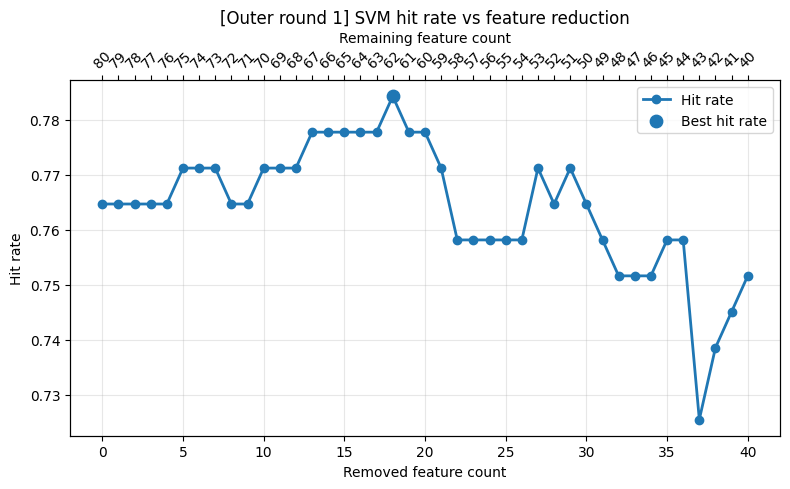

Feature optimization accepted: True
Current hit rate: 0.7647; candidate hit rate: 0.7843
Fitting 5 folds for each of 120 candidates, totalling 600 fits
[Outer round 1] SVM hyperparameter optimization with fixed feature set
Current selected feature count: 62
Best CV score: 0.7743
Hold-out hit rate: 0.6732
Best training params:
  c: 0.1
  kernel: sigmoid
  gamma: 0.01
  class_weight: balanced
  probability: True
Hyperparameter optimization accepted: False
Current hit rate: 0.7843; candidate hit rate: 0.6732
Alternating optimization finished
Stop reason: hyperparameter optimization did not improve hold-out hit rate
Best hit rate: 0.7843
Best feature count: 62
Best params: {'c': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': 'balanced', 'probability': True}


,outer_round,step_type,feature_count,hit_rate,accepted,params
0,0,baseline,80,0.764706,True,"{'c': 1.0, 'kernel': 'rbf', 'gamma': 'scale', ..."
1,1,feature_optimization,62,0.784314,True,"{'c': 1.0, 'kernel': 'rbf', 'gamma': 'scale', ..."
2,1,hyperparameter_optimization,62,0.673203,False,"{'c': 0.1, 'kernel': 'sigmoid', 'gamma': 0.01,..."


Second-stage group overlap: 0
Final best feature count: 62
Final best params: {'c': 1.0, 'kernel': 'rbf', 'gamma': 'scale', 'class_weight': 'balanced', 'probability': True}
Best second-stage SVM after alternating feature and hyperparameter optimization
Hit rate: 0.7843

Confusion matrix:


,pred_mel,pred_nv
true_mel,44,16
true_nv,17,76



Classification report:
              precision    recall  f1-score   support

         mel       0.72      0.73      0.73        60
          nv       0.83      0.82      0.82        93

    accuracy                           0.78       153
   macro avg       0.77      0.78      0.77       153
weighted avg       0.78      0.78      0.78       153



In [53]:
# test cell for alternating second-stage SVM feature-count and hyperparameter optimization
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')

ALTERNATING_SVM_INITIAL_FEATURE_NAMES = list(globals().get(
    'SVM_SELECTED_SECOND_FEATURE_NAMES',
    globals().get('category_selected_feature_names', selected_feature_names),
))
ALTERNATING_SVM_INITIAL_PARAMS = dict(globals().get('SVM_SELECTED_SECOND_SINGLE_PARAMS', {
    'c': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'class_weight': 'balanced',
    'probability': True,
}))
ALTERNATING_SVM_PARAM_GRID = {
    'clf__C': [0.1, 1.0, 10.0, 50.0, 100.0],
    'clf__kernel': ['rbf', 'linear', 'sigmoid', 'poly'],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
}

ALTERNATING_REMOVE_PERCENT = 0.01
ALTERNATING_MIN_FEATURES = 40
ALTERNATING_FEATURE_MAX_ROUNDS = None
ALTERNATING_MAX_OUTER_ROUNDS = 5
ALTERNATING_IMPORTANCE_SPLIT = 'train'
ALTERNATING_IMPORTANCE_REPEATS = 5

alternating_svm_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
alternating_svm_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=ALTERNATING_SVM_INITIAL_FEATURE_NAMES,
    first_stage_split=alternating_svm_first_stage_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

alternating_svm_optimization_result = run_alternating_svm_feature_param_optimization(
    x_train_all=alternating_svm_second_stage_split['x_train'],
    y_train=alternating_svm_second_stage_split['y_train'],
    train_groups=alternating_svm_second_stage_split['train_groups'],
    x_test_all=alternating_svm_second_stage_split['x_test'],
    y_test=alternating_svm_second_stage_split['y_test'],
    all_feature_names_for_matrix=ALTERNATING_SVM_INITIAL_FEATURE_NAMES,
    initial_feature_names=ALTERNATING_SVM_INITIAL_FEATURE_NAMES,
    initial_svm_params=ALTERNATING_SVM_INITIAL_PARAMS,
    param_grid=ALTERNATING_SVM_PARAM_GRID,
    remove_percent=ALTERNATING_REMOVE_PERCENT,
    min_features=ALTERNATING_MIN_FEATURES,
    feature_max_rounds=ALTERNATING_FEATURE_MAX_ROUNDS,
    max_outer_rounds=ALTERNATING_MAX_OUTER_ROUNDS,
    min_improvement=1e-12,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    model_random_state=42,
    importance_split=ALTERNATING_IMPORTANCE_SPLIT,
    importance_n_repeats=ALTERNATING_IMPORTANCE_REPEATS,
    permutation_n_jobs=-1,
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)

alternating_svm_best_state = alternating_svm_optimization_result['best_state']
alternating_svm_best_feature_names = alternating_svm_best_state['feature_names']
alternating_svm_best_params = alternating_svm_best_state['svm_params']
alternating_svm_best_result = alternating_svm_best_state['model_result']
alternating_svm_best_evaluation = alternating_svm_best_state['evaluation']

print('Second-stage group overlap:', len(set(alternating_svm_second_stage_split['train_groups']) & set(alternating_svm_second_stage_split['test_groups'])))
print('Final best feature count:', len(alternating_svm_best_feature_names))
print('Final best params:', alternating_svm_best_params)
print_model_evaluation(
    alternating_svm_best_evaluation,
    title='Best second-stage SVM after alternating feature and hyperparameter optimization',
)


#### Test

Best feature count: 62


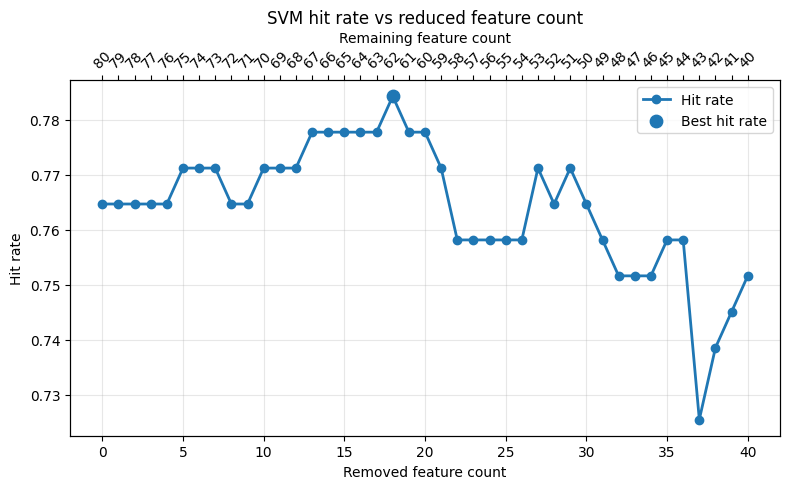

In [ ]:
# test cell for second-stage SVM iterative feature pruning
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')

SVM_PRUNING_INITIAL_FEATURE_NAMES = list(globals().get(
    'SVM_SELECTED_SECOND_FEATURE_NAMES',
    globals().get('category_selected_feature_names', selected_feature_names),
))
SVM_PRUNING_PARAMS = dict(globals().get('SVM_SELECTED_SECOND_SINGLE_PARAMS', {
    'c': 1.0,
    'kernel': 'rbf',
    'gamma': 'scale',
    'class_weight': 'balanced',
    'probability': True,
}))

SVM_PRUNING_REMOVE_PERCENT = 0.01
SVM_PRUNING_MIN_FEATURES = 40
SVM_PRUNING_MAX_ROUNDS = None
SVM_PRUNING_IMPORTANCE_SPLIT = 'train'
SVM_PRUNING_IMPORTANCE_REPEATS = 5

svm_pruning_first_stage_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
svm_pruning_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_PRUNING_INITIAL_FEATURE_NAMES,
    first_stage_split=svm_pruning_first_stage_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

svm_feature_pruning_result = run_svm_iterative_feature_pruning(
    x_train=svm_pruning_second_stage_split['x_train'],
    y_train=svm_pruning_second_stage_split['y_train'],
    x_test=svm_pruning_second_stage_split['x_test'],
    y_test=svm_pruning_second_stage_split['y_test'],
    feature_names=SVM_PRUNING_INITIAL_FEATURE_NAMES,
    svm_params=SVM_PRUNING_PARAMS,
    remove_percent=SVM_PRUNING_REMOVE_PERCENT,
    min_features=SVM_PRUNING_MIN_FEATURES,
    max_rounds=SVM_PRUNING_MAX_ROUNDS,
    importance_split=SVM_PRUNING_IMPORTANCE_SPLIT,
    importance_scoring='accuracy',
    importance_n_repeats=SVM_PRUNING_IMPORTANCE_REPEATS,
    permutation_n_jobs=-1,
    model_random_state=42,
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)

svm_feature_pruning_history_df = svm_feature_pruning_result['history_df']
svm_feature_pruning_removed_df = svm_feature_pruning_result['removed_features_df']
svm_feature_pruning_best_features = svm_feature_pruning_result['best_feature_names']
svm_feature_pruning_best_result = svm_feature_pruning_result['best_result']
svm_feature_pruning_best_evaluation = svm_feature_pruning_result['best_evaluation']

# print('Initial feature count:', len(SVM_PRUNING_INITIAL_FEATURE_NAMES))
# print('Remove percent per round:', SVM_PRUNING_REMOVE_PERCENT)
# print('Importance split:', SVM_PRUNING_IMPORTANCE_SPLIT)
# print('Second-stage group overlap:', len(set(svm_pruning_second_stage_split['train_groups']) & set(svm_pruning_second_stage_split['test_groups'])))
print('Best hit rate:', svm_feature_pruning_result['best_hit_rate'])
print('Best feature count:', len(svm_feature_pruning_best_features))
# print()
# try:
#     display(svm_feature_pruning_history_df)
# except NameError:
#     print(svm_feature_pruning_history_df.to_string(index=False))

# print('\nFirst removed features:')
# try:
#     display(svm_feature_pruning_removed_df.head(20))
# except NameError:
#     print(svm_feature_pruning_removed_df.head(20).to_string(index=False))

# print_model_evaluation(
#     svm_feature_pruning_best_evaluation,
#     title='Best second-stage SVM after iterative feature pruning',
# )
plot_svm_feature_pruning_curve(svm_feature_pruning_result)


In [48]:
print('Best hit rate:', svm_feature_pruning_result['best_hit_rate'])

Best hit rate: 0.7843137254901961


## 7.2 随机森林

### 7.2.1 使用全部特征

In [36]:
# automatic hyperparameter optimization for second-stage Random Forest with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_ALL_SECOND_FEATURE_NAMES = list(all_feature_names)

random_forest_all_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
random_forest_all_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_ALL_SECOND_FEATURE_NAMES,
    first_stage_split=random_forest_all_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

RF_ALL_SECOND_PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 8, 16, 24],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
}

random_forest_all_second_stage_optimization = optimize_stage_hyperparameters(
    features=random_forest_all_second_stage_split['x_train'],
    labels=random_forest_all_second_stage_split['y_train'],
    groups=random_forest_all_second_stage_split['train_groups'],
    model_type='random_forest',
    param_grid=RF_ALL_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    estimator_n_jobs=1,
)
print_random_forest_optimization_result(random_forest_all_second_stage_optimization)

random_forest_all_second_stage_best_params = random_forest_all_second_stage_optimization['best_params']
random_forest_all_second_stage_result = train_stage_classifier(
    x_train=random_forest_all_second_stage_split['x_train'],
    y_train=random_forest_all_second_stage_split['y_train'],
    feature_names=RF_ALL_SECOND_FEATURE_NAMES,
    model_type='random_forest',
    model_params=random_forest_all_second_stage_best_params,
    model_random_state=42,
)
random_forest_all_second_stage_result['x_test'] = random_forest_all_second_stage_split['x_test']
random_forest_all_second_stage_result['y_test'] = random_forest_all_second_stage_split['y_test']

random_forest_all_second_stage_evaluation = evaluate_model(
    random_forest_all_second_stage_result,
    random_forest_all_second_stage_split['x_test'],
    random_forest_all_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(random_forest_all_second_stage_split['train_groups']) & set(random_forest_all_second_stage_split['test_groups'])))
print_model_evaluation(
    random_forest_all_second_stage_evaluation,
    title='Second-stage Random Forest all-feature optimized-parameter evaluation',
)
print()
print_top_features(
    random_forest_all_second_stage_result['feature_importances'],
    top_n=100,
    title='Random Forest all-feature importances',
)


Fitting 5 folds for each of 324 candidates, totalling 1620 fits
Random Forest hyperparameter optimization
Best CV score: 0.7739
CV method: StratifiedGroupKFold
Best parameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 500

Second-stage group overlap: 0
Second-stage Random Forest all-feature optimized-parameter evaluation
Hit rate: 0.7582

Confusion matrix:


,pred_mel,pred_nv
true_mel,38,22
true_nv,15,78



Classification report:
              precision    recall  f1-score   support

         mel       0.72      0.63      0.67        60
          nv       0.78      0.84      0.81        93

    accuracy                           0.76       153
   macro avg       0.75      0.74      0.74       153
weighted avg       0.76      0.76      0.76       153


Top 100 Random Forest all-feature importances:
asymmetry_plus_combined_xor_pct: 0.024625
asymmetry_fullness: 0.023156
asymmetry_plus_major_axis_xor_pct: 0.020513
asymmetry_rotation: 0.018259
Lab_b_lab_min: 0.015467
shape_hu_moment_3: 0.015111
shape_solidity: 0.014112
Luv_v_luv_min: 0.013117
asymmetry_plus_minor_axis_xor_pct: 0.012502
YCbCr_Cb_max: 0.011576
Luv_u_luv_min: 0.010549
shape_defect_ratio: 0.010545
Ohta_I2_min: 0.009699
rgb_b_max: 0.008655
shape_perimeter: 0.008068
glcm_plus_ASM: 0.007568
HSV_H_std_outer_div_lesion: 0.007390
YCbCr_Cr_min: 0.006748
HSV_H_std_inner_div_lesion: 0.006731
shape_equiv_diameter: 0.006616
rgb_r_min: 0.006

In [ ]:
# single-parameter training for second-stage Random Forest with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_ALL_SECOND_FEATURE_NAMES = list(all_feature_names)

random_forest_all_single_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
random_forest_all_single_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_ALL_SECOND_FEATURE_NAMES,
    first_stage_split=random_forest_all_single_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

RF_ALL_SECOND_SINGLE_PARAMS = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'n_jobs': -1,
}

random_forest_all_single_second_stage_result = train_stage_classifier(
    x_train=random_forest_all_single_second_stage_split['x_train'],
    y_train=random_forest_all_single_second_stage_split['y_train'],
    feature_names=RF_ALL_SECOND_FEATURE_NAMES,
    model_type='random_forest',
    model_params=RF_ALL_SECOND_SINGLE_PARAMS,
    model_random_state=42,
)
random_forest_all_single_second_stage_result['x_test'] = random_forest_all_single_second_stage_split['x_test']
random_forest_all_single_second_stage_result['y_test'] = random_forest_all_single_second_stage_split['y_test']

random_forest_all_single_second_stage_evaluation = evaluate_model(
    random_forest_all_single_second_stage_result,
    random_forest_all_single_second_stage_split['x_test'],
    random_forest_all_single_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print('Second-stage group overlap:', len(set(random_forest_all_single_second_stage_split['train_groups']) & set(random_forest_all_single_second_stage_split['test_groups'])))
print_model_evaluation(
    random_forest_all_single_second_stage_evaluation,
    title='Second-stage Random Forest all-feature single-parameter evaluation',
)
print()
print_top_features(
    random_forest_all_single_second_stage_result['feature_importances'],
    top_n=20,
    title='Random Forest all-feature importances',
)


### 7.2.2 使用筛选后的特征

In [44]:
# automatic hyperparameter optimization for second-stage Random Forest with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_SELECTED_SECOND_FEATURE_NAMES = list(selected_feature_names)

random_forest_selected_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
random_forest_selected_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=random_forest_selected_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

RF_SELECTED_SECOND_PARAM_GRID = {
    'n_estimators': [50, 100, 300, 500],
    'max_depth': [None, 8, 16, 24],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
}

random_forest_selected_second_stage_optimization = optimize_stage_hyperparameters(
    features=random_forest_selected_second_stage_split['x_train'],
    labels=random_forest_selected_second_stage_split['y_train'],
    groups=random_forest_selected_second_stage_split['train_groups'],
    model_type='random_forest',
    param_grid=RF_SELECTED_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    estimator_n_jobs=1,
)
print_random_forest_optimization_result(random_forest_selected_second_stage_optimization)

random_forest_selected_second_stage_best_params = random_forest_selected_second_stage_optimization['best_params']
random_forest_selected_second_stage_result = train_stage_classifier(
    x_train=random_forest_selected_second_stage_split['x_train'],
    y_train=random_forest_selected_second_stage_split['y_train'],
    feature_names=RF_SELECTED_SECOND_FEATURE_NAMES,
    model_type='random_forest',
    model_params=random_forest_selected_second_stage_best_params,
    model_random_state=42,
)
random_forest_selected_second_stage_result['x_test'] = random_forest_selected_second_stage_split['x_test']
random_forest_selected_second_stage_result['y_test'] = random_forest_selected_second_stage_split['y_test']

random_forest_selected_second_stage_evaluation = evaluate_model(
    random_forest_selected_second_stage_result,
    random_forest_selected_second_stage_split['x_test'],
    random_forest_selected_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(random_forest_selected_second_stage_split['train_groups']) & set(random_forest_selected_second_stage_split['test_groups'])))
print_model_evaluation(
    random_forest_selected_second_stage_evaluation,
    title='Second-stage Random Forest selected-feature optimized-parameter evaluation',
)
print()
print_top_features(
    random_forest_selected_second_stage_result['feature_importances'],
    top_n=20,
    title='Random Forest selected-feature importances',
)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits
Random Forest hyperparameter optimization
Best CV score: 0.7144
CV method: StratifiedGroupKFold
Best parameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 50

Second-stage group overlap: 0
Second-stage Random Forest selected-feature optimized-parameter evaluation
Hit rate: 0.6993

Confusion matrix:


,pred_mel,pred_nv
true_mel,30,30
true_nv,16,77



Classification report:
              precision    recall  f1-score   support

         mel       0.65      0.50      0.57        60
          nv       0.72      0.83      0.77        93

    accuracy                           0.70       153
   macro avg       0.69      0.66      0.67       153
weighted avg       0.69      0.70      0.69       153


Top 16 Random Forest selected-feature importances:
Luv_v_luv_min: 0.204888
HSV_H_mean: 0.082557
Ohta_I3_std_inner_minus_lesion: 0.064763
Ohta_I3_var: 0.064714
rgb_b_min: 0.063964
Ohta_I3_min: 0.063237
rgb_b_mean: 0.055552
Ohta_I3_mean: 0.054203
YCbCr_Cb_min: 0.052651
rgb_b_mean_outer_minus_lesion: 0.052557
rgb_b_mean_inner_div_lesion: 0.047612
HSV_H_mean_inner_minus_lesion: 0.046294
HSV_H_mean_outer_minus_lesion: 0.044627
rgb_b_mean_inner_minus_lesion: 0.037721
HSV_H_mean_inner_div_lesion: 0.035161
Luv_v_luv_mean: 0.029501


In [ ]:
# single-parameter training for second-stage Random Forest with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_SELECTED_SECOND_FEATURE_NAMES = list(selected_feature_names)

random_forest_selected_single_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
random_forest_selected_single_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=random_forest_selected_single_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

RF_SELECTED_SECOND_SINGLE_PARAMS = {
    'n_estimators': 300,
    'max_depth': None,
    'min_samples_leaf': 2,
    'min_samples_split': 2,
    'max_features': 'sqrt',
    'class_weight': 'balanced',
    'n_jobs': -1,
}

random_forest_selected_single_second_stage_result = train_stage_classifier(
    x_train=random_forest_selected_single_second_stage_split['x_train'],
    y_train=random_forest_selected_single_second_stage_split['y_train'],
    feature_names=RF_SELECTED_SECOND_FEATURE_NAMES,
    model_type='random_forest',
    model_params=RF_SELECTED_SECOND_SINGLE_PARAMS,
    model_random_state=42,
)
random_forest_selected_single_second_stage_result['x_test'] = random_forest_selected_single_second_stage_split['x_test']
random_forest_selected_single_second_stage_result['y_test'] = random_forest_selected_single_second_stage_split['y_test']

random_forest_selected_single_second_stage_evaluation = evaluate_model(
    random_forest_selected_single_second_stage_result,
    random_forest_selected_single_second_stage_split['x_test'],
    random_forest_selected_single_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print('Second-stage group overlap:', len(set(random_forest_selected_single_second_stage_split['train_groups']) & set(random_forest_selected_single_second_stage_split['test_groups'])))
print_model_evaluation(
    random_forest_selected_single_second_stage_evaluation,
    title='Second-stage Random Forest selected-feature single-parameter evaluation',
)
print()
print_top_features(
    random_forest_selected_single_second_stage_result['feature_importances'],
    top_n=20,
    title='Random Forest selected-feature importances',
)


## 7.3 XGBoost

### 7.3.1 使用全部特征

In [43]:
# automatic hyperparameter optimization for second-stage XGBoost with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
XGB_ALL_SECOND_FEATURE_NAMES = list(all_feature_names)

xgboost_all_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
xgboost_all_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=XGB_ALL_SECOND_FEATURE_NAMES,
    first_stage_split=xgboost_all_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

XGB_ALL_SECOND_PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1.0, 3.0],
    'objective': ['binary:logistic'],
    'eval_metric': ['logloss'],
}
SECOND_STAGE_XGB_DEVICE = 'cuda'
SECOND_STAGE_XGB_TREE_METHOD = 'hist'
SECOND_STAGE_XGB_GRID_N_JOBS = 1 if SECOND_STAGE_XGB_DEVICE == 'cuda' else -1
SECOND_STAGE_XGB_ESTIMATOR_N_JOBS = 1
xgboost_all_second_stage_optimization = optimize_stage_hyperparameters(
    features=xgboost_all_second_stage_split['x_train'],
    labels=xgboost_all_second_stage_split['y_train'],
    groups=xgboost_all_second_stage_split['train_groups'],
    model_type='xgboost',
    param_grid=XGB_ALL_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=SECOND_STAGE_XGB_GRID_N_JOBS,
    estimator_n_jobs=SECOND_STAGE_XGB_ESTIMATOR_N_JOBS,
    tree_method=SECOND_STAGE_XGB_TREE_METHOD,
    device=SECOND_STAGE_XGB_DEVICE,
)
print_xgboost_optimization_result(xgboost_all_second_stage_optimization)

xgboost_all_second_stage_best_params = xgboost_all_second_stage_optimization['best_params']

xgboost_all_second_stage_best_params.setdefault('device', SECOND_STAGE_XGB_DEVICE)
xgboost_all_second_stage_best_params.setdefault('tree_method', SECOND_STAGE_XGB_TREE_METHOD)
xgboost_all_second_stage_best_params.setdefault('n_jobs', SECOND_STAGE_XGB_ESTIMATOR_N_JOBS)
xgboost_all_second_stage_result = train_stage_classifier(
    x_train=xgboost_all_second_stage_split['x_train'],
    y_train=xgboost_all_second_stage_split['y_train'],
    feature_names=XGB_ALL_SECOND_FEATURE_NAMES,
    model_type='xgboost',
    model_params=xgboost_all_second_stage_best_params,
    model_random_state=42,
)
xgboost_all_second_stage_result['x_test'] = xgboost_all_second_stage_split['x_test']
xgboost_all_second_stage_result['y_test'] = xgboost_all_second_stage_split['y_test']

xgboost_all_second_stage_evaluation = evaluate_model(
    xgboost_all_second_stage_result,
    xgboost_all_second_stage_split['x_test'],
    xgboost_all_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(xgboost_all_second_stage_split['train_groups']) & set(xgboost_all_second_stage_split['test_groups'])))
print_model_evaluation(
    xgboost_all_second_stage_evaluation,
    title='Second-stage XGBoost all-feature optimized-parameter evaluation',
)
print()
print_top_features(
    xgboost_all_second_stage_result['feature_importances'],
    top_n=20,
    title='XGBoost all-feature importances',
)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
XGBoost hyperparameter optimization
Best CV score: 0.7795
CV method: StratifiedGroupKFold
Device: cuda
Tree method: hist
Best parameters:
  colsample_bytree: 0.8
  eval_metric: logloss
  learning_rate: 0.03
  max_depth: 2
  n_estimators: 500
  objective: binary:logistic
  reg_lambda: 1.0
  subsample: 0.8

Second-stage group overlap: 0
Second-stage XGBoost all-feature optimized-parameter evaluation
Hit rate: 0.6928

Confusion matrix:


,pred_mel,pred_nv
true_mel,40,20
true_nv,27,66



Classification report:
              precision    recall  f1-score   support

         mel       0.60      0.67      0.63        60
          nv       0.77      0.71      0.74        93

    accuracy                           0.69       153
   macro avg       0.68      0.69      0.68       153
weighted avg       0.70      0.69      0.70       153


Top 20 XGBoost all-feature importances:
asymmetry_plus_combined_xor_pct: 0.028254
centroid_dist_Luv_L_luv: 0.020620
Gevers_l2_mean_outer_div_inner: 0.019027
HSV_H_std_outer_div_lesion: 0.019013
Ohta_I2_std_outer_div_lesion: 0.018888
Luv_u_luv_skew: 0.016731
rgb_b_max: 0.015261
Lab_b_lab_min: 0.015142
glcm_MaxProbability: 0.014463
Lab_a_lab_var: 0.013774
glcm_plus_ASM: 0.013773
HSV_H_std_inner_minus_lesion: 0.013748
asymmetry_fullness: 0.013729
Luv_v_luv_min: 0.013501
RGB_G_max: 0.012417
Gevers_l2_max: 0.010955
shape_defect_ratio: 0.010629
rgb_r_max: 0.010501
glcm_plus_SumEntropy: 0.010345
rgb_r_std_outer_div_inner: 0.010180


In [ ]:
# single-parameter training for second-stage XGBoost with all features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
XGB_ALL_SECOND_FEATURE_NAMES = list(all_feature_names)

xgboost_all_single_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
xgboost_all_single_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=XGB_ALL_SECOND_FEATURE_NAMES,
    first_stage_split=xgboost_all_single_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)
SECOND_STAGE_XGB_DEVICE = 'cuda'
SECOND_STAGE_XGB_TREE_METHOD = 'hist'
SECOND_STAGE_XGB_GRID_N_JOBS = 1 if SECOND_STAGE_XGB_DEVICE == 'cuda' else -1
SECOND_STAGE_XGB_ESTIMATOR_N_JOBS = 1
XGB_ALL_SECOND_SINGLE_PARAMS = {
    'n_estimators': 300,
    'max_depth': 3,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_lambda': 1.0,
    'reg_alpha': 0.0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_jobs': SECOND_STAGE_XGB_ESTIMATOR_N_JOBS,
    'tree_method': SECOND_STAGE_XGB_TREE_METHOD,
    'device': SECOND_STAGE_XGB_DEVICE,
}

xgboost_all_single_second_stage_result = train_stage_classifier(
    x_train=xgboost_all_single_second_stage_split['x_train'],
    y_train=xgboost_all_single_second_stage_split['y_train'],
    feature_names=XGB_ALL_SECOND_FEATURE_NAMES,
    model_type='xgboost',
    model_params=XGB_ALL_SECOND_SINGLE_PARAMS,
    model_random_state=42,
)
xgboost_all_single_second_stage_result['x_test'] = xgboost_all_single_second_stage_split['x_test']
xgboost_all_single_second_stage_result['y_test'] = xgboost_all_single_second_stage_split['y_test']

xgboost_all_single_second_stage_evaluation = evaluate_model(
    xgboost_all_single_second_stage_result,
    xgboost_all_single_second_stage_split['x_test'],
    xgboost_all_single_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print('Second-stage group overlap:', len(set(xgboost_all_single_second_stage_split['train_groups']) & set(xgboost_all_single_second_stage_split['test_groups'])))
print_model_evaluation(
    xgboost_all_single_second_stage_evaluation,
    title='Second-stage XGBoost all-feature single-parameter evaluation',
)
print()
print_top_features(
    xgboost_all_single_second_stage_result['feature_importances'],
    top_n=20,
    title='XGBoost all-feature importances',
)


### 7.3.2 使用筛选后的特征

In [54]:
# automatic hyperparameter optimization for second-stage XGBoost with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
XGB_SELECTED_SECOND_FEATURE_NAMES = list(selected_feature_names)

xgboost_selected_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
xgboost_selected_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=XGB_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=xgboost_selected_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

XGB_SELECTED_SECOND_PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1.0, 3.0],
    'objective': ['binary:logistic'],
    'eval_metric': ['logloss'],
}
SECOND_STAGE_XGB_DEVICE = 'cuda'
SECOND_STAGE_XGB_TREE_METHOD = 'hist'
SECOND_STAGE_XGB_GRID_N_JOBS = 4 if SECOND_STAGE_XGB_DEVICE == 'cuda' else -1
SECOND_STAGE_XGB_ESTIMATOR_N_JOBS = 1
xgboost_selected_second_stage_optimization = optimize_stage_hyperparameters(
    features=xgboost_selected_second_stage_split['x_train'],
    labels=xgboost_selected_second_stage_split['y_train'],
    groups=xgboost_selected_second_stage_split['train_groups'],
    model_type='xgboost',
    param_grid=XGB_SELECTED_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=SECOND_STAGE_XGB_GRID_N_JOBS,
    estimator_n_jobs=SECOND_STAGE_XGB_ESTIMATOR_N_JOBS,
    tree_method=SECOND_STAGE_XGB_TREE_METHOD,
    device=SECOND_STAGE_XGB_DEVICE,
)
print_xgboost_optimization_result(xgboost_selected_second_stage_optimization)

xgboost_selected_second_stage_best_params = xgboost_selected_second_stage_optimization['best_params']

xgboost_selected_second_stage_best_params.setdefault('device', SECOND_STAGE_XGB_DEVICE)
xgboost_selected_second_stage_best_params.setdefault('tree_method', SECOND_STAGE_XGB_TREE_METHOD)
xgboost_selected_second_stage_best_params.setdefault('n_jobs', SECOND_STAGE_XGB_ESTIMATOR_N_JOBS)
xgboost_selected_second_stage_result = train_stage_classifier(
    x_train=xgboost_selected_second_stage_split['x_train'],
    y_train=xgboost_selected_second_stage_split['y_train'],
    feature_names=XGB_SELECTED_SECOND_FEATURE_NAMES,
    model_type='xgboost',
    model_params=xgboost_selected_second_stage_best_params,
    model_random_state=42,
)
xgboost_selected_second_stage_result['x_test'] = xgboost_selected_second_stage_split['x_test']
xgboost_selected_second_stage_result['y_test'] = xgboost_selected_second_stage_split['y_test']

xgboost_selected_second_stage_evaluation = evaluate_model(
    xgboost_selected_second_stage_result,
    xgboost_selected_second_stage_split['x_test'],
    xgboost_selected_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(xgboost_selected_second_stage_split['train_groups']) & set(xgboost_selected_second_stage_split['test_groups'])))
print_model_evaluation(
    xgboost_selected_second_stage_evaluation,
    title='Second-stage XGBoost selected-feature optimized-parameter evaluation',
)
print()
print_top_features(
    xgboost_selected_second_stage_result['feature_importances'],
    top_n=20,
    title='XGBoost selected-feature importances',
)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
XGBoost hyperparameter optimization
Best CV score: 0.7209
CV method: StratifiedGroupKFold
Device: cuda
Tree method: hist
Best parameters:
  colsample_bytree: 0.8
  eval_metric: logloss
  learning_rate: 0.05
  max_depth: 2
  n_estimators: 100
  objective: binary:logistic
  reg_lambda: 3.0
  subsample: 0.8

Second-stage group overlap: 0
Second-stage XGBoost selected-feature optimized-parameter evaluation
Hit rate: 0.7255

Confusion matrix:


,pred_mel,pred_nv
true_mel,33,27
true_nv,15,78



Classification report:
              precision    recall  f1-score   support

         mel       0.69      0.55      0.61        60
          nv       0.74      0.84      0.79        93

    accuracy                           0.73       153
   macro avg       0.72      0.69      0.70       153
weighted avg       0.72      0.73      0.72       153


Top 16 XGBoost selected-feature importances:
Luv_v_luv_min: 0.168640
YCbCr_Cb_min: 0.079223
rgb_b_min: 0.074877
HSV_H_mean: 0.063520
rgb_b_mean_outer_minus_lesion: 0.062089
rgb_b_mean_inner_minus_lesion: 0.054684
Ohta_I3_min: 0.054343
Ohta_I3_std_inner_minus_lesion: 0.053966
Ohta_I3_var: 0.053957
HSV_H_mean_outer_minus_lesion: 0.053411
Ohta_I3_mean: 0.051238
rgb_b_mean_inner_div_lesion: 0.050858
HSV_H_mean_inner_div_lesion: 0.047581
Luv_v_luv_mean: 0.047516
HSV_H_mean_inner_minus_lesion: 0.043827
rgb_b_mean: 0.040269


In [ ]:
# single-parameter training for second-stage XGBoost with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
XGB_SELECTED_SECOND_FEATURE_NAMES = list(selected_feature_names)

xgboost_selected_single_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
xgboost_selected_single_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=XGB_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=xgboost_selected_single_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)
SECOND_STAGE_XGB_DEVICE = 'cuda'
SECOND_STAGE_XGB_TREE_METHOD = 'hist'
SECOND_STAGE_XGB_GRID_N_JOBS = 1 if SECOND_STAGE_XGB_DEVICE == 'cuda' else -1
SECOND_STAGE_XGB_ESTIMATOR_N_JOBS = 1
XGB_SELECTED_SECOND_SINGLE_PARAMS = {
    'n_estimators': 300,
    'max_depth': 3,
    'learning_rate': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.9,
    'reg_lambda': 1.0,
    'reg_alpha': 0.0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'n_jobs': SECOND_STAGE_XGB_ESTIMATOR_N_JOBS,
    'tree_method': SECOND_STAGE_XGB_TREE_METHOD,
    'device': SECOND_STAGE_XGB_DEVICE,
}

xgboost_selected_single_second_stage_result = train_stage_classifier(
    x_train=xgboost_selected_single_second_stage_split['x_train'],
    y_train=xgboost_selected_single_second_stage_split['y_train'],
    feature_names=XGB_SELECTED_SECOND_FEATURE_NAMES,
    model_type='xgboost',
    model_params=XGB_SELECTED_SECOND_SINGLE_PARAMS,
    model_random_state=42,
)
xgboost_selected_single_second_stage_result['x_test'] = xgboost_selected_single_second_stage_split['x_test']
xgboost_selected_single_second_stage_result['y_test'] = xgboost_selected_single_second_stage_split['y_test']

xgboost_selected_single_second_stage_evaluation = evaluate_model(
    xgboost_selected_single_second_stage_result,
    xgboost_selected_single_second_stage_split['x_test'],
    xgboost_selected_single_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print('Second-stage group overlap:', len(set(xgboost_selected_single_second_stage_split['train_groups']) & set(xgboost_selected_single_second_stage_split['test_groups'])))
print_model_evaluation(
    xgboost_selected_single_second_stage_evaluation,
    title='Second-stage XGBoost selected-feature single-parameter evaluation',
)
print()
print_top_features(
    xgboost_selected_single_second_stage_result['feature_importances'],
    top_n=20,
    title='XGBoost selected-feature importances',
)


## 7.4 特征量优化

我们了解到在第二阶段的区分（区分 `mel` 和 `nv`）中，效果比较好的特征可能有所改变，因此特征筛选的工作需要针对这两个标签进行。

同时，为了让不同特征能够更好地融合，我们对每个类别的特征独立做 4 中的评估和筛选。对每个类别中筛选后的特征，再 concat 在一起。

In [40]:
# functions for category-wise feature count optimization in the second stage

def get_fine_feature_category(feature_name: str) -> str:
    """Infer a fine-grained feature category from a feature name."""
    if feature_name.startswith('shape_'):
        return 'shape'
    if feature_name.startswith('asymmetry_'):
        return 'asymmetry'
    if feature_name.startswith(('glcm_', 'texture_')):
        return 'texture'
    return 'color'


def list_features_by_category(
    feature_names: Sequence[str],
    feature_category: str,
    category_func: object = get_fine_feature_category,
) -> list[str]:
    """Return feature names that belong to one fine-grained category."""
    category = str(feature_category)
    return [feature_name for feature_name in feature_names if category_func(feature_name) == category]


def select_category_features_by_score(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    feature_category: str,
    remaining_feature_count: int,
    positive_label: str,
    variance_threshold: float = 1e-8,
    corr_threshold: float = 0.95,
    fdr_alpha: float = 0.05,
    category_func: object = get_fine_feature_category,
) -> dict[str, object]:
    """Select a fixed number of features from one category for a binary task.

    Required controls are feature_category and remaining_feature_count.
    The selection reuses the section 4 workflow: low-variance filtering,
    binary univariate scoring, and high-correlation pruning.
    """
    if remaining_feature_count <= 0:
        raise ValueError('remaining_feature_count must be a positive integer.')

    all_feature_names = list(feature_names)
    category_feature_names = list_features_by_category(
        all_feature_names,
        feature_category=feature_category,
        category_func=category_func,
    )
    if not category_feature_names:
        raise ValueError(f"No features found for category '{feature_category}'.")

    name_to_index = {feature_name: index for index, feature_name in enumerate(all_feature_names)}
    category_indices = [name_to_index[feature_name] for feature_name in category_feature_names]
    category_matrix = prepare_feature_matrix(features)[:, category_indices]

    filtered_features, filtered_names, variance_df = filter_low_variance_features(
        category_matrix,
        category_feature_names,
        variance_threshold=variance_threshold,
    )
    if len(filtered_names) == 0:
        raise ValueError(f"All features in category '{feature_category}' were removed by variance filtering.")

    scores_df = compute_binary_feature_metrics(
        filtered_features,
        labels=labels,
        feature_names=filtered_names,
        positive_label=positive_label,
        fdr_alpha=fdr_alpha,
    )
    ranked_features = scores_df['feature'].tolist()
    filtered_df = pd.DataFrame(filtered_features, columns=filtered_names)

    corr_filtered_features, removed_corr_pairs = remove_high_corr_features_by_score(
        feature_list=ranked_features,
        df_features=filtered_df,
        scores_df=scores_df,
        threshold=corr_threshold,
        method='pearson',
    )

    selected_features = list(corr_filtered_features[:remaining_feature_count])
    if len(selected_features) < min(remaining_feature_count, len(ranked_features)):
        selected_set = set(selected_features)
        for feature_name in ranked_features:
            if feature_name not in selected_set:
                selected_features.append(feature_name)
                selected_set.add(feature_name)
            if len(selected_features) >= remaining_feature_count:
                break

    selected_indices = [filtered_names.index(feature_name) for feature_name in selected_features]
    selected_matrix = filtered_features[:, selected_indices]
    score_lookup = scores_df.set_index('feature')['composite_score'].to_dict()
    selected_feature_scores = {
        feature_name: float(score_lookup.get(feature_name, np.nan))
        for feature_name in selected_features
    }

    return {
        'feature_category': str(feature_category),
        'requested_feature_count': int(remaining_feature_count),
        'available_feature_count': len(category_feature_names),
        'after_variance_filter_count': len(filtered_names),
        'selected_feature_count': len(selected_features),
        'selected_features': selected_features,
        'selected_feature_scores': selected_feature_scores,
        'selected_feature_matrix': selected_matrix,
        'scores_df': scores_df,
        'variance_df': variance_df,
        'removed_corr_pairs': removed_corr_pairs,
    }


def select_features_by_category_counts(
    features: np.ndarray,
    labels: Sequence[str],
    feature_names: Sequence[str],
    category_feature_counts: dict[str, int],
    positive_label: str,
    variance_threshold: float = 1e-8,
    corr_threshold: float = 0.95,
    fdr_alpha: float = 0.05,
    category_func: object = get_fine_feature_category,
) -> dict[str, object]:
    """Select features independently for several categories and concatenate them."""
    category_results: dict[str, dict[str, object]] = {}
    combined_feature_names: list[str] = []
    combined_matrices: list[np.ndarray] = []

    for feature_category, remaining_count in category_feature_counts.items():
        result = select_category_features_by_score(
            features=features,
            labels=labels,
            feature_names=feature_names,
            feature_category=feature_category,
            remaining_feature_count=remaining_count,
            positive_label=positive_label,
            variance_threshold=variance_threshold,
            corr_threshold=corr_threshold,
            fdr_alpha=fdr_alpha,
            category_func=category_func,
        )
        category_results[feature_category] = result
        combined_feature_names.extend(result['selected_features'])
        combined_matrices.append(result['selected_feature_matrix'])

    if combined_matrices:
        combined_feature_matrix = concat_features(combined_matrices)
    else:
        combined_feature_matrix = np.empty((len(labels), 0), dtype=np.float32)

    return {
        'category_results': category_results,
        'combined_feature_names': combined_feature_names,
        'combined_feature_matrix': combined_feature_matrix,
        'category_feature_counts': dict(category_feature_counts),
    }


def print_category_feature_selection_result(selection_result: dict[str, object]) -> None:
    """Print selected categories and selected feature names for debugging."""
    category_results = selection_result['category_results']
    print('=' * 70)
    print('Category-wise feature selection result')
    print('=' * 70)
    for feature_category, result in category_results.items():
        print(f"Feature category: {feature_category}")
        print(f"Requested count: {result['requested_feature_count']}")
        print(f"Available count: {result['available_feature_count']}")
        print(f"After variance filter: {result['after_variance_filter_count']}")
        print(f"Selected count: {result['selected_feature_count']}")
        print('Selected features:')
        selected_feature_scores = result.get('selected_feature_scores', {})
        for index, feature_name in enumerate(result['selected_features'], start=1):
            score = selected_feature_scores.get(feature_name, np.nan)
            print(f"  {index:02d}. {feature_name:40s}: {score:.6f}")
        print()

    print('Combined selected feature count:', len(selection_result['combined_feature_names']))


### Test: for SVM

In [46]:
# test cell for category-wise second-stage feature count optimization
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SECOND_STAGE_POSITIVE_LABEL = SECOND_STAGE_FINE_TUNE_LABELS[0]

category_optimization_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
category_optimization_second_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_stage_split=category_optimization_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

CATEGORY_FEATURE_COUNTS = {
    'shape': 10,
    'asymmetry': 10,
    'texture': 15,
    'color': 10,
}

category_feature_selection_result = select_features_by_category_counts(
    features=category_optimization_second_split['x_train'],
    labels=category_optimization_second_split['y_train'],
    feature_names=all_feature_names,
    category_feature_counts=CATEGORY_FEATURE_COUNTS,
    positive_label=SECOND_STAGE_POSITIVE_LABEL,
    variance_threshold=1e-8,
    corr_threshold=0.95,
    fdr_alpha=0.05,
)

print('Second-stage labels:', SECOND_STAGE_FINE_TUNE_LABELS)
print('Positive label for feature scoring:', SECOND_STAGE_POSITIVE_LABEL)
print('Second-stage train samples:', category_optimization_second_split['x_train'].shape[0])
print('Second-stage group overlap:', len(set(category_optimization_second_split['train_groups']) & set(category_optimization_second_split['test_groups'])))
print()
print_category_feature_selection_result(category_feature_selection_result)

category_selected_feature_names = category_feature_selection_result['combined_feature_names']
category_selected_feature_matrix = category_feature_selection_result['combined_feature_matrix']


Second-stage labels: ('mel', 'nv')
Positive label for feature scoring: mel
Second-stage train samples: 357
Second-stage group overlap: 0

Category-wise feature selection result
Feature category: shape
Requested count: 10
Available count: 27
After variance filter: 27
Selected count: 10
Selected features:
  01. shape_solidity                          : 0.974482
  02. shape_hu_moment_3                       : 0.936980
  03. shape_perimeter                         : 0.853868
  04. shape_plus_radial_distance_std          : 0.758182
  05. shape_area                              : 0.735579
  06. shape_circularity                       : 0.715824
  07. shape_plus_fractal_dimension            : 0.706659
  08. shape_rectangularity                    : 0.547821
  09. shape_plus_radial_roughness             : 0.435493
  10. shape_hu_moment_4                       : 0.388016

Feature category: asymmetry
Requested count: 10
Available count: 13
After variance filter: 13
Selected count: 10
Selected fe

### Test: other

In [42]:
# test cell for category-wise second-stage feature count optimization
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SECOND_STAGE_POSITIVE_LABEL = SECOND_STAGE_FINE_TUNE_LABELS[0]

category_optimization_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
category_optimization_second_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_stage_split=category_optimization_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

CATEGORY_FEATURE_COUNTS = {
    'shape': 27,
    'asymmetry': 13,
    'texture': 28,
    'color': 12,
}

category_feature_selection_result = select_features_by_category_counts(
    features=category_optimization_second_split['x_train'],
    labels=category_optimization_second_split['y_train'],
    feature_names=all_feature_names,
    category_feature_counts=CATEGORY_FEATURE_COUNTS,
    positive_label=SECOND_STAGE_POSITIVE_LABEL,
    variance_threshold=1e-8,
    corr_threshold=0.95,
    fdr_alpha=0.05,
)

print('Second-stage labels:', SECOND_STAGE_FINE_TUNE_LABELS)
print('Positive label for feature scoring:', SECOND_STAGE_POSITIVE_LABEL)
print('Second-stage train samples:', category_optimization_second_split['x_train'].shape[0])
print('Second-stage group overlap:', len(set(category_optimization_second_split['train_groups']) & set(category_optimization_second_split['test_groups'])))
print()
print_category_feature_selection_result(category_feature_selection_result)

category_selected_feature_names = category_feature_selection_result['combined_feature_names']
category_selected_feature_matrix = category_feature_selection_result['combined_feature_matrix']


Second-stage labels: ('mel', 'nv')
Positive label for feature scoring: mel
Second-stage train samples: 357
Second-stage group overlap: 0

Category-wise feature selection result
Feature category: shape
Requested count: 27
Available count: 27
After variance filter: 27
Selected count: 27
Selected features:
  01. shape_solidity                          : 0.974482
  02. shape_hu_moment_3                       : 0.936980
  03. shape_perimeter                         : 0.853868
  04. shape_plus_radial_distance_std          : 0.758182
  05. shape_area                              : 0.735579
  06. shape_circularity                       : 0.715824
  07. shape_plus_fractal_dimension            : 0.706659
  08. shape_rectangularity                    : 0.547821
  09. shape_plus_radial_roughness             : 0.435493
  10. shape_hu_moment_4                       : 0.388016
  11. shape_plus_radial_distance_cv           : 0.281767
  12. shape_plus_boundary_gradient_std        : 0.242851
  13. shape

### SVM: category

In [136]:
# automatic hyperparameter optimization for second-stage SVM with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
SVM_SELECTED_SECOND_FEATURE_NAMES = list(category_selected_feature_names)

svm_selected_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
svm_selected_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=SVM_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=svm_selected_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

SVM_SELECTED_SECOND_PARAM_GRID = {
    'clf__C': [0.1, 1.0, 10.0, 50.0, 100.0],
    'clf__kernel': ['rbf', 'linear', 'sigmoid', 'poly'],
    'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1.0],
}

svm_selected_second_stage_optimization = optimize_stage_hyperparameters(
    features=svm_selected_second_stage_split['x_train'],
    labels=svm_selected_second_stage_split['y_train'],
    groups=svm_selected_second_stage_split['train_groups'],
    model_type='svm',
    param_grid=SVM_SELECTED_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    estimator_n_jobs=1,
)
print_svm_optimization_result(svm_selected_second_stage_optimization)

svm_selected_second_stage_best_params = _convert_stage_search_params_to_training_params('svm', svm_selected_second_stage_optimization['best_params'])
svm_selected_second_stage_result = train_stage_classifier(
    x_train=svm_selected_second_stage_split['x_train'],
    y_train=svm_selected_second_stage_split['y_train'],
    feature_names=SVM_SELECTED_SECOND_FEATURE_NAMES,
    model_type='svm',
    model_params=svm_selected_second_stage_best_params,
    model_random_state=42,
)
svm_selected_second_stage_result['x_test'] = svm_selected_second_stage_split['x_test']
svm_selected_second_stage_result['y_test'] = svm_selected_second_stage_split['y_test']

svm_selected_second_stage_evaluation = evaluate_model(
    svm_selected_second_stage_result,
    svm_selected_second_stage_split['x_test'],
    svm_selected_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(svm_selected_second_stage_split['train_groups']) & set(svm_selected_second_stage_split['test_groups'])))
print_model_evaluation(
    svm_selected_second_stage_evaluation,
    title='Second-stage SVM selected-feature optimized-parameter evaluation',
)
print()
print_top_features(
    svm_selected_second_stage_result['feature_importances'],
    top_n=20,
    title='SVM selected-feature importances',
)


Fitting 5 folds for each of 120 candidates, totalling 600 fits


SVM hyperparameter optimization
Best CV score: 0.7684
CV method: StratifiedGroupKFold
Best parameters:
  clf__C: 10.0
  clf__gamma: 0.01
  clf__kernel: poly

Second-stage group overlap: 0
Second-stage SVM selected-feature optimized-parameter evaluation
Hit rate: 0.7843

Confusion matrix:


,pred_mel,pred_nv
true_mel,40,20
true_nv,13,80



Classification report:
              precision    recall  f1-score   support

         mel       0.75      0.67      0.71        60
          nv       0.80      0.86      0.83        93

    accuracy                           0.78       153
   macro avg       0.78      0.76      0.77       153
weighted avg       0.78      0.78      0.78       153


SVM selected-feature importances: not available for this model/configuration.


### 随机森林：category

In [41]:
# automatic hyperparameter optimization for second-stage Random Forest with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
RF_SELECTED_SECOND_FEATURE_NAMES = list(all_feature_names)

random_forest_selected_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
random_forest_selected_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=RF_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=random_forest_selected_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

RF_SELECTED_SECOND_PARAM_GRID = {
    'n_estimators': [50, 100, 300, 500],
    'max_depth': [None, 8, 16, 24],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5],
}

random_forest_selected_second_stage_optimization = optimize_stage_hyperparameters(
    features=random_forest_selected_second_stage_split['x_train'],
    labels=random_forest_selected_second_stage_split['y_train'],
    groups=random_forest_selected_second_stage_split['train_groups'],
    model_type='random_forest',
    param_grid=RF_SELECTED_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    estimator_n_jobs=1,
)
print_random_forest_optimization_result(random_forest_selected_second_stage_optimization)

random_forest_selected_second_stage_best_params = random_forest_selected_second_stage_optimization['best_params']
random_forest_selected_second_stage_result = train_stage_classifier(
    x_train=random_forest_selected_second_stage_split['x_train'],
    y_train=random_forest_selected_second_stage_split['y_train'],
    feature_names=RF_SELECTED_SECOND_FEATURE_NAMES,
    model_type='random_forest',
    model_params=random_forest_selected_second_stage_best_params,
    model_random_state=42,
)
random_forest_selected_second_stage_result['x_test'] = random_forest_selected_second_stage_split['x_test']
random_forest_selected_second_stage_result['y_test'] = random_forest_selected_second_stage_split['y_test']

random_forest_selected_second_stage_evaluation = evaluate_model(
    random_forest_selected_second_stage_result,
    random_forest_selected_second_stage_split['x_test'],
    random_forest_selected_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(random_forest_selected_second_stage_split['train_groups']) & set(random_forest_selected_second_stage_split['test_groups'])))
print_model_evaluation(
    random_forest_selected_second_stage_evaluation,
    title='Second-stage Random Forest selected-feature optimized-parameter evaluation',
)
print()
print_top_features(
    random_forest_selected_second_stage_result['feature_importances'],
    top_n=20,
    title='Random Forest selected-feature importances',
)


Fitting 5 folds for each of 432 candidates, totalling 2160 fits


Random Forest hyperparameter optimization
Best CV score: 0.7739
CV method: StratifiedGroupKFold
Best parameters:
  max_depth: None
  max_features: sqrt
  min_samples_leaf: 2
  min_samples_split: 2
  n_estimators: 500

Second-stage group overlap: 0
Second-stage Random Forest selected-feature optimized-parameter evaluation
Hit rate: 0.7582

Confusion matrix:


,pred_mel,pred_nv
true_mel,38,22
true_nv,15,78



Classification report:
              precision    recall  f1-score   support

         mel       0.72      0.63      0.67        60
          nv       0.78      0.84      0.81        93

    accuracy                           0.76       153
   macro avg       0.75      0.74      0.74       153
weighted avg       0.76      0.76      0.76       153


Top 20 Random Forest selected-feature importances:
asymmetry_plus_combined_xor_pct: 0.024625
asymmetry_fullness: 0.023156
asymmetry_plus_major_axis_xor_pct: 0.020513
asymmetry_rotation: 0.018259
Lab_b_lab_min: 0.015467
shape_hu_moment_3: 0.015111
shape_solidity: 0.014112
Luv_v_luv_min: 0.013117
asymmetry_plus_minor_axis_xor_pct: 0.012502
YCbCr_Cb_max: 0.011576
Luv_u_luv_min: 0.010549
shape_defect_ratio: 0.010545
Ohta_I2_min: 0.009699
rgb_b_max: 0.008655
shape_perimeter: 0.008068
glcm_plus_ASM: 0.007568
HSV_H_std_outer_div_lesion: 0.007390
YCbCr_Cr_min: 0.006748
HSV_H_std_inner_div_lesion: 0.006731
shape_equiv_diameter: 0.006616


### XGBoost: category

In [111]:
# automatic hyperparameter optimization for second-stage XGBoost with selected features
LABEL_CSV = Path('./label.csv')
labeled_feature_df = attach_labels_from_csv(feature_df, LABEL_CSV)

FIRST_STAGE_FINE_TUNE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
SECOND_STAGE_FINE_TUNE_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
XGB_SELECTED_SECOND_FEATURE_NAMES = list(category_selected_feature_names)

xgboost_selected_second_stage_first_split = prepare_first_stage_split(
    feature_df=labeled_feature_df,
    feature_names=all_feature_names,
    first_positive_label=FIRST_STAGE_FINE_TUNE_LABEL,
    negative_label=SECOND_STAGE_FINE_TUNE_NEGATIVE_LABEL,
    test_size=0.3,
    random_state=42,
    stratify=True,
)
xgboost_selected_second_stage_split = prepare_second_stage_split(
    feature_df=labeled_feature_df,
    feature_names=XGB_SELECTED_SECOND_FEATURE_NAMES,
    first_stage_split=xgboost_selected_second_stage_first_split,
    second_labels=SECOND_STAGE_FINE_TUNE_LABELS,
)

XGB_SELECTED_SECOND_PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_lambda': [1.0, 3.0],
    'objective': ['binary:logistic'],
    'eval_metric': ['logloss'],
}
SECOND_STAGE_XGB_DEVICE = 'cuda'
SECOND_STAGE_XGB_TREE_METHOD = 'hist'
SECOND_STAGE_XGB_GRID_N_JOBS = 4 if SECOND_STAGE_XGB_DEVICE == 'cuda' else -1
SECOND_STAGE_XGB_ESTIMATOR_N_JOBS = 2
xgboost_selected_second_stage_optimization = optimize_stage_hyperparameters(
    features=xgboost_selected_second_stage_split['x_train'],
    labels=xgboost_selected_second_stage_split['y_train'],
    groups=xgboost_selected_second_stage_split['train_groups'],
    model_type='xgboost',
    param_grid=XGB_SELECTED_SECOND_PARAM_GRID,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=SECOND_STAGE_XGB_GRID_N_JOBS,
    estimator_n_jobs=SECOND_STAGE_XGB_ESTIMATOR_N_JOBS,
    tree_method=SECOND_STAGE_XGB_TREE_METHOD,
    device=SECOND_STAGE_XGB_DEVICE,
)
print_xgboost_optimization_result(xgboost_selected_second_stage_optimization)

xgboost_selected_second_stage_best_params = xgboost_selected_second_stage_optimization['best_params']

xgboost_selected_second_stage_best_params.setdefault('device', SECOND_STAGE_XGB_DEVICE)
xgboost_selected_second_stage_best_params.setdefault('tree_method', SECOND_STAGE_XGB_TREE_METHOD)
xgboost_selected_second_stage_best_params.setdefault('n_jobs', SECOND_STAGE_XGB_ESTIMATOR_N_JOBS)
xgboost_selected_second_stage_result = train_stage_classifier(
    x_train=xgboost_selected_second_stage_split['x_train'],
    y_train=xgboost_selected_second_stage_split['y_train'],
    feature_names=XGB_SELECTED_SECOND_FEATURE_NAMES,
    model_type='xgboost',
    model_params=xgboost_selected_second_stage_best_params,
    model_random_state=42,
)
xgboost_selected_second_stage_result['x_test'] = xgboost_selected_second_stage_split['x_test']
xgboost_selected_second_stage_result['y_test'] = xgboost_selected_second_stage_split['y_test']

xgboost_selected_second_stage_evaluation = evaluate_model(
    xgboost_selected_second_stage_result,
    xgboost_selected_second_stage_split['x_test'],
    xgboost_selected_second_stage_split['y_test'],
    label_order=list(SECOND_STAGE_FINE_TUNE_LABELS),
)
print()
print('Second-stage group overlap:', len(set(xgboost_selected_second_stage_split['train_groups']) & set(xgboost_selected_second_stage_split['test_groups'])))
print_model_evaluation(
    xgboost_selected_second_stage_evaluation,
    title='Second-stage XGBoost selected-feature optimized-parameter evaluation',
)
print()
print_top_features(
    xgboost_selected_second_stage_result['feature_importances'],
    top_n=20,
    title='XGBoost selected-feature importances',
)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits
XGBoost hyperparameter optimization
Best CV score: 0.7908
CV method: StratifiedGroupKFold
Device: cuda
Tree method: hist
Best parameters:
  colsample_bytree: 0.8
  eval_metric: logloss
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 500
  objective: binary:logistic
  reg_lambda: 3.0
  subsample: 1.0

Second-stage group overlap: 0
Second-stage XGBoost selected-feature optimized-parameter evaluation
Hit rate: 0.7320

Confusion matrix:


,pred_mel,pred_nv
true_mel,41,19
true_nv,22,71



Classification report:
              precision    recall  f1-score   support

         mel       0.65      0.68      0.67        60
          nv       0.79      0.76      0.78        93

    accuracy                           0.73       153
   macro avg       0.72      0.72      0.72       153
weighted avg       0.73      0.73      0.73       153


Top 20 XGBoost selected-feature importances:
texture_lbp_bin_12: 0.058378
asymmetry_fullness: 0.057487
asymmetry_plus_combined_xor_pct: 0.049722
Luv_v_luv_min: 0.036822
rgb_b_max: 0.032436
texture_lbp_bin_00: 0.031945
texture_lbp_bin_01: 0.027252
shape_area: 0.025104
texture_lbp_bin_58: 0.023895
texture_lbp_bin_15: 0.023484
texture_lbp_bin_13: 0.022978
shape_perimeter: 0.022873
shape_hu_moment_3: 0.022512
HSV_H_std_inner_minus_lesion: 0.022282
shape_solidity: 0.022205
texture_lbp_bin_10: 0.021906
shape_plus_fractal_dimension: 0.021493
asymmetry_rotation: 0.020817
asymmetry_xy_sum: 0.020574
shape_plus_radial_distance_std: 0.019905


# 8 双阶段综合 & 模型导出与导入

## 8.1 模型导出 & 导入函数

In [43]:
# functions for model save, load, prediction, and combined two-stage training

def _get_existing_feature_names(
    feature_df: pd.DataFrame,
    feature_names: Sequence[str],
    name: str = 'feature_names',
) -> list[str]:
    """Keep only feature names that exist in feature_df and fail if none remain."""
    existing = [feature_name for feature_name in list(feature_names) if feature_name in feature_df.columns]
    missing = [feature_name for feature_name in list(feature_names) if feature_name not in feature_df.columns]
    if missing:
        print(f"[WARNING] {name}: ignored {len(missing)} missing features. Example: {missing[:5]}")
    if not existing:
        raise ValueError(f'{name} contains no columns available in feature_df.')
    return existing


def build_labeled_feature_df(
    feature_df: pd.DataFrame,
    label_csv: str | Path = './label.csv',
    label_column: str = 'label',
) -> pd.DataFrame:
    """Return a feature DataFrame with labels attached when needed."""
    if label_column in feature_df.columns:
        return feature_df.copy()
    return attach_labels_from_csv(feature_df, Path(label_csv))


def predict_two_stage_labels(
    two_stage_result: dict[str, object],
    feature_df: pd.DataFrame,
) -> np.ndarray:
    """Predict final three-class labels with a trained two-stage model."""
    first_feature_names = list(two_stage_result['first_feature_names'])
    second_feature_names = list(two_stage_result['second_feature_names'])
    first_positive_label = str(two_stage_result['first_positive_label'])

    first_x = prepare_feature_matrix(feature_df.loc[:, first_feature_names].values)
    first_predictions = predict_model_labels(two_stage_result['first_model_result'], first_x).astype(str)

    final_predictions = np.full(len(first_predictions), first_positive_label, dtype=object)
    needs_second_stage = first_predictions != first_positive_label

    if np.any(needs_second_stage):
        second_x = prepare_feature_matrix(feature_df.loc[:, second_feature_names].values)
        final_predictions[needs_second_stage] = predict_model_labels(
            two_stage_result['second_model_result'],
            second_x[needs_second_stage],
        )

    return final_predictions.astype(str)


def run_combined_two_stage_experiment(
    feature_df: pd.DataFrame,
    first_positive_label: str,
    second_labels: tuple[str, str],
    first_feature_names: Sequence[str],
    second_feature_names: Sequence[str] | None = None,
    first_model_type: str = 'random_forest',
    second_model_type: str = 'random_forest',
    first_model_params: dict[str, object] | None = None,
    second_model_params: dict[str, object] | None = None,
    negative_label: str = 'other',
    label_column: str = 'label',
    group_column: str = 'base_id',
    test_size: float = 0.3,
    split_random_state: int = 42,
    model_random_state: int = 42,
    label_order: Sequence[str] | None = None,
    print_result: bool = True,
    top_n: int = 20,
) -> dict[str, object]:
    """Train two stage-specific models and evaluate the combined classifier."""
    first_feature_names = _get_existing_feature_names(
        feature_df,
        first_feature_names,
        name='first_feature_names',
    )
    second_feature_names = first_feature_names if second_feature_names is None else _get_existing_feature_names(
        feature_df,
        second_feature_names,
        name='second_feature_names',
    )

    two_stage_result = run_two_stage_training_pipeline(
        feature_df=feature_df,
        first_positive_label=first_positive_label,
        second_labels=tuple(second_labels),
        first_feature_names=first_feature_names,
        second_feature_names=second_feature_names,
        first_model_type=first_model_type,
        second_model_type=second_model_type,
        first_model_params={} if first_model_params is None else dict(first_model_params),
        second_model_params={} if second_model_params is None else dict(second_model_params),
        negative_label=negative_label,
        label_column=label_column,
        group_column=group_column,
        test_size=test_size,
        split_random_state=split_random_state,
        model_random_state=model_random_state,
    )
    two_stage_evaluation = evaluate_two_stage_models(
        two_stage_result,
        feature_df=feature_df,
        label_order=label_order,
    )

    if print_result:
        print_two_stage_evaluation_results(
            two_stage_result,
            two_stage_evaluation,
            top_n=top_n,
            show_feature_importance=True,
        )

    return {
        'two_stage_result': two_stage_result,
        'two_stage_evaluation': two_stage_evaluation,
        'label_order': list(label_order) if label_order is not None else None,
    }


def export_two_stage_model(
    two_stage_result: dict[str, object],
    export_dir: str | Path = './model_exports',
    filename: str = 'two_stage_model.joblib',
    metadata: dict[str, object] | None = None,
    overwrite: bool = True,
) -> Path:
    """Export a trained two-stage model bundle with joblib."""
    from datetime import datetime
    import joblib

    export_dir = Path(export_dir)
    export_dir.mkdir(parents=True, exist_ok=True)
    export_path = export_dir / filename
    if export_path.exists() and not overwrite:
        raise FileExistsError(f'Model file already exists: {export_path}')

    bundle = {
        'format_version': 1,
        'created_at': datetime.now().isoformat(timespec='seconds'),
        'two_stage_result': two_stage_result,
        'metadata': {} if metadata is None else dict(metadata),
    }
    joblib.dump(bundle, export_path)
    print(f'[SUCCESS] Exported two-stage model to: {export_path}')
    return export_path


def import_two_stage_model(model_path: str | Path) -> dict[str, object]:
    """Load a two-stage model bundle exported by export_two_stage_model."""
    import joblib

    model_path = Path(model_path)
    if not model_path.exists():
        raise FileNotFoundError(f'Model file does not exist: {model_path}')
    bundle = joblib.load(model_path)
    if 'two_stage_result' not in bundle:
        raise ValueError('Invalid model bundle: missing two_stage_result.')
    print(f'[SUCCESS] Imported two-stage model from: {model_path}')
    return bundle


def get_two_stage_result_from_bundle(bundle: dict[str, object]) -> dict[str, object]:
    """Extract the trained two-stage result dict from an imported bundle."""
    if 'two_stage_result' not in bundle:
        raise ValueError('Invalid model bundle: missing two_stage_result.')
    return bundle['two_stage_result']


## 8.2 综合模型

In [47]:
# train cell for combined two-stage model
LABEL_CSV = Path('./label.csv')
combined_labeled_feature_df = build_labeled_feature_df(feature_df, LABEL_CSV)

# Manually editable model/task settings.
COMBINED_FIRST_POSITIVE_LABEL = globals().get('FIRST_STAGE_LABEL', 'vasc')
COMBINED_SECOND_LABELS = globals().get('SECOND_STAGE_LABELS', ('mel', 'nv'))
COMBINED_NEGATIVE_LABEL = globals().get('NEGATIVE_LABEL', 'other')
COMBINED_LABEL_ORDER = list(COMBINED_SECOND_LABELS) + [COMBINED_FIRST_POSITIVE_LABEL]

# Manually editable feature settings.
COMBINED_FIRST_FEATURE_NAMES = list(selected_feature_names)
COMBINED_SECOND_FEATURE_NAMES = list(category_selected_feature_names)

# Manually editable model settings. Available model types: 'svm', 'random_forest', 'xgboost'.
# COMBINED_FIRST_MODEL_TYPE = 'random_forest'
# COMBINED_SECOND_MODEL_TYPE = 'random_forest'
# COMBINED_FIRST_MODEL_PARAMS = {
#     'n_estimators': 500,
#     'max_depth': None,
#     'min_samples_leaf': 2,
#     'min_samples_split': 2,
#     'max_features': 'sqrt',
#     'n_jobs': -1,
# }
# COMBINED_SECOND_MODEL_PARAMS = {
#     'n_estimators': 500,
#     'max_depth': None,
#     'min_samples_leaf': 2,
#     'min_samples_split': 2,
#     'max_features': 'sqrt',
#     'n_jobs': -1,
# }

# Example SVM params:
COMBINED_FIRST_MODEL_TYPE = 'svm'
COMBINED_FIRST_MODEL_PARAMS = {
    'c': 1.0, 
    'kernel': 'rbf', 
    'gamma': 'scale', 
    'probability': True
}
COMBINED_SECOND_MODEL_TYPE = 'svm'
COMBINED_SECOND_MODEL_PARAMS = {
    'c': 1.0, 
    'kernel': 'poly', 
    'gamma': 'scale', 
    'probability': True
}

# Example XGBoost params:
# COMBINED_FIRST_MODEL_TYPE = 'xgboost'
# COMBINED_FIRST_MODEL_PARAMS = {
#     'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05,
#     'subsample': 0.9, 'colsample_bytree': 0.9,
#     'objective': 'binary:logistic', 'eval_metric': 'logloss',
#     'tree_method': 'hist', 'device': 'cpu', 'n_jobs': -1,
# }
# COMBINED_SECOND_MODEL_TYPE = 'xgboost'
# COMBINED_SECOND_MODEL_PARAMS = {
#     'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05,
#     'subsample': 0.9, 'colsample_bytree': 0.9,
#     'objective': 'binary:logistic', 'eval_metric': 'logloss',
#     'tree_method': 'hist', 'device': 'cpu', 'n_jobs': -1,
# }

combined_two_stage_experiment = run_combined_two_stage_experiment(
    feature_df=combined_labeled_feature_df,
    first_positive_label=COMBINED_FIRST_POSITIVE_LABEL,
    second_labels=COMBINED_SECOND_LABELS,
    first_feature_names=COMBINED_FIRST_FEATURE_NAMES,
    second_feature_names=COMBINED_SECOND_FEATURE_NAMES,
    first_model_type=COMBINED_FIRST_MODEL_TYPE,
    second_model_type=COMBINED_SECOND_MODEL_TYPE,
    first_model_params=COMBINED_FIRST_MODEL_PARAMS,
    second_model_params=COMBINED_SECOND_MODEL_PARAMS,
    negative_label=COMBINED_NEGATIVE_LABEL,
    test_size=0.3,
    split_random_state=42,
    model_random_state=42,
    label_order=COMBINED_LABEL_ORDER,
    print_result=True,
    top_n=20,
)

combined_two_stage_result = combined_two_stage_experiment['two_stage_result']
combined_two_stage_evaluation = combined_two_stage_experiment['two_stage_evaluation']


First-stage svm evaluation (vasc vs other)
Hit rate: 0.9778

Confusion matrix:


,pred_other,pred_vasc
true_other,149,4
true_vasc,0,27



Classification report:
              precision    recall  f1-score   support

       other       1.00      0.97      0.99       153
        vasc       0.87      1.00      0.93        27

    accuracy                           0.98       180
   macro avg       0.94      0.99      0.96       180
weighted avg       0.98      0.98      0.98       180

first-stage feature importances: not available for this model/configuration.

Second-stage svm evaluation (mel vs nv)
Hit rate: 0.7843

Confusion matrix:


,pred_mel,pred_nv
true_mel,40,20
true_nv,13,80



Classification report:
              precision    recall  f1-score   support

         mel       0.75      0.67      0.71        60
          nv       0.80      0.86      0.83        93

    accuracy                           0.78       153
   macro avg       0.78      0.76      0.77       153
weighted avg       0.78      0.78      0.78       153

second-stage feature importances: not available for this model/configuration.

Combined two-stage three-class evaluation
Hit rate: 0.7944
First-stage positive predictions: 31
Samples routed to second stage: 149

Confusion matrix:


,pred_mel,pred_nv,pred_vasc
true_mel,39,20,1
true_nv,13,77,3
true_vasc,0,0,27



Classification report:
              precision    recall  f1-score   support

         mel       0.75      0.65      0.70        60
          nv       0.79      0.83      0.81        93
        vasc       0.87      1.00      0.93        27

    accuracy                           0.79       180
   macro avg       0.80      0.83      0.81       180
weighted avg       0.79      0.79      0.79       180



## 8.3 模型导出 & 导入测试

In [48]:
# test cell for two-stage model export and import
MODEL_EXPORT_DIR = Path('./model_exports')
MODEL_EXPORT_FILENAME = 'two_stage_combined_model.joblib'

combined_model_export_path = export_two_stage_model(
    two_stage_result=combined_two_stage_result,
    export_dir=MODEL_EXPORT_DIR,
    filename=MODEL_EXPORT_FILENAME,
    metadata={
        'first_model_type': COMBINED_FIRST_MODEL_TYPE,
        'second_model_type': COMBINED_SECOND_MODEL_TYPE,
        'first_positive_label': COMBINED_FIRST_POSITIVE_LABEL,
        'second_labels': tuple(COMBINED_SECOND_LABELS),
        'first_feature_count': len(combined_two_stage_result['first_feature_names']),
        'second_feature_count': len(combined_two_stage_result['second_feature_names']),
    },
    overwrite=True,
)

combined_model_bundle = import_two_stage_model(combined_model_export_path)
loaded_two_stage_result = get_two_stage_result_from_bundle(combined_model_bundle)

loaded_two_stage_evaluation = evaluate_two_stage_models(
    loaded_two_stage_result,
    feature_df=combined_labeled_feature_df,
    label_order=COMBINED_LABEL_ORDER,
)

original_predictions = combined_two_stage_evaluation['combined']['y_pred']
loaded_predictions = loaded_two_stage_evaluation['combined']['y_pred']
predictions_match = np.array_equal(original_predictions, loaded_predictions)

print('Export path:', combined_model_export_path)
print('Model file exists:', combined_model_export_path.exists())
print('Imported bundle metadata:')
print(combined_model_bundle.get('metadata', {}))
print('Original combined hit rate:', combined_two_stage_evaluation['combined']['hit_rate'])
print('Loaded combined hit rate:', loaded_two_stage_evaluation['combined']['hit_rate'])
print('Predictions match after import:', predictions_match)

if not predictions_match:
    mismatch_count = int(np.sum(original_predictions != loaded_predictions))
    raise AssertionError(f'Loaded model predictions differ from original predictions: {mismatch_count} mismatches.')

loaded_all_predictions = predict_two_stage_labels(
    loaded_two_stage_result,
    combined_labeled_feature_df,
)
print('Loaded model all-sample predictions shape:', loaded_all_predictions.shape)
print('First 10 loaded predictions:', loaded_all_predictions[:10].tolist())


[SUCCESS] Exported two-stage model to: model_exports/two_stage_combined_model.joblib
[SUCCESS] Imported two-stage model from: model_exports/two_stage_combined_model.joblib
Export path: model_exports/two_stage_combined_model.joblib
Model file exists: True
Imported bundle metadata:
{'first_model_type': 'svm', 'second_model_type': 'svm', 'first_positive_label': 'vasc', 'second_labels': ('mel', 'nv'), 'first_feature_count': 16, 'second_feature_count': 45}
Original combined hit rate: 0.7944444444444444
Loaded combined hit rate: 0.7944444444444444
Predictions match after import: True
Loaded model all-sample predictions shape: (600,)
First 10 loaded predictions: ['nv', 'mel', 'mel', 'mel', 'mel', 'nv', 'nv', 'nv', 'nv', 'nv']
